### **WP4 - model explainability using SHAP**

This notebook explains the final psychiatric readmission model outputs using global, local, subgroup, paired-model, error-group, and hourly sequence explanation tables.


##### **Notebook Outline**

- **explanation setup:** load final predictions, processed feature names, model artefacts, and explanation inputs.
- **global explanation:** summarise SHAP importance and feature-family contributions for the selected tree model.
- **local and error explanation:** inspect selected admissions and compare true positives, false positives, true negatives, and false negatives.
- **subgroup and paired explanation:** compare explanations across subgroups, model families, and hourly sequence outputs where available.


In [1]:
#import core libraries used for shap explanation, model loading, and output saving
import sys
import os
from pathlib import Path
import warnings
import time
import copy

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.special import expit
from sklearn.base import clone
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

#load optional explanation and sequence-model libraries once at the top
try:
    import shap
    shap_available = True
    shap_import_error = None
except Exception as error:
    shap = None
    shap_available = False
    shap_import_error = error

try:
    import torch
    import torch.nn as nn
    torch_available_for_sequence = True
    torch_sequence_import_error = None
except Exception as error:
    torch = None
    nn = None
    torch_available_for_sequence = False
    torch_sequence_import_error = error

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

**4.1 - SHAP Methodology**

This section defines the SHAP approach, loads the final model and processed test matrix, and creates a manageable explanation sample from the held-out test set. The sample is used because SHAP can be computationally expensive on the full processed matrix.


In [2]:
#report shap availability after optional import in the setup cell
print("SHAP available:", shap_available)
if shap_available:
    print("SHAP version:", shap.__version__)
else:
    print("SHAP import error:", shap_import_error)

SHAP available: True
SHAP version: 0.52.0


**Define paths**

The notebook reads WP3.1 processed matrices and the saved final model from WP3.4, then writes SHAP tables and figures into a dedicated WP4 output folder. The `wp3_input_variant` variable states the preferred primary matrix, currently the SHAP-guided reduced feature set.





In [ ]:
#define project paths and create dedicated output folders for wp4 artefacts
current_path = Path.cwd().resolve()
project_path = None
#loop through each item in this feature block
for candidate_path in [current_path] + list(current_path.parents):
    if (candidate_path / "code").exists():
        project_path = candidate_path
        break
if project_path is None:
    project_path = Path("/Users/ahthini/Desktop/DissProject")
wp3_1_output_path = project_path / "outputs" / "WP3_1"
wp3_4_output_path = project_path / "outputs" / "WP3_4"
wp3_5_output_path = project_path / "outputs" / "WP3_5"
wp3_6_output_path = project_path / "outputs" / "WP3_6"
#wp3.6 holds final evaluation tables; wp3.4 still holds the fitted tree models explained here.
wp4_output_path = project_path / "outputs" / "WP4"
wp4_csv_output_path = wp4_output_path / "csv_tables"
wp4_image_output_path = wp4_output_path / "images"

#preferred primary matrix after the reduced-feature decision
wp3_input_variant = "shap_guided_reduced_feature_set"

#explain the main final model selected in wp3.6.
#targeted lightgbm is treated as the primary explanation target because it is the current top model by pr-auc.
#a paired lightgbm/xgboost shap comparison is added at the end of the notebook for explanation stability.
final_model_family = "Targeted LightGBM"
final_model_path = wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_model.joblib"
final_prediction_path = wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_test_predictions.csv"
final_performance_path = wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_performance.csv"

shap_model_specs = [{"model_family": "Targeted LightGBM", "model_slug": "targeted_lightgbm",
     "model_path": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_model.joblib",
     "prediction_path": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_test_predictions.csv",
     "performance_path": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_performance.csv"},
    {"model_family": "Targeted XGBoost", "model_slug": "targeted_xgboost",
     "model_path": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_model.joblib",
     "prediction_path": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_test_predictions.csv",
     "performance_path": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_performance.csv"}]

wp4_output_path.mkdir(parents=True, exist_ok=True)
wp4_csv_output_path.mkdir(parents=True, exist_ok=True)
wp4_image_output_path.mkdir(parents=True, exist_ok=True)

print("Preferred WP3 input variant:", wp3_input_variant)
print("WP4 output folder:")
print(wp4_output_path)
print("WP4 CSV table folder:")
print(wp4_csv_output_path)
print("WP4 image folder:")
print(wp4_image_output_path)
print("Final model path:")
print(final_model_path)

Preferred WP3 input variant: shap_guided_reduced_feature_set
WP4 output folder:
/scratch/DissProject/outputs/WP4
WP4 CSV table folder:
/scratch/DissProject/outputs/WP4/csv_tables
WP4 image folder:
/scratch/DissProject/outputs/WP4/images
Final model path:
/scratch/DissProject/outputs/WP3_4/lightgbm_targeted/t3_4_lightgbm_targeted_model.joblib


In [ ]:
#load processed test matrix, outcomes, identifiers, feature names, predictions, and model
#the loader prefers the shap-guided reduced matrix, then falls back only if the saved model still expects an older feature count
if not final_model_path.exists():
    raise FileNotFoundError(f"Expected final model was not found: {final_model_path}")
if not final_prediction_path.exists():
    raise FileNotFoundError(f"Expected final prediction file was not found: {final_prediction_path}")

final_model = joblib.load(final_model_path)
model_expected_features = getattr(final_model, "n_features_in_", None)
if model_expected_features is None and hasattr(final_model, "get_booster"):
    model_expected_features = final_model.get_booster().num_features()
model_expected_features = int(model_expected_features) if model_expected_features is not None else None

candidate_matrix_suffixes = [wp3_input_variant, "clean_feature_audit", "runtime_trimmed_feature_audit", None]
selected_matrix_info = None
#loop through each item in this feature block
for matrix_suffix in candidate_matrix_suffixes:

    if matrix_suffix is None:
        candidate_X_test_path = wp3_1_output_path / "t3_1_X_test_processed.npz"
        candidate_feature_names_path = wp3_1_output_path / "t3_1_processed_feature_names.csv"
        candidate_label = "full_processed_matrix"
    else:
        candidate_X_test_path = wp3_1_output_path / f"t3_1_X_test_processed_{matrix_suffix}.npz"
        candidate_feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{matrix_suffix}.csv"
        candidate_label = matrix_suffix
    if not candidate_X_test_path.exists() or not candidate_feature_names_path.exists():
        continue
    candidate_feature_count = len(pd.read_csv(candidate_feature_names_path, usecols=["processed_feature_name"]))
    if model_expected_features is None or candidate_feature_count == model_expected_features:
        selected_matrix_info = (candidate_X_test_path, candidate_feature_names_path, candidate_label)
        break

if selected_matrix_info is None:
    raise ValueError("No WP3.1 processed matrix matches the saved model feature count. "
        f"The saved model expects {model_expected_features} features. "
        "Rerun WP3.2-WP3.4 after rebuilding the SHAP-guided reduced matrix, then rerun WP4.")

X_test_path, processed_feature_names_path, matrix_source_label = selected_matrix_info
X_test = sparse.load_npz(X_test_path)
y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
test_ids = pd.read_csv(wp3_1_output_path / "t3_1_test_ids.csv")
processed_feature_names = pd.read_csv(processed_feature_names_path)["processed_feature_name"].tolist()
test_predictions = pd.read_csv(final_prediction_path)

if X_test.shape[1] != len(processed_feature_names):
    raise ValueError(f"Feature-name count mismatch: matrix has {X_test.shape[1]} columns but "
        f"{len(processed_feature_names)} feature names were loaded.")

if matrix_source_label != wp3_input_variant:
    print("Note: WP4 is using", matrix_source_label, "because the saved model has not yet been rerun on", wp3_input_variant)

print("Loaded matrix source:", matrix_source_label)
print("Test matrix path:", X_test_path)
print("Feature names path:", processed_feature_names_path)
print("Test matrix shape:", X_test.shape)
print("Number of processed feature names:", len(processed_feature_names))
print("Model expected features:", model_expected_features)
print("Test outcome distribution:")
print(y_test.value_counts().sort_index())
print("Loaded prediction rows:", len(test_predictions))
print("Loaded model type:", type(final_model))

Loaded matrix source: shap_guided_reduced_feature_set
Test matrix path: /scratch/DissProject/outputs/WP3_1/t3_1_X_test_processed_shap_guided_reduced_feature_set.npz
Feature names path: /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names_shap_guided_reduced_feature_set.csv
Test matrix shape: (47171, 954)
Number of processed feature names: 954
Model expected features: 954
Test outcome distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64
Loaded prediction rows: 47171
Loaded model type: <class 'lightgbm.sklearn.LGBMClassifier'>


In [5]:
#merge predictions with test identifiers so shap rows can be linked back to admissions
prediction_id_cols = ["subject_id", "hadm_id", "readmitted_30d", "predicted_probability"]
if set(prediction_id_cols).issubset(test_predictions.columns):
    explanation_index_df = test_predictions[prediction_id_cols].copy()
else:
    explanation_index_df = test_ids.copy()
    explanation_index_df["readmitted_30d"] = y_test.values
    explanation_index_df["predicted_probability"] = final_model.predict_proba(X_test)[:, 1]

#derive a 14-day psychiatric readmission marker for local interpretation if timing is available
if "days_to_next" in test_predictions.columns:
    explanation_index_df["days_to_next"] = test_predictions["days_to_next"]
    explanation_index_df["readmitted_14d_psych"] = explanation_index_df["days_to_next"].between(0, 14, inclusive="both").fillna(False).astype(int)
for outcome_column in ["readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"]:
    if outcome_column in test_predictions.columns:
        explanation_index_df[outcome_column] = test_predictions[outcome_column].astype(int)

explanation_index_df["test_row_index"] = np.arange(len(explanation_index_df))
print("Explanation index preview:")
display(explanation_index_df.head())

Explanation index preview:


,subject_id,hadm_id,readmitted_30d,predicted_probability,days_to_next,readmitted_14d_psych,readmitted_60d_psych,readmitted_90d_psych,readmitted_365d_psych,test_row_index
0,10000117,22927623,0,0.060506,672.0,0,0,0,0,0
1,10000117,27988844,0,0.061817,NaN,0,0,0,0,1
2,10002221,21008195,0,0.072487,984.0,0,0,0,0,2
3,10002221,20195471,0,0.075973,377.0,0,0,0,0,3
4,10002221,21729093,1,0.190093,3.0,1,1,1,1,4


In [6]:
#create a balanced and high-risk-enriched shap sample from the held-out test set
#this keeps  explanation set manageable while ensuring true positives, false positives, and high-risk admissions are represented
shap_random_state = 42
max_shap_rows = 2500
rng = np.random.default_rng(shap_random_state)

positive_indices = explanation_index_df.loc[explanation_index_df["readmitted_30d"] == 1, "test_row_index"].to_numpy()
negative_indices = explanation_index_df.loc[explanation_index_df["readmitted_30d"] == 0, "test_row_index"].to_numpy()
high_risk_indices = explanation_index_df.sort_values("predicted_probability", ascending=False).head(500)["test_row_index"].to_numpy()

positive_sample = rng.choice(positive_indices, size=min(900, len(positive_indices)), replace=False) if len(positive_indices) else np.array([], dtype=int)
negative_sample = rng.choice(negative_indices, size=min(900, len(negative_indices)), replace=False) if len(negative_indices) else np.array([], dtype=int)
remaining_size = max(0, max_shap_rows - len(set(positive_sample).union(set(negative_sample)).union(set(high_risk_indices))))
remaining_indices = np.setdiff1d(np.arange(X_test.shape[0]), np.unique(np.concatenate([positive_sample, negative_sample, high_risk_indices])))
random_sample = rng.choice(remaining_indices, size=min(remaining_size, len(remaining_indices)), replace=False) if len(remaining_indices) else np.array([], dtype=int)

shap_sample_indices = np.unique(np.concatenate([positive_sample, negative_sample, high_risk_indices, random_sample])).astype(int)
shap_sample_indices = shap_sample_indices[:max_shap_rows]
X_shap_sample = X_test[shap_sample_indices]
shap_sample_index_df = explanation_index_df.iloc[shap_sample_indices].copy().reset_index(drop=True)

print("SHAP sample rows:", X_shap_sample.shape[0])
print("SHAP sample columns:", X_shap_sample.shape[1])
print("SHAP sample outcome distribution:")
print(shap_sample_index_df["readmitted_30d"].value_counts().sort_index())
print("SHAP sample predicted probability summary:")
print(shap_sample_index_df["predicted_probability"].describe())

SHAP sample rows: 2500
SHAP sample columns: 954
SHAP sample outcome distribution:
readmitted_30d
0    1102
1    1398
Name: count, dtype: int64
SHAP sample predicted probability summary:
count    2500.000000
mean        0.405103
std         0.346046
min         0.003641
25%         0.120957
50%         0.245729
75%         0.748486
max         0.983200
Name: predicted_probability, dtype: float64


**4.1.1 - Explanation Sample Check**

This section compares the SHAP explanation sample with the full held-out test set. The sample is deliberately enriched for positive and high-risk admissions, so this audit records the difference rather than pretending the explanation sample is a simple random copy of the test set.


In [7]:
#compare the explanation sample with the full held-out test set
#the sample is enriched for positives and high-risk admissions, so this table makes that design explicit
full_test_index_df = explanation_index_df.copy()
shap_sample_audit_df = shap_sample_index_df.copy()

#use full-test risk cut points so the sample enrichment can be described consistently
risk_quantiles = full_test_index_df["predicted_probability"].quantile([0.25, 0.50, 0.75, 0.90]).to_dict()
high_risk_top_decile_cutoff = risk_quantiles.get(0.90, np.nan)

#summarise explanation group
def summarise_explanation_group(group_name, index_df):
    #summarise outcome balance and predicted-risk distribution for one population
    probability = pd.to_numeric(index_df["predicted_probability"], errors="coerce")
    outcome = pd.to_numeric(index_df["readmitted_30d"], errors="coerce")
    return {
        "analysis_group": group_name,
        "admissions": len(index_df),
        "readmission_rate": outcome.mean(),
        "positive_admissions": int(outcome.fillna(0).sum()),
        "negative_admissions": int((1 - outcome.fillna(0)).sum()),
        "mean_predicted_probability": probability.mean(),
        "median_predicted_probability": probability.median(),
        "p25_predicted_probability": probability.quantile(0.25),
        "p75_predicted_probability": probability.quantile(0.75),
        "p90_predicted_probability": probability.quantile(0.90),
        "share_in_full_test_top_decile": probability.ge(high_risk_top_decile_cutoff).mean() if pd.notna(high_risk_top_decile_cutoff) else np.nan}

shap_sample_representativeness_df = pd.DataFrame([
    summarise_explanation_group("full_held_out_test_set", full_test_index_df),
    summarise_explanation_group("shap_explanation_sample", shap_sample_audit_df)])

#add simple enrichment ratios for report wording
full_row = shap_sample_representativeness_df.loc[
    shap_sample_representativeness_df["analysis_group"].eq("full_held_out_test_set")].iloc[0]
for metric_name in ["readmission_rate", "mean_predicted_probability", "share_in_full_test_top_decile"]:
    denominator = full_row[metric_name]
    shap_sample_representativeness_df[f"{metric_name}_ratio_vs_full_test"] = (
        shap_sample_representativeness_df[metric_name] / denominator if pd.notna(denominator) and denominator != 0 else np.nan)

shap_sample_representativeness_df.to_csv(
    wp4_csv_output_path / "t4_shap_sample_representativeness.csv", index=False)

print("SHAP sample representativeness check:")
display(shap_sample_representativeness_df.round(4))

SHAP sample representativeness check:


,analysis_group,admissions,readmission_rate,positive_admissions,negative_admissions,mean_predicted_probability,median_predicted_probability,p25_predicted_probability,p75_predicted_probability,p90_predicted_probability,share_in_full_test_top_decile,readmission_rate_ratio_vs_full_test,mean_predicted_probability_ratio_vs_full_test,share_in_full_test_top_decile_ratio_vs_full_test
0,full_held_out_test_set,47171,0.1976,9319,37852,0.2165,0.1482,0.0863,0.2642,0.4860,0.100,1.0000,1.000,1.0000
1,shap_explanation_sample,2500,0.5592,1398,1102,0.4051,0.2457,0.1210,0.7485,0.9659,0.324,2.8306,1.871,3.2394


In [ ]:
#compute shap values for the sampled held-out admissions; treeexplainer reports contributions on the model log-odds scale for binary tree models
if not shap_available:
    raise ImportError("SHAP is not available in this environment. Install or enable SHAP before running WP4.")

shap_start_time = time.perf_counter()
explainer = shap.TreeExplainer(final_model)
try:
    shap_values_raw = explainer.shap_values(X_shap_sample)
    X_shap_display = X_shap_sample
except Exception as sparse_error:
    print("Sparse SHAP calculation failed, retrying with a dense sample matrix.")
    print("Sparse SHAP error:", sparse_error)
    X_shap_display = X_shap_sample.toarray() if sparse.issparse(X_shap_sample) else X_shap_sample
    shap_values_raw = explainer.shap_values(X_shap_display)

#shap can return a list, an explanation object, a sparse matrix, or a 3d binary-class array depending on model/library versions.
def normalise_binary_shap_values(shap_values_raw, feature_names):
    expected_feature_count = len(feature_names)
    #define unwrap shap object
    def unwrap_shap_object(values):
        if hasattr(values, "values"):
            values = values.values
        if sparse.issparse(values):
            values = values.toarray()
        values_array = np.asarray(values)
        if values_array.ndim == 0 and values_array.dtype == object:
            return unwrap_shap_object(values_array.item())
        return values_array

    if isinstance(shap_values_raw, (list, tuple)):
        shap_candidates = list(shap_values_raw)
        candidate_order = [1, 0] + list(range(2, len(shap_candidates))) if len(shap_candidates) > 1 else [0]
        last_error = None
        #loop through each item in this feature block
        for candidate_index in candidate_order:
            if candidate_index >= len(shap_candidates):
                continue
            try:
                return normalise_binary_shap_values(shap_candidates[candidate_index], feature_names)
            except ValueError as error:
                last_error = error
        raise last_error if last_error is not None else ValueError("No usable SHAP array was returned.")

    shap_values_processed = unwrap_shap_object(shap_values_raw)

    if shap_values_processed.ndim == 3:
        if shap_values_processed.shape[-1] == 2 and shap_values_processed.shape[1] == expected_feature_count:
            shap_values_processed = shap_values_processed[:, :, 1]
        elif shap_values_processed.shape[0] == 2 and shap_values_processed.shape[2] == expected_feature_count:
            shap_values_processed = shap_values_processed[1, :, :]
        elif shap_values_processed.shape[1] == 2 and shap_values_processed.shape[2] == expected_feature_count:
            shap_values_processed = shap_values_processed[:, 1, :]
        else:
            raise ValueError(f"Unexpected 3D SHAP shape: {shap_values_processed.shape}")

    if shap_values_processed.ndim == 1 and shap_values_processed.shape[0] == expected_feature_count:
        shap_values_processed = shap_values_processed.reshape(1, -1)
    if shap_values_processed.ndim == 2 and shap_values_processed.shape[0] == expected_feature_count and shap_values_processed.shape[1] != expected_feature_count:
        shap_values_processed = shap_values_processed.T
    if shap_values_processed.ndim != 2:
        raise ValueError(f"Expected 2D SHAP values, got shape {shap_values_processed.shape}")
    if shap_values_processed.shape[1] != expected_feature_count:
        raise ValueError(f"SHAP feature count does not match processed feature names: {shap_values_processed.shape[1]} vs {expected_feature_count}")
    return shap_values_processed

shap_values = normalise_binary_shap_values(shap_values_raw, processed_feature_names)
if shap_values.shape[1] != len(processed_feature_names):
    raise ValueError("SHAP feature count does not match processed feature names: "
        f"{shap_values.shape[1]} vs {len(processed_feature_names)}")

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()[-1]

shap_elapsed_seconds = time.perf_counter() - shap_start_time
print("SHAP value matrix shape:", shap_values.shape)
print("SHAP expected value:", base_value)
print("SHAP calculation time in seconds:", round(shap_elapsed_seconds, 2))

SHAP value matrix shape: (2500, 954)
SHAP expected value: -1.5629533939777953
SHAP calculation time in seconds: 24.56


In [9]:
#save a compact methodology summary for transparent reporting
methodology_summary_df = pd.DataFrame([{
    "explained_model_family": final_model_family,
    "model_path": str(final_model_path),
    "matrix_source": matrix_source_label,
    "test_matrix_path": str(X_test_path),
    "processed_feature_names_path": str(processed_feature_names_path),
    "test_rows": X_test.shape[0],
    "processed_features": X_test.shape[1],
    "model_expected_features": model_expected_features,
    "shap_sample_rows": X_shap_sample.shape[0],
    "shap_sample_positive_rows": int(shap_sample_index_df["readmitted_30d"].sum()),
    "shap_sample_negative_rows": int((1 - shap_sample_index_df["readmitted_30d"]).sum()),
    "shap_expected_value_log_odds": base_value,
    "shap_expected_value_probability": expit(base_value),
    "shap_random_state": shap_random_state,
    "shap_elapsed_seconds": shap_elapsed_seconds}])
methodology_summary_df.to_csv(wp4_csv_output_path / "t4_shap_methodology_summary.csv", index=False)
display(methodology_summary_df)

,explained_model_family,model_path,matrix_source,test_matrix_path,processed_feature_names_path,test_rows,processed_features,model_expected_features,shap_sample_rows,shap_sample_positive_rows,shap_sample_negative_rows,shap_expected_value_log_odds,shap_expected_value_probability,shap_random_state,shap_elapsed_seconds
0,Targeted LightGBM,/scratch/DissProject/outputs/WP3_4/lightgbm_ta...,shap_guided_reduced_feature_set,/scratch/DissProject/outputs/WP3_1/t3_1_X_test...,/scratch/DissProject/outputs/WP3_1/t3_1_proces...,47171,954,954,2500,1398,1102,-1.562953,0.173223,42,24.563943


**4.2 - Global Explanations**

This section summarises which processed predictors have the largest average absolute SHAP values across the sampled held-out admissions. Larger mean absolute SHAP values indicate stronger average influence on predicted readmission risk.


In [10]:
#summarise global shap importance across the held-out explanation sample
mean_abs_shap = np.abs(shap_values).mean(axis=0)
mean_signed_shap = shap_values.mean(axis=0)
std_shap = shap_values.std(axis=0)

shap_global_importance_df = pd.DataFrame({
    "processed_feature_name": processed_feature_names,
    "mean_abs_shap": mean_abs_shap,
    "mean_signed_shap": mean_signed_shap,
    "std_shap": std_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_global_importance_df["importance_rank"] = np.arange(1, len(shap_global_importance_df) + 1)
shap_global_importance_df["feature_name_clean"] = shap_global_importance_df["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
shap_global_importance_df["feature_type"] = np.where(shap_global_importance_df["processed_feature_name"].str.startswith("cat__"), "categorical_encoded", "numeric_or_binary")

shap_global_importance_df.to_csv(wp4_csv_output_path / "t4_shap_global_importance.csv", index=False)
shap_global_importance_df.head(30).to_csv(wp4_csv_output_path / "t4_shap_top30_global_importance.csv", index=False)

print("Top 30 global SHAP features:")
display(shap_global_importance_df.head(30))

Top 30 global SHAP features:


,processed_feature_name,mean_abs_shap,mean_signed_shap,std_shap,importance_rank,feature_name_clean,feature_type
0,num__late_orders_without_prior_psych_history_flag,0.286215,0.159523,0.278994,1,late_orders_without_prior_psych_history_flag,numeric_or_binary
1,num__orders_last_12h_before_discharge,0.156688,0.114154,0.242004,2,orders_last_12h_before_discharge,numeric_or_binary
2,cat__discharge_location_Unknown / not modelled,0.108066,0.016169,0.316931,3,discharge_location_Unknown / not modelled,categorical_encoded
3,num__last_order_close_to_discharge_hours,0.104434,0.085912,0.197104,4,last_order_close_to_discharge_hours,numeric_or_binary
4,num__late_order_severity_per_late_order_last_12h,0.098736,0.071089,0.153364,5,late_order_severity_per_late_order_last_12h,numeric_or_binary
5,num__previous_psych_admissions_365d,0.076587,0.006362,0.113311,6,previous_psych_admissions_365d,numeric_or_binary
6,num__previous_psych_admissions_180d,0.064863,0.005693,0.097225,7,previous_psych_admissions_180d,numeric_or_binary
7,num__low_order_activity_with_self_harm_flag,0.062261,0.035398,0.128655,8,low_order_activity_with_self_harm_flag,numeric_or_binary
8,num__unmanaged_psychiatric_discharge_risk_score,0.061352,0.030793,0.082560,9,unmanaged_psychiatric_discharge_risk_score,numeric_or_binary
9,num__last_order_close_to_discharge_hours_filled,0.060967,0.050366,0.115559,10,last_order_close_to_discharge_hours_filled,numeric_or_binary


In [ ]:
#summarise global shap importance by broad processed feature family
#these rules keep the main feature-engineering themes visible in the shap outputs.
feature_family_rules = [
    ("poe_order_pathway", "poe|order_|orders_|first_order|last_order|order_activity|sitter|observation|suicide_precaution|elopement|restraint_order|psych_consult|social_work|discontinued_orders|unique_order"),
    ("care_team_complexity", "care_team|caregiver|provider|enter_provider|order_provider|provider_order_changes|touchpoints"),
    ("prior_utilisation", "previous_|recent_|days_since_previous|admission_ratio|frequent|high_utiliser"),
    ("psychiatric_history", "psych|depression|bipolar|substance|alcohol|opioid|stimulant|cannabis|tobacco|nicotine|sedative|polysubstance|severe_mental|self_harm|suicidal|psychoses"),
    ("medication_emar", "medication|drug|prescription|pharmacy|emar|antipsychotic|benzodiazepine|mood_stabiliser|mood_stabilizer|lai|iv_prescription|infusion|not_given|dose|prn|scheduled_pharmacy"),
    ("discharge_social", "discharge|insurance|language|marital|race|public_insurance|non_english|facility|home_flag|against_advice"),
    ("ed_pathway", "ed_length|ed_to_|emergency_room|ward_delay|transfer_from|internal_transfer|service_transfer|first_service|last_service|medicine_service|psych_service"),
    ("laboratory", "_lab_|sodium|potassium|creatinine|glucose|wbc|hemoglobin|platelet|urea|culture|microbiology|organism|infection"),
    ("vital_sign", "_vital_|heart_rate|spo2|respiratory|bp_|systolic|mean_bp"),
    ("procedure_comorbidity", "procedure|comorbidity|elixhauser|charlson|bmi|weight|height|obesity|underweight|dialysis|ventilation|ect|central_line|physical"),
    ("icu_care", "icu|careunit"),
    ("admission_context", "admission_type|admission_location|admission_hour|admission_day|admission_month|admission_year|los_days|los_|anchor_age|age_|gender")]

#assign feature family
def assign_feature_family(feature_name):
    #loop through each item in this feature block
    for family_name, pattern in feature_family_rules:
        if pd.Series([feature_name]).str.contains(pattern, case=False, regex=True).iloc[0]:
            return family_name
    return "other"

shap_global_importance_df["feature_family"] = shap_global_importance_df["feature_name_clean"].apply(assign_feature_family)
#summarise row-level records to admission-level features
shap_family_importance_df = shap_global_importance_df.groupby("feature_family", as_index=False).agg(
    processed_feature_count=("processed_feature_name", "size"),
    total_mean_abs_shap=("mean_abs_shap", "sum"),
    mean_abs_shap=("mean_abs_shap", "mean"),
    max_mean_abs_shap=("mean_abs_shap", "max"))
shap_family_importance_df = shap_family_importance_df.sort_values("total_mean_abs_shap", ascending=False).reset_index(drop=True)
#save this table or artefact for later review
shap_global_importance_df.to_csv(wp4_csv_output_path / "t4_shap_global_importance.csv", index=False)
shap_global_importance_df.head(30).to_csv(wp4_csv_output_path / "t4_shap_top30_global_importance.csv", index=False)
shap_family_importance_df.to_csv(wp4_csv_output_path / "t4_shap_feature_family_importance.csv", index=False)

#within-family top-five lists make the family summary actionable for feature-engineering decisions
family_rank_lookup = shap_family_importance_df[["feature_family"]].reset_index().rename(columns={"index": "family_importance_rank"})
family_rank_lookup["family_importance_rank"] = family_rank_lookup["family_importance_rank"] + 1
shap_top5_features_by_family_df = shap_global_importance_df.sort_values(
    #summarise row-level records to admission-level features
    ["feature_family", "mean_abs_shap"], ascending=[True, False]).groupby("feature_family", as_index=False).head(5).copy()
shap_top5_features_by_family_df["feature_rank_within_family"] = shap_top5_features_by_family_df.groupby(
    "feature_family")["mean_abs_shap"].rank(method="first", ascending=False).astype(int)
#join the derived features back to the admission table
shap_top5_features_by_family_df = shap_top5_features_by_family_df.merge(family_rank_lookup, on="feature_family", how="left")
shap_top5_features_by_family_df = shap_top5_features_by_family_df.sort_values(
    ["family_importance_rank", "feature_rank_within_family"]).reset_index(drop=True)
shap_top5_features_by_family_df.to_csv(wp4_csv_output_path / "t4_shap_top5_features_by_family.csv", index=False)

print("SHAP importance by feature family:")
display(shap_family_importance_df)
print("Top five SHAP features within each feature family:")
display(shap_top5_features_by_family_df[["feature_family", "feature_rank_within_family",
    "processed_feature_name", "feature_name_clean", "mean_abs_shap", "family_importance_rank"]].head(60))

SHAP importance by feature family:


,feature_family,processed_feature_count,total_mean_abs_shap,mean_abs_shap,max_mean_abs_shap
0,poe_order_pathway,176,1.293475,0.007349,0.286215
1,prior_utilisation,113,0.496099,0.004390,0.076587
2,psychiatric_history,117,0.465154,0.003976,0.061352
3,discharge_social,75,0.332432,0.004432,0.108066
4,laboratory,140,0.307178,0.002194,0.014557
5,other,95,0.249538,0.002627,0.028275
6,medication_emar,70,0.165733,0.002368,0.020713
7,ed_pathway,21,0.123363,0.005874,0.015284
8,care_team_complexity,13,0.121090,0.009315,0.044184
9,procedure_comorbidity,46,0.104381,0.002269,0.023382


Top five SHAP features within each feature family:


,feature_family,feature_rank_within_family,processed_feature_name,feature_name_clean,mean_abs_shap,family_importance_rank
0,poe_order_pathway,1,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,0.286215,1
1,poe_order_pathway,2,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,0.156688,1
2,poe_order_pathway,3,num__last_order_close_to_discharge_hours,last_order_close_to_discharge_hours,0.104434,1
3,poe_order_pathway,4,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,0.098736,1
4,poe_order_pathway,5,num__low_order_activity_with_self_harm_flag,low_order_activity_with_self_harm_flag,0.062261,1
5,prior_utilisation,1,num__previous_psych_admissions_365d,previous_psych_admissions_365d,0.076587,2
6,prior_utilisation,2,num__previous_psych_admissions_180d,previous_psych_admissions_180d,0.064863,2
7,prior_utilisation,3,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,0.030657,2
8,prior_utilisation,4,num__previous_psych_admissions,previous_psych_admissions,0.025430,2
9,prior_utilisation,5,num__days_since_previous_hospital_admission,days_since_previous_hospital_admission,0.023411,2


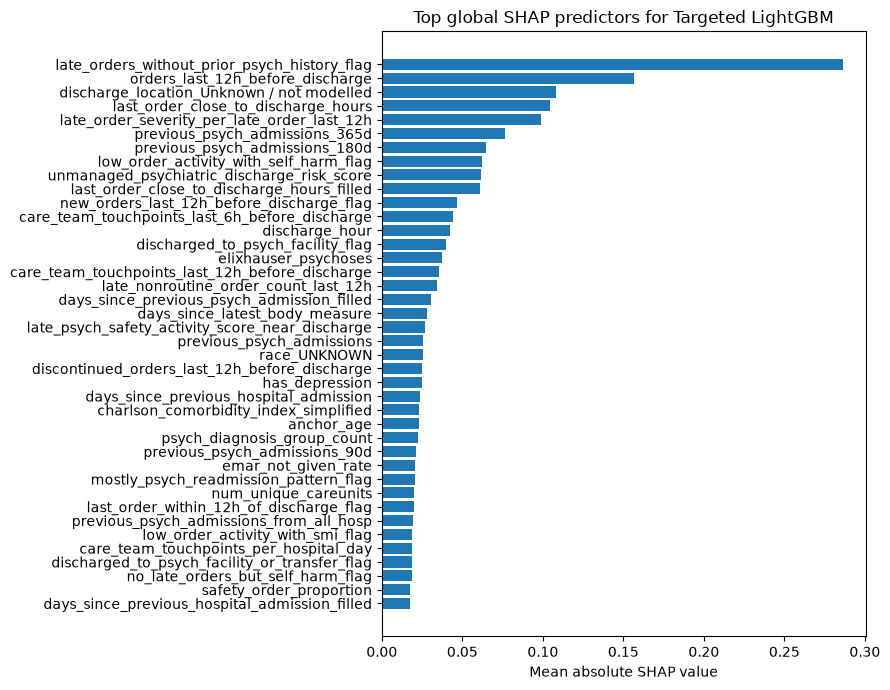

In [12]:
#plot top global shap features as a dissertation-friendly bar chart
top_n_global = 40
plot_global_df = shap_global_importance_df.head(top_n_global).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_global_df["feature_name_clean"], plot_global_df["mean_abs_shap"], color="#1f77b4")
plt.xlabel("Mean absolute SHAP value")
plt.title(f"Top global SHAP predictors for {final_model_family}")
plt.tight_layout()
plt.savefig(wp4_image_output_path / "t4_shap_top20_global_importance.png", dpi=300)
plt.show()

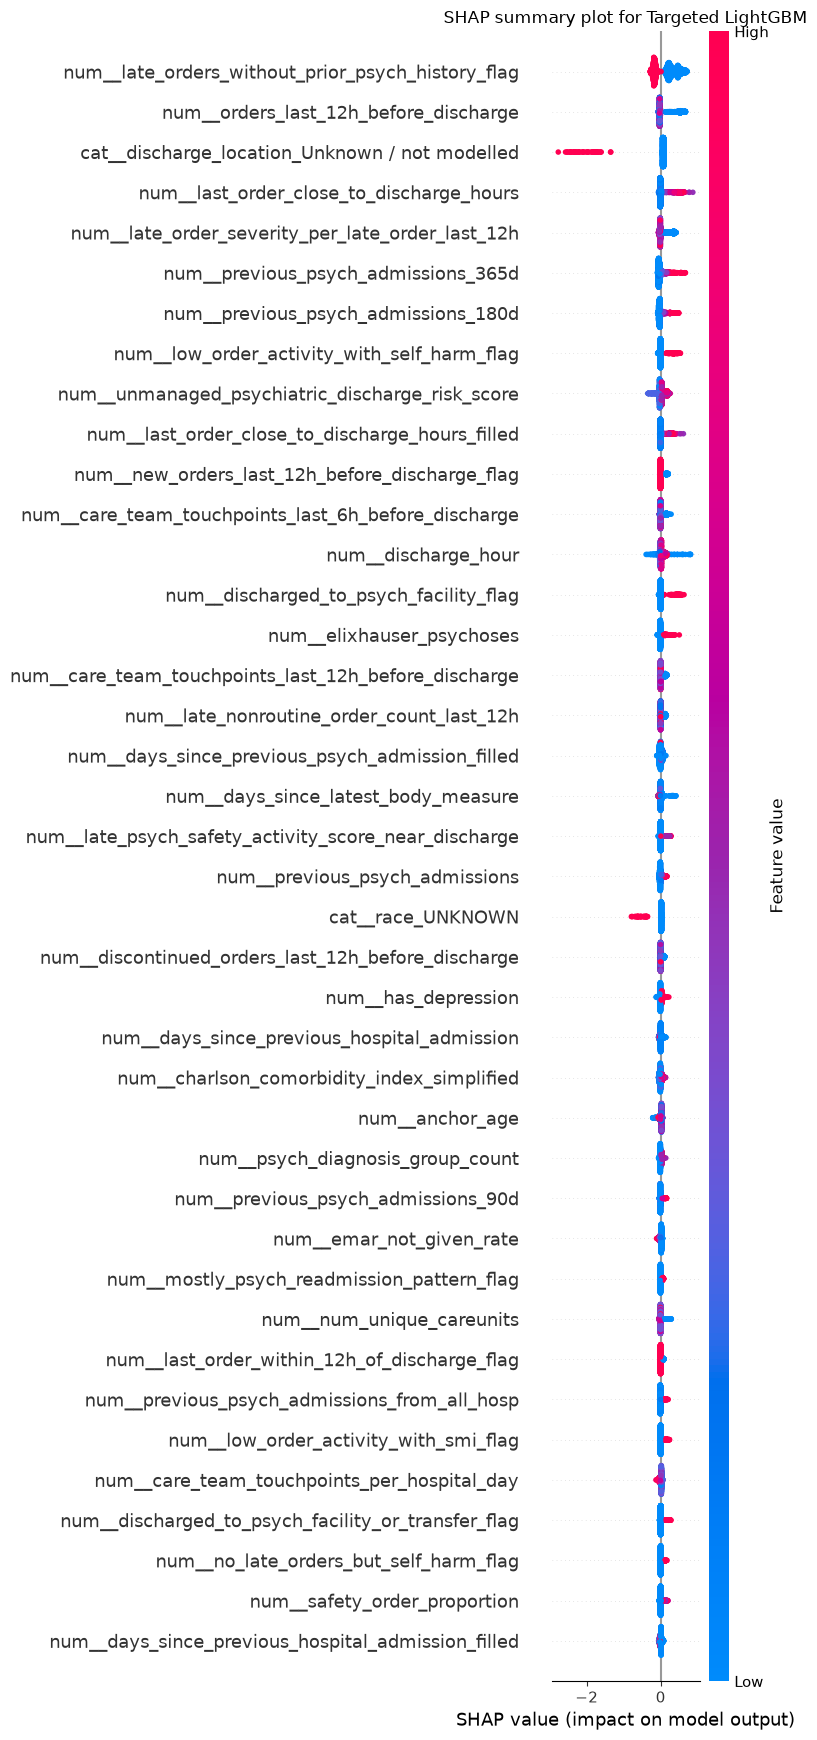

In [13]:
#create a shap beeswarm summary plot for the top predictors; the dense display matrix is only used for plotting sampled rows
if sparse.issparse(X_shap_display):
    X_shap_plot = X_shap_display.toarray()
else:
    X_shap_plot = np.asarray(X_shap_display)

plt.figure(figsize=(3, 7))
shap.summary_plot(shap_values, X_shap_plot, feature_names=processed_feature_names,
    max_display=40, show=False)
plt.title(f"SHAP summary plot for {final_model_family}")
plt.tight_layout()
plt.savefig(wp4_image_output_path / "t4_shap_summary_beeswarm_top20.png", dpi=300, bbox_inches="tight")
plt.show()

**4.3 - Diagnostic Explanation Analyses**

This section connects SHAP explanations back to the evaluation results from WP3.6. Instead of only asking which features matter globally, it asks four practical questions:

- Do false positives and false negatives rely on different feature signals from true positives and true negatives?
- Do major clinical subgroups use different feature families?
- Do high feature values generally push risk up or down?
- Do selected features show threshold-like relationships with predicted risk?

These analyses are descriptive. They explain the fitted model; they do not change the official model or threshold.





In [ ]:
#build diagnostic shap tables that connect explanation results to wp3.6 error and subgroup analyses
#these tables use the existing shap sample only, so they do not refit the model.
wp3_6_recommended_path = wp3_6_output_path / "csv_tables" / "recommended_model_comparison.csv"
wp4_selected_threshold = 0.39
if wp3_6_recommended_path.exists():
    recommended_rows_for_wp4 = pd.read_csv(wp3_6_recommended_path)
    model_threshold_rows = recommended_rows_for_wp4.loc[recommended_rows_for_wp4["model_family"].eq(final_model_family)]
    if not model_threshold_rows.empty and pd.notna(model_threshold_rows.iloc[0].get("threshold")):
        wp4_selected_threshold = float(model_threshold_rows.iloc[0]["threshold"])
elif final_performance_path.exists():
    performance_rows_for_wp4 = pd.read_csv(final_performance_path)
    if "threshold" in performance_rows_for_wp4.columns:
        wp4_selected_threshold = float(performance_rows_for_wp4.iloc[0]["threshold"])

shap_diagnostic_index_df = shap_sample_index_df.copy()
shap_diagnostic_index_df["predicted_label"] = (shap_diagnostic_index_df["predicted_probability"] >= wp4_selected_threshold).astype(int)
shap_diagnostic_index_df["classification_group"] = np.select([
    (shap_diagnostic_index_df["readmitted_30d"] == 1) & (shap_diagnostic_index_df["predicted_label"] == 1),
    (shap_diagnostic_index_df["readmitted_30d"] == 0) & (shap_diagnostic_index_df["predicted_label"] == 1),
    (shap_diagnostic_index_df["readmitted_30d"] == 1) & (shap_diagnostic_index_df["predicted_label"] == 0),
    (shap_diagnostic_index_df["readmitted_30d"] == 0) & (shap_diagnostic_index_df["predicted_label"] == 0)],
    ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")

#create a long shap table only for the sampled explanation rows. this powers error-group and subgroup summaries.
shap_long_df = pd.DataFrame(shap_values, columns=processed_feature_names)
shap_long_df.insert(0, "shap_sample_position", np.arange(shap_long_df.shape[0]))
shap_long_df = shap_long_df.melt(id_vars="shap_sample_position", var_name="processed_feature_name", value_name="shap_value")
feature_metadata_df = shap_global_importance_df[["processed_feature_name", "feature_name_clean", "feature_family", "mean_abs_shap"]].copy()
#join the derived features back to the admission table
shap_long_df = shap_long_df.merge(feature_metadata_df, on="processed_feature_name", how="left")
shap_long_df = shap_long_df.merge(
    shap_diagnostic_index_df[["test_row_index", "classification_group", "predicted_probability", "readmitted_30d"]].reset_index().rename(columns={"index": "shap_sample_position"}),
    on="shap_sample_position", how="left")
shap_long_df["abs_shap_value"] = shap_long_df["shap_value"].abs()

#mean shap by error group identifies features that systematically push each group up or down.
shap_error_group_mean_df = shap_long_df.groupby(["classification_group", "processed_feature_name", "feature_name_clean", "feature_family"], as_index=False).agg(
    mean_shap_value=("shap_value", "mean"),
    mean_abs_shap_value=("abs_shap_value", "mean"),
    sample_rows=("shap_sample_position", "nunique"))
shap_error_group_mean_df = shap_error_group_mean_df.sort_values(
    ["classification_group", "mean_abs_shap_value"], ascending=[True, False]).reset_index(drop=True)
#save this table or artefact for later review
shap_error_group_mean_df.to_csv(wp4_csv_output_path / "t4_shap_error_group_mean_contributions.csv", index=False)

#feature-family summaries are easier to write up than hundreds of single processed columns.
shap_error_group_family_df = shap_long_df.groupby(["classification_group", "feature_family"], as_index=False).agg(
    total_abs_shap=("abs_shap_value", "sum"),
    mean_abs_shap=("abs_shap_value", "mean"),
    mean_signed_shap=("shap_value", "mean"),
    sample_rows=("shap_sample_position", "nunique"))
shap_error_group_family_df = shap_error_group_family_df.sort_values(
    ["classification_group", "total_abs_shap"], ascending=[True, False]).reset_index(drop=True)
shap_error_group_family_df.to_csv(wp4_csv_output_path / "t4_shap_error_group_family_importance.csv", index=False)

#define contrast error groups
def contrast_error_groups(left_group, right_group, output_label):
    left_df = shap_error_group_mean_df.loc[shap_error_group_mean_df["classification_group"].eq(left_group),
        ["processed_feature_name", "feature_name_clean", "feature_family", "mean_shap_value", "mean_abs_shap_value"]].rename(
        columns={"mean_shap_value": f"{left_group}_mean_shap", "mean_abs_shap_value": f"{left_group}_mean_abs_shap"})
    right_df = shap_error_group_mean_df.loc[shap_error_group_mean_df["classification_group"].eq(right_group),
        ["processed_feature_name", "mean_shap_value", "mean_abs_shap_value"]].rename(
        columns={"mean_shap_value": f"{right_group}_mean_shap", "mean_abs_shap_value": f"{right_group}_mean_abs_shap"})
    #join the derived features back to the admission table
    contrast_df = left_df.merge(right_df, on="processed_feature_name", how="inner")
    if contrast_df.empty:
        return contrast_df
    contrast_df["signed_shap_difference"] = contrast_df[f"{left_group}_mean_shap"] - contrast_df[f"{right_group}_mean_shap"]
    contrast_df["absolute_shap_difference"] = contrast_df["signed_shap_difference"].abs()
    contrast_df = contrast_df.sort_values("absolute_shap_difference", ascending=False).reset_index(drop=True)
    #save this table or artefact for later review
    contrast_df.to_csv(wp4_csv_output_path / f"t4_shap_{output_label}_contrast.csv", index=False)
    return contrast_df

fp_vs_tp_shap_contrast_df = contrast_error_groups("false_positive", "true_positive", "fp_vs_tp")
fn_vs_tp_shap_contrast_df = contrast_error_groups("false_negative", "true_positive", "fn_vs_tp")
fn_vs_tn_shap_contrast_df = contrast_error_groups("false_negative", "true_negative", "fn_vs_tn")

#directionality estimates whether higher feature values usually push risk up or down in the shap sample.
feature_direction_rows = []
#loop through each item in this feature block
for feature_rank, feature_name in enumerate(shap_global_importance_df.head(60)["processed_feature_name"], start=1):
    feature_position = processed_feature_names.index(feature_name)
    feature_values = np.asarray(X_shap_plot[:, feature_position]).ravel()
    feature_shap_values = shap_values[:, feature_position]
    valid_mask = np.isfinite(feature_values) & np.isfinite(feature_shap_values)
    if valid_mask.sum() < 30 or np.nanstd(feature_values[valid_mask]) == 0:
        correlation_value = np.nan
    else:
        correlation_value = pd.Series(feature_values[valid_mask]).corr(pd.Series(feature_shap_values[valid_mask]), method="spearman")
    high_threshold = np.nanpercentile(feature_values[valid_mask], 75) if valid_mask.any() else np.nan
    low_threshold = np.nanpercentile(feature_values[valid_mask], 25) if valid_mask.any() else np.nan
    high_mean_shap = np.nanmean(feature_shap_values[valid_mask & (feature_values >= high_threshold)]) if valid_mask.any() else np.nan
    low_mean_shap = np.nanmean(feature_shap_values[valid_mask & (feature_values <= low_threshold)]) if valid_mask.any() else np.nan
    direction_label = "higher_values_increase_risk" if pd.notna(correlation_value) and correlation_value > 0.05 else (
        "higher_values_decrease_risk" if pd.notna(correlation_value) and correlation_value < -0.05 else "mixed_or_threshold_like")
    clean_name = feature_name.replace("num__", "").replace("cat__", "")
    feature_direction_rows.append({"importance_rank": feature_rank,
        "processed_feature_name": feature_name,
        "feature_name_clean": clean_name,
        "feature_family": assign_feature_family(clean_name),
        "mean_abs_shap": shap_global_importance_df.loc[shap_global_importance_df["processed_feature_name"].eq(feature_name), "mean_abs_shap"].iloc[0],
        "spearman_feature_value_vs_shap": correlation_value,
        "low_value_mean_shap": low_mean_shap,
        "high_value_mean_shap": high_mean_shap,
        "direction_label": direction_label})

shap_feature_directionality_df = pd.DataFrame(feature_direction_rows)
shap_feature_directionality_df.to_csv(wp4_csv_output_path / "t4_shap_feature_directionality_top60.csv", index=False)

print("Selected threshold used for WP4 error grouping:", wp4_selected_threshold)
print("Top SHAP features by error group:")
#summarise row-level records to admission-level features
display(shap_error_group_mean_df.groupby("classification_group").head(8))
print("Feature-family SHAP by error group:")
display(shap_error_group_family_df.groupby("classification_group").head(6))
print("Feature directionality for top SHAP predictors:")
display(shap_feature_directionality_df.head(30))

Selected threshold used for WP4 error grouping: 0.32
Top SHAP features by error group:


,classification_group,processed_feature_name,feature_name_clean,feature_family,mean_shap_value,mean_abs_shap_value,sample_rows
0,false_negative,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,poe_order_pathway,0.021667,0.189934,449
1,false_negative,cat__discharge_location_Unknown / not modelled,discharge_location_Unknown / not modelled,discharge_social,0.050288,0.069279,449
2,false_negative,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,-0.024134,0.057612,449
3,false_negative,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,-0.024621,0.047537,449
4,false_negative,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,prior_utilisation,0.007672,0.036293,449
5,false_negative,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,-0.025142,0.033850,449
6,false_negative,num__charlson_comorbidity_index_simplified,charlson_comorbidity_index_simplified,procedure_comorbidity,0.008113,0.032335,449
7,false_negative,num__days_since_previous_hospital_admission,days_since_previous_hospital_admission,prior_utilisation,0.003446,0.028494,449
954,false_positive,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,poe_order_pathway,0.271807,0.287404,111
955,false_positive,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.126856,0.144388,111


Feature-family SHAP by error group:


,classification_group,feature_family,total_abs_shap,mean_abs_shap,mean_signed_shap,sample_rows
0,false_negative,poe_order_pathway,256.334723,0.003244,-0.000406,449
1,false_negative,prior_utilisation,206.128166,0.004063,-0.000545,449
2,false_negative,laboratory,172.900897,0.002751,0.000114,449
3,false_negative,psychiatric_history,121.806358,0.002319,-0.000123,449
4,false_negative,discharge_social,112.395887,0.003338,0.001091,449
5,false_negative,other,107.042203,0.002509,0.000152,449
13,false_positive,prior_utilisation,92.943819,0.007410,0.005051,111
14,false_positive,poe_order_pathway,82.439714,0.004220,0.001937,111
15,false_positive,laboratory,39.312763,0.002530,0.000573,111
16,false_positive,psychiatric_history,37.442575,0.002883,0.000926,111


Feature directionality for top SHAP predictors:


,importance_rank,processed_feature_name,feature_name_clean,feature_family,mean_abs_shap,spearman_feature_value_vs_shap,low_value_mean_shap,high_value_mean_shap,direction_label
0,1,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,poe_order_pathway,0.286215,-0.830979,0.347792,-0.176341,higher_values_decrease_risk
1,2,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,0.156688,-0.563047,0.495684,-0.028099,higher_values_decrease_risk
2,3,cat__discharge_location_Unknown / not modelled,discharge_location_Unknown / not modelled,discharge_social,0.108066,-0.256310,0.063541,0.016169,higher_values_decrease_risk
3,4,num__last_order_close_to_discharge_hours,last_order_close_to_discharge_hours,poe_order_pathway,0.104434,0.134121,0.005483,0.368548,higher_values_increase_risk
4,5,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,poe_order_pathway,0.098736,-0.625109,0.308161,-0.019075,higher_values_decrease_risk
5,6,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.076587,0.733225,-0.050294,0.143809,higher_values_increase_risk
6,7,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,0.064863,0.770109,-0.041447,0.077714,higher_values_increase_risk
7,8,num__low_order_activity_with_self_harm_flag,low_order_activity_with_self_harm_flag,poe_order_pathway,0.062261,0.609507,-0.015706,0.035398,higher_values_increase_risk
8,9,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,0.061352,0.773598,-0.038462,0.096088,higher_values_increase_risk
9,10,num__last_order_close_to_discharge_hours_filled,last_order_close_to_discharge_hours_filled,poe_order_pathway,0.060967,0.239613,0.001409,0.217215,higher_values_increase_risk


**4.3.1 - Subgroup SHAP Summaries**

This subsection compares SHAP feature-family patterns across clinically meaningful groups. It is useful for explaining whether the model is relying on different signals in self-harm, severe mental illness, substance-use, prior-utilisation, older/medical-complexity, and discharge-pathway subgroups.





In [ ]:
#summarise shap feature-family importance within clinically meaningful subgroups
subgroup_shap_family_df = pd.DataFrame()
subgroup_shap_top_features_df = pd.DataFrame()
wp2_3_dataset_path = project_path / "outputs" / "t2_3_engineered_dataset.csv"

if not wp2_3_dataset_path.exists() or not {"subject_id", "hadm_id"}.issubset(shap_diagnostic_index_df.columns):
    print("Subgroup SHAP summaries skipped because the engineered dataset or ID columns are unavailable.")
else:
    available_subgroup_cols = pd.read_csv(wp2_3_dataset_path, nrows=0).columns.tolist()
    candidate_subgroup_cols = [column for column in [
        "has_self_harm_or_suicidal_ideation", "has_severe_mental_illness", "has_substance_use",
        "has_psychotic_disorder", "elixhauser_psychoses", "previous_psych_admissions_365d",
        "previous_psych_admissions_90d", "previous_psych_admissions_from_all_hosp",
        "age_65plus", "discharged_home_flag", "discharged_to_psych_facility_flag",
        "discharged_to_facility_flag", "charlson_comorbidity_index_simplified"] if column in available_subgroup_cols]
    subgroup_source_df = pd.read_csv(wp2_3_dataset_path, usecols=["subject_id", "hadm_id"] + candidate_subgroup_cols)
    #join the derived features back to the admission table
    subgroup_index_df = shap_diagnostic_index_df[["subject_id", "hadm_id"]].merge(subgroup_source_df,
        on=["subject_id", "hadm_id"], how="left")
    #loop through each item in this feature block
    for column in candidate_subgroup_cols:
        subgroup_index_df[column] = pd.to_numeric(subgroup_index_df[column], errors="coerce").fillna(0)

    #define subgroup series
    def subgroup_series(column):
        return subgroup_index_df[column] if column in subgroup_index_df.columns else pd.Series(0, index=subgroup_index_df.index)

    subgroup_flags = pd.DataFrame({
        "shap_sample_position": np.arange(len(subgroup_index_df)),
        "self_harm_or_suicidal_ideation": subgroup_series("has_self_harm_or_suicidal_ideation") > 0,
        "severe_mental_illness_or_psychosis": (subgroup_series("has_severe_mental_illness") + subgroup_series("has_psychotic_disorder") + subgroup_series("elixhauser_psychoses")) > 0,
        "substance_use_related": subgroup_series("has_substance_use") > 0,
        "prior_psych_utilisation": (subgroup_series("previous_psych_admissions_365d") + subgroup_series("previous_psych_admissions_90d") + subgroup_series("previous_psych_admissions_from_all_hosp")) > 0,
        "older_or_medically_complex": (subgroup_series("age_65plus") > 0) | (subgroup_series("charlson_comorbidity_index_simplified") >= 3),
        "home_discharge": subgroup_series("discharged_home_flag") > 0,
        "psych_or_facility_discharge": (subgroup_series("discharged_to_psych_facility_flag") + subgroup_series("discharged_to_facility_flag")) > 0})

    subgroup_long_rows = []
    for subgroup_name in [column for column in subgroup_flags.columns if column != "shap_sample_position"]:
        member_positions = subgroup_flags.loc[subgroup_flags[subgroup_name], "shap_sample_position"]
        if len(member_positions) < 50:
            continue
        subgroup_temp = shap_long_df.loc[shap_long_df["shap_sample_position"].isin(member_positions)].copy()
        subgroup_temp["subgroup_name"] = subgroup_name
        subgroup_temp["subgroup_sample_rows"] = len(member_positions)
        subgroup_long_rows.append(subgroup_temp)
        
    if subgroup_long_rows:
        subgroup_shap_long_df = pd.concat(subgroup_long_rows, ignore_index=True)
        #summarise row-level records to admission-level features
        subgroup_shap_family_df = subgroup_shap_long_df.groupby(["subgroup_name", "feature_family"], as_index=False).agg(
            subgroup_sample_rows=("subgroup_sample_rows", "first"),
            total_abs_shap=("abs_shap_value", "sum"),
            mean_abs_shap=("abs_shap_value", "mean"),
            mean_signed_shap=("shap_value", "mean"))
        subgroup_shap_family_df = subgroup_shap_family_df.sort_values(
            ["subgroup_name", "total_abs_shap"], ascending=[True, False]).reset_index(drop=True)
        subgroup_shap_top_features_df = subgroup_shap_long_df.groupby(
            ["subgroup_name", "processed_feature_name", "feature_name_clean", "feature_family"], as_index=False).agg(
            subgroup_sample_rows=("subgroup_sample_rows", "first"),
            mean_abs_shap=("abs_shap_value", "mean"),
            mean_signed_shap=("shap_value", "mean"))
        subgroup_shap_top_features_df = subgroup_shap_top_features_df.sort_values(
            #summarise row-level records to admission-level features
            ["subgroup_name", "mean_abs_shap"], ascending=[True, False]).groupby("subgroup_name", as_index=False).head(10).reset_index(drop=True)
        #save this table or artefact for later review
        subgroup_shap_family_df.to_csv(wp4_csv_output_path / "t4_shap_subgroup_family_importance.csv", index=False)
        subgroup_shap_top_features_df.to_csv(wp4_csv_output_path / "t4_shap_subgroup_top_features.csv", index=False)
        print("Top SHAP feature families by subgroup:")
        display(subgroup_shap_family_df.groupby("subgroup_name").head(5))
        print("Top SHAP features by subgroup:")
        display(subgroup_shap_top_features_df.groupby("subgroup_name").head(5))
    else:
        print("Subgroup SHAP summaries skipped because no subgroup had enough sampled rows.")

Top SHAP feature families by subgroup:


,subgroup_name,feature_family,subgroup_sample_rows,total_abs_shap,mean_abs_shap,mean_signed_shap
0,home_discharge,poe_order_pathway,579,328.415681,0.003223,-0.000451
1,home_discharge,prior_utilisation,579,318.354650,0.004866,0.000275
2,home_discharge,laboratory,579,219.953961,0.002713,0.000092
3,home_discharge,psychiatric_history,579,153.300916,0.002263,0.000124
4,home_discharge,other,579,134.773566,0.002450,0.000129
13,older_or_medically_complex,poe_order_pathway,956,723.497396,0.004300,0.000990
14,older_or_medically_complex,prior_utilisation,956,470.686959,0.004357,0.000295
15,older_or_medically_complex,laboratory,956,390.865673,0.002920,0.000443
16,older_or_medically_complex,discharge_social,956,362.846094,0.005061,-0.000110
17,older_or_medically_complex,psychiatric_history,956,296.193587,0.002648,0.000400


Top SHAP features by subgroup:


,subgroup_name,processed_feature_name,feature_name_clean,feature_family,subgroup_sample_rows,mean_abs_shap,mean_signed_shap
0,home_discharge,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,poe_order_pathway,579,0.208353,0.037145
1,home_discharge,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,579,0.086476,0.004640
2,home_discharge,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,579,0.074734,0.007998
3,home_discharge,cat__discharge_location_Unknown / not modelled,discharge_location_Unknown / not modelled,discharge_social,579,0.058006,0.058006
4,home_discharge,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,prior_utilisation,579,0.037796,0.001641
10,older_or_medically_complex,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,poe_order_pathway,956,0.220364,0.063264
11,older_or_medically_complex,cat__discharge_location_Unknown / not modelled,discharge_location_Unknown / not modelled,discharge_social,956,0.162321,-0.046084
12,older_or_medically_complex,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,956,0.075261,0.002440
13,older_or_medically_complex,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,956,0.063880,0.003534
14,older_or_medically_complex,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,956,0.062997,0.015122


**4.3.2 - Dependence-Style Plots for Key Predictors**

These plots show how selected high-ranking features relate to SHAP contribution and predicted risk. They are not formal causal effects; they are visual checks for threshold-like behaviour, nonlinear patterns, and outliers.





Dependence-style plot features selected from current SHAP ranking:


,importance_rank,processed_feature_name,feature_name_clean,feature_family,mean_abs_shap
0,1,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,poe_order_pathway,0.286215
1,2,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,0.156688
2,3,cat__discharge_location_Unknown / not modelled,discharge_location_Unknown / not modelled,discharge_social,0.108066
5,6,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.076587
6,7,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,0.064863
8,9,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,0.061352
11,12,num__care_team_touchpoints_last_6h_before_disc...,care_team_touchpoints_last_6h_before_discharge,care_team_complexity,0.044184
12,13,num__discharge_hour,discharge_hour,discharge_social,0.042083


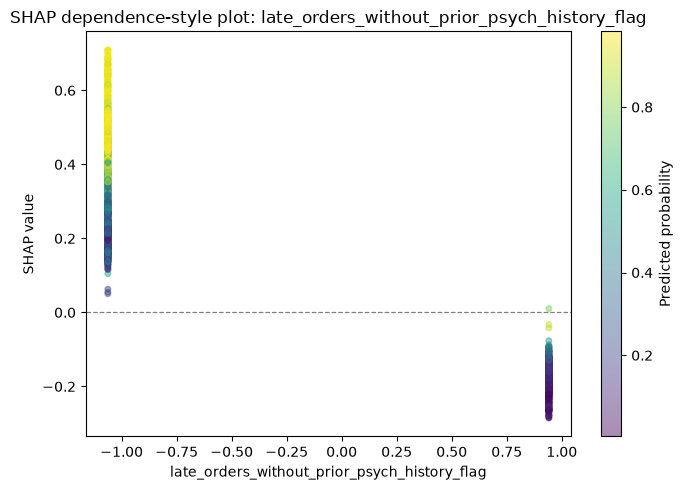

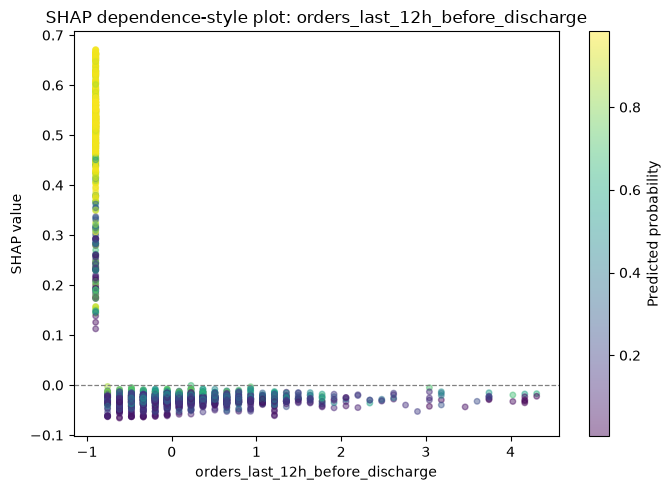

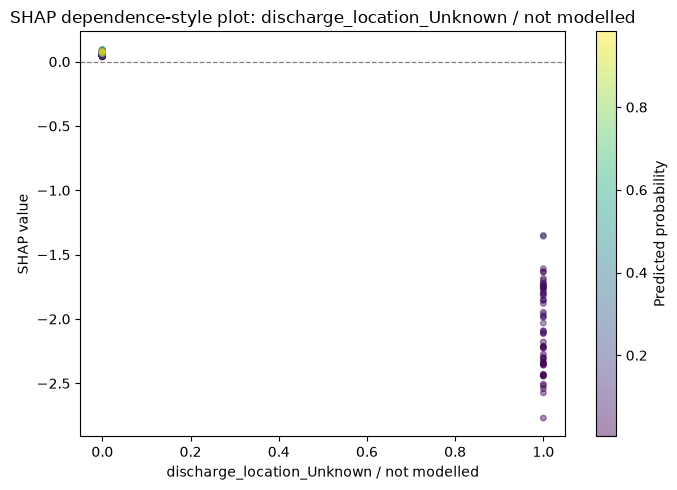

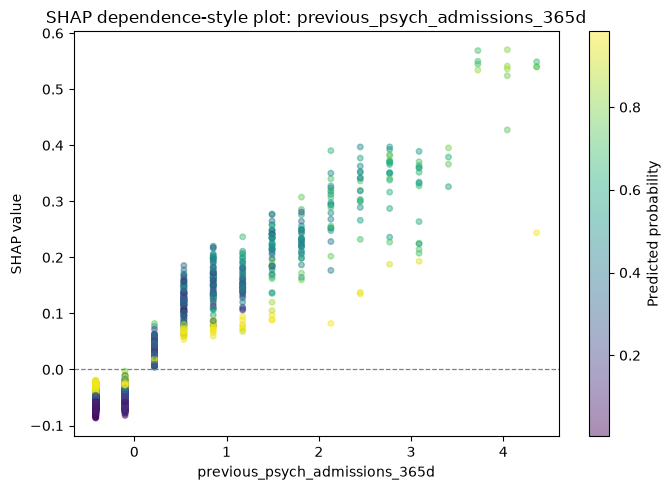

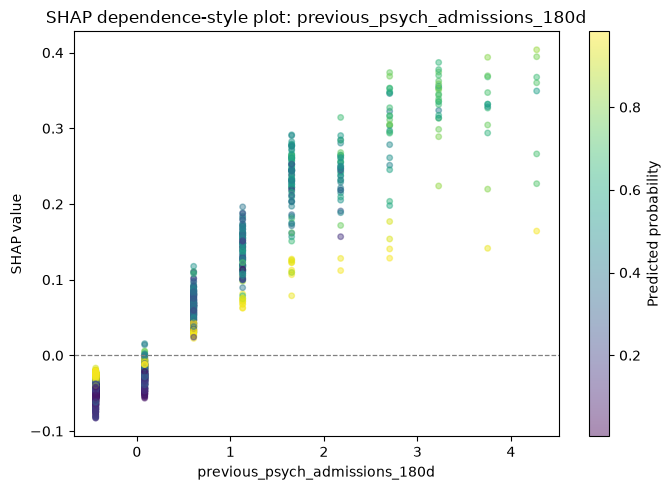

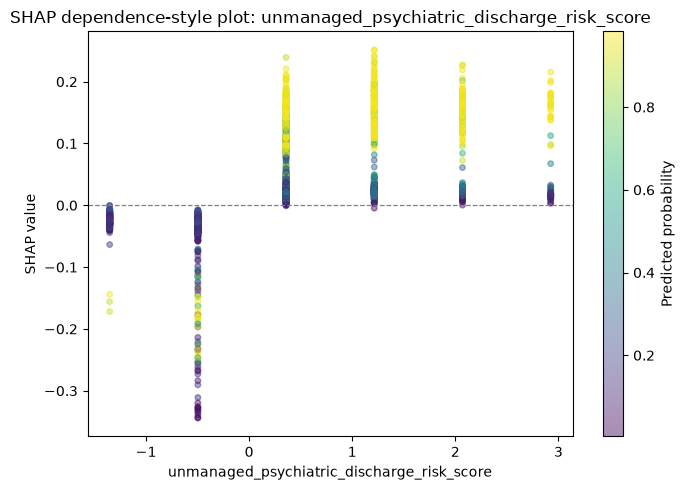

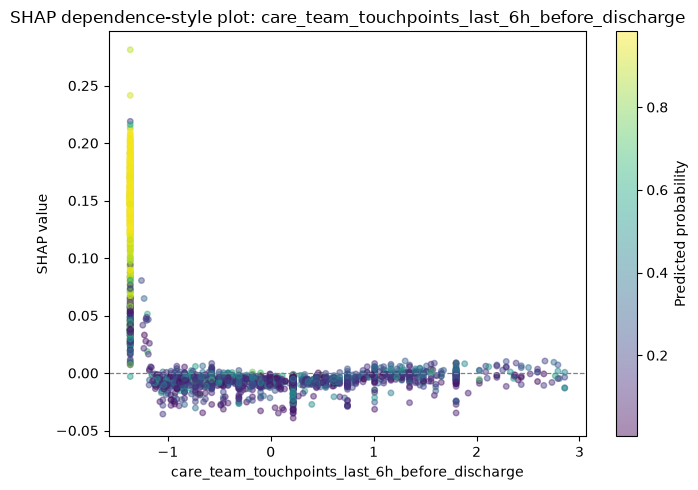

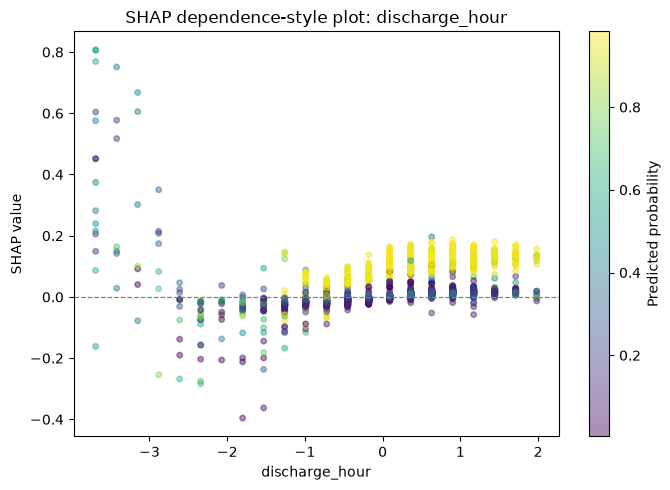

Dependence-style SHAP plots created:


,importance_rank,processed_feature_name,feature_name_clean,feature_family,mean_abs_shap,plotted_rows,raw_rows,x_axis_1st_percentile,x_axis_99th_percentile,selection_method,plot_file
0,1,num__late_orders_without_prior_psych_history_flag,late_orders_without_prior_psych_history_flag,poe_order_pathway,0.286215,2500,2500,-1.062531,0.941149,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...
1,2,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,0.156688,2476,2500,-0.898280,4.308367,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...
2,3,cat__discharge_location_Unknown / not modelled,discharge_location_Unknown / not modelled,discharge_social,0.108066,2500,2500,0.000000,1.000000,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...
3,6,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.076587,2476,2500,-0.419199,4.362055,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...
4,7,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,0.064863,2475,2500,-0.440796,4.281060,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...
5,9,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,0.061352,2483,2500,-1.352664,2.925139,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...
6,12,num__care_team_touchpoints_last_6h_before_disc...,care_team_touchpoints_last_6h_before_discharge,care_team_complexity,0.044184,2475,2500,-1.365069,2.857036,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...
7,13,num__discharge_hour,discharge_hour,discharge_social,0.042083,2472,2500,-3.691629,1.981689,top_shap_with_family_cap,/scratch/DissProject/outputs/WP4/images/t4_sha...


In [ ]:
#create dependence-style scatter plots for automatically selected high-ranking predictors
#the candidates are selected from the current shap ranking, so this section follows the model actually being explained.
#a small family cap keeps the plots informative instead of filling the page with near-duplicate late-order variables.
dependence_max_features = 8
dependence_max_per_family = 2
minimum_unique_values_for_dependence = 2

ranked_dependence_candidates_df = shap_global_importance_df.copy()
if "feature_family" not in ranked_dependence_candidates_df.columns:
    ranked_dependence_candidates_df["feature_family"] = ranked_dependence_candidates_df["feature_name_clean"].apply(assign_feature_family)

#dependence plots are most useful for numeric/binary columns with variation in the shap sample.
#very sparse one-hot columns are skipped unless they still have at least two values in the plotted sample.
dependence_feature_candidates = []
dependence_family_counts = {}
#loop through each item in this feature block
for _, feature_row in ranked_dependence_candidates_df.sort_values("importance_rank").iterrows():
    feature_name = feature_row["processed_feature_name"]
    feature_family = feature_row.get("feature_family", "other")
    if feature_name not in processed_feature_names:
        continue
    feature_position = processed_feature_names.index(feature_name)
    feature_values = np.asarray(X_shap_plot[:, feature_position]).ravel()
    finite_feature_values = feature_values[np.isfinite(feature_values)]
    if len(finite_feature_values) == 0 or pd.Series(finite_feature_values).nunique() < minimum_unique_values_for_dependence:
        continue
    if dependence_family_counts.get(feature_family, 0) >= dependence_max_per_family:
        continue
    dependence_feature_candidates.append(feature_name)
    dependence_family_counts[feature_family] = dependence_family_counts.get(feature_family, 0) + 1
    if len(dependence_feature_candidates) >= dependence_max_features:
        break

selected_dependence_candidates_df = ranked_dependence_candidates_df.loc[
    ranked_dependence_candidates_df["processed_feature_name"].isin(dependence_feature_candidates),
    ["importance_rank", "processed_feature_name", "feature_name_clean", "feature_family", "mean_abs_shap"]].sort_values("importance_rank")

print("Dependence-style plot features selected from current SHAP ranking:")
display(selected_dependence_candidates_df)

dependence_rows = []
for feature_name in dependence_feature_candidates:
    feature_position = processed_feature_names.index(feature_name)
    feature_values = np.asarray(X_shap_plot[:, feature_position]).ravel()
    feature_shap_values = shap_values[:, feature_position]
    clean_name = feature_name.replace("num__", "").replace("cat__", "")
    feature_family = shap_global_importance_df.loc[
        shap_global_importance_df["processed_feature_name"].eq(feature_name), "feature_family"].iloc[0]
    importance_rank = int(shap_global_importance_df.loc[
        shap_global_importance_df["processed_feature_name"].eq(feature_name), "importance_rank"].iloc[0])
    mean_abs_shap = float(shap_global_importance_df.loc[
        shap_global_importance_df["processed_feature_name"].eq(feature_name), "mean_abs_shap"].iloc[0])
    plot_df = pd.DataFrame({"feature_value": feature_values,
        "shap_value": feature_shap_values,
        "predicted_probability": shap_diagnostic_index_df["predicted_probability"].values,
        "classification_group": shap_diagnostic_index_df["classification_group"].values})
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["feature_value", "shap_value"])
    if plot_df.empty or plot_df["feature_value"].nunique() < minimum_unique_values_for_dependence:
        continue
    lower_x, upper_x = plot_df["feature_value"].quantile([0.01, 0.99])
    plot_display_df = plot_df.loc[plot_df["feature_value"].between(lower_x, upper_x)].copy()
    output_path = wp4_image_output_path / f"t4_shap_dependence_rank{importance_rank:02d}_{clean_name[:60].replace('/', '_')}.png"
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(plot_display_df["feature_value"], plot_display_df["shap_value"],
        c=plot_display_df["predicted_probability"], cmap="viridis", alpha=0.45, s=16)
    plt.axhline(0, color="gray", linestyle="--", linewidth=0.9)
    plt.xlabel(clean_name)
    plt.ylabel("SHAP value")
    plt.title(f"SHAP dependence-style plot: {clean_name}")
    plt.colorbar(scatter, label="Predicted probability")
    plt.tight_layout()
    plt.savefig(output_path, dpi=260, bbox_inches="tight")
    plt.show()
    plt.close()
    dependence_rows.append({"importance_rank": importance_rank, "processed_feature_name": feature_name,
        "feature_name_clean": clean_name, "feature_family": feature_family, "mean_abs_shap": mean_abs_shap,
        "plotted_rows": len(plot_display_df), "raw_rows": len(plot_df), "x_axis_1st_percentile": lower_x,
        "x_axis_99th_percentile": upper_x, "selection_method": "top_shap_with_family_cap", "plot_file": str(output_path)})

shap_dependence_plot_summary_df = pd.DataFrame(dependence_rows)
#save this table or artefact for later review
shap_dependence_plot_summary_df.to_csv(wp4_csv_output_path / "t4_shap_dependence_plot_summary.csv", index=False)
print("Dependence-style SHAP plots created:")
display(shap_dependence_plot_summary_df)

**4.4 - Local Explanations**

This section explains individual admissions. It selects representative true-positive, false-positive, false-negative, and true-negative cases from the held-out explanation sample, then lists the strongest positive and negative SHAP contributors for each case.





In [17]:
#select representative local explanation cases from the shap sample
#the official threshold is read from wp3.4 when available; otherwise 0.39 is used as a stable fallback
selected_threshold = wp4_selected_threshold if "wp4_selected_threshold" in globals() else 0.39
if "wp4_selected_threshold" not in globals() and final_performance_path.exists():
    final_performance_df = pd.read_csv(final_performance_path)
    preferred_threshold_rows = final_performance_df.loc[final_performance_df["threshold_role"].isin(["official", "training_f1", "selected"])]
    if not preferred_threshold_rows.empty:
        selected_threshold = float(preferred_threshold_rows.iloc[0]["threshold"])

local_case_df = shap_sample_index_df.copy()
local_case_df["predicted_label"] = (local_case_df["predicted_probability"] >= selected_threshold).astype(int)
local_case_df["classification_group"] = np.select([
    (local_case_df["readmitted_30d"] == 1) & (local_case_df["predicted_label"] == 1),
    (local_case_df["readmitted_30d"] == 0) & (local_case_df["predicted_label"] == 1),
    (local_case_df["readmitted_30d"] == 1) & (local_case_df["predicted_label"] == 0),
    (local_case_df["readmitted_30d"] == 0) & (local_case_df["predicted_label"] == 0)],
    ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")

local_selection_rules = {"high_risk_stratum_case": (None, False),
    "low_risk_stratum_case": (None, True),
    "true_positive_highest_risk": ("true_positive", False),
    "false_positive_highest_risk": ("false_positive", False),
    "false_negative_lowest_risk": ("false_negative", True),
    "true_negative_lowest_risk": ("true_negative", True)}

selected_local_rows = []
for case_label, (classification_group, ascending_probability) in local_selection_rules.items():
    if classification_group is None:
        candidate_rows = local_case_df.copy()
    else:
        candidate_rows = local_case_df.loc[local_case_df["classification_group"] == classification_group].copy()
    if candidate_rows.empty:
        continue
    selected_row = candidate_rows.sort_values("predicted_probability", ascending=ascending_probability).iloc[0].copy()
    selected_row["local_case_label"] = case_label
    selected_local_rows.append(selected_row)

selected_local_cases_df = pd.DataFrame(selected_local_rows).drop_duplicates("test_row_index").reset_index(drop=True)
selected_local_cases_df.to_csv(wp4_csv_output_path / "t4_shap_selected_local_cases.csv", index=False)
print("Selected threshold for local classification:", selected_threshold)
print("Selected local explanation cases:")
display(selected_local_cases_df[["local_case_label", "subject_id", "hadm_id", "readmitted_30d", "predicted_probability", "classification_group"]])

Selected threshold for local classification: 0.32
Selected local explanation cases:


,local_case_label,subject_id,hadm_id,readmitted_30d,predicted_probability,classification_group
0,high_risk_stratum_case,18122969,21943419,1,0.983200,true_positive
1,low_risk_stratum_case,19059584,22602619,0,0.003641,true_negative
2,false_positive_highest_risk,17483772,20538623,0,0.957430,false_positive
3,false_negative_lowest_risk,14897280,21852536,1,0.006732,false_negative


In [18]:
#create local top-contribution tables for the selected admissions
local_top_feature_rows = []
local_summary_rows = []

#loop through each item in this feature block
for _, case_row in selected_local_cases_df.iterrows():
    sample_position = int(case_row.name)
    shap_sample_position = shap_sample_index_df.index[shap_sample_index_df["test_row_index"] == case_row["test_row_index"]].tolist()[0]
    row_shap_values = shap_values[shap_sample_position]
    row_feature_values = X_shap_plot[shap_sample_position]
    log_odds_prediction_from_shap = base_value + row_shap_values.sum()
    probability_prediction_from_shap = expit(log_odds_prediction_from_shap)

    local_summary_rows.append({"local_case_label": case_row["local_case_label"],
        "subject_id": case_row.get("subject_id"),
        "hadm_id": case_row.get("hadm_id"),
        "classification_group": case_row["classification_group"],
        "readmitted_30d": case_row["readmitted_30d"],
        "predicted_probability": case_row["predicted_probability"],
        "shap_reconstructed_probability": probability_prediction_from_shap,
        "shap_base_value_log_odds": base_value,
        "shap_sum_log_odds": row_shap_values.sum()})

    local_feature_df = pd.DataFrame({"processed_feature_name": processed_feature_names,
        "feature_value": row_feature_values,
        "shap_value": row_shap_values})
    local_feature_df["abs_shap_value"] = local_feature_df["shap_value"].abs()
    local_feature_df["feature_name_clean"] = local_feature_df["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
    local_feature_df["feature_family"] = local_feature_df["feature_name_clean"].apply(assign_feature_family)
    top_positive_df = local_feature_df.sort_values("shap_value", ascending=False).head(10).copy()
    top_negative_df = local_feature_df.sort_values("shap_value", ascending=True).head(10).copy()
    top_positive_df["contribution_direction"] = "increases_predicted_risk"
    top_negative_df["contribution_direction"] = "decreases_predicted_risk"
    top_local_df = pd.concat([top_positive_df, top_negative_df], ignore_index=True)
    top_local_df.insert(0, "local_case_label", case_row["local_case_label"])
    top_local_df.insert(1, "classification_group", case_row["classification_group"])
    top_local_df.insert(2, "subject_id", case_row.get("subject_id"))
    top_local_df.insert(3, "hadm_id", case_row.get("hadm_id"))
    local_top_feature_rows.append(top_local_df)

local_explanation_summary_df = pd.DataFrame(local_summary_rows)
local_top_features_df = pd.concat(local_top_feature_rows, ignore_index=True) if local_top_feature_rows else pd.DataFrame()

#save this table or artefact for later review
local_explanation_summary_df.to_csv(wp4_csv_output_path / "t4_shap_local_explanation_summary.csv", index=False)
local_top_features_df.to_csv(wp4_csv_output_path / "t4_shap_local_top_features.csv", index=False)

print("Local explanation summary:")
display(local_explanation_summary_df)
print("Local top SHAP features:")
display(local_top_features_df.head(40))

Local explanation summary:


,local_case_label,subject_id,hadm_id,classification_group,readmitted_30d,predicted_probability,shap_reconstructed_probability,shap_base_value_log_odds,shap_sum_log_odds
0,high_risk_stratum_case,18122969,21943419,true_positive,1,0.983200,0.983200,-1.562953,5.632361
1,low_risk_stratum_case,19059584,22602619,true_negative,0,0.003641,0.003641,-1.562953,-4.048922
2,false_positive_highest_risk,17483772,20538623,false_positive,0,0.957430,0.957430,-1.562953,4.676054
3,false_negative_lowest_risk,14897280,21852536,false_negative,1,0.006732,0.006732,-1.562953,-3.431216


Local top SHAP features:


,local_case_label,classification_group,subject_id,hadm_id,processed_feature_name,feature_value,shap_value,abs_shap_value,feature_name_clean,feature_family,contribution_direction
0,high_risk_stratum_case,true_positive,18122969,21943419,num__last_order_close_to_discharge_hours,2.519716,0.608907,0.608907,last_order_close_to_discharge_hours,poe_order_pathway,increases_predicted_risk
1,high_risk_stratum_case,true_positive,18122969,21943419,num__orders_last_12h_before_discharge,-0.898280,0.565411,0.565411,orders_last_12h_before_discharge,poe_order_pathway,increases_predicted_risk
2,high_risk_stratum_case,true_positive,18122969,21943419,num__late_orders_without_prior_psych_history_flag,-1.062531,0.487549,0.487549,late_orders_without_prior_psych_history_flag,poe_order_pathway,increases_predicted_risk
3,high_risk_stratum_case,true_positive,18122969,21943419,num__late_order_severity_per_late_order_last_12h,-1.894356,0.393736,0.393736,late_order_severity_per_late_order_last_12h,poe_order_pathway,increases_predicted_risk
4,high_risk_stratum_case,true_positive,18122969,21943419,num__last_order_close_to_discharge_hours_filled,2.519716,0.354556,0.354556,last_order_close_to_discharge_hours_filled,poe_order_pathway,increases_predicted_risk
5,high_risk_stratum_case,true_positive,18122969,21943419,num__discharged_to_psych_facility_flag,8.944225,0.264049,0.264049,discharged_to_psych_facility_flag,psychiatric_history,increases_predicted_risk
6,high_risk_stratum_case,true_positive,18122969,21943419,num__low_order_activity_with_self_harm_flag,6.975300,0.263670,0.263670,low_order_activity_with_self_harm_flag,poe_order_pathway,increases_predicted_risk
7,high_risk_stratum_case,true_positive,18122969,21943419,num__care_team_touchpoints_last_6h_before_disc...,-1.365069,0.210482,0.210482,care_team_touchpoints_last_6h_before_discharge,care_team_complexity,increases_predicted_risk
8,high_risk_stratum_case,true_positive,18122969,21943419,num__new_orders_last_12h_before_discharge_flag,-3.252001,0.159670,0.159670,new_orders_last_12h_before_discharge_flag,poe_order_pathway,increases_predicted_risk
9,high_risk_stratum_case,true_positive,18122969,21943419,num__care_team_touchpoints_last_12h_before_dis...,-1.502933,0.146977,0.146977,care_team_touchpoints_last_12h_before_discharge,care_team_complexity,increases_predicted_risk


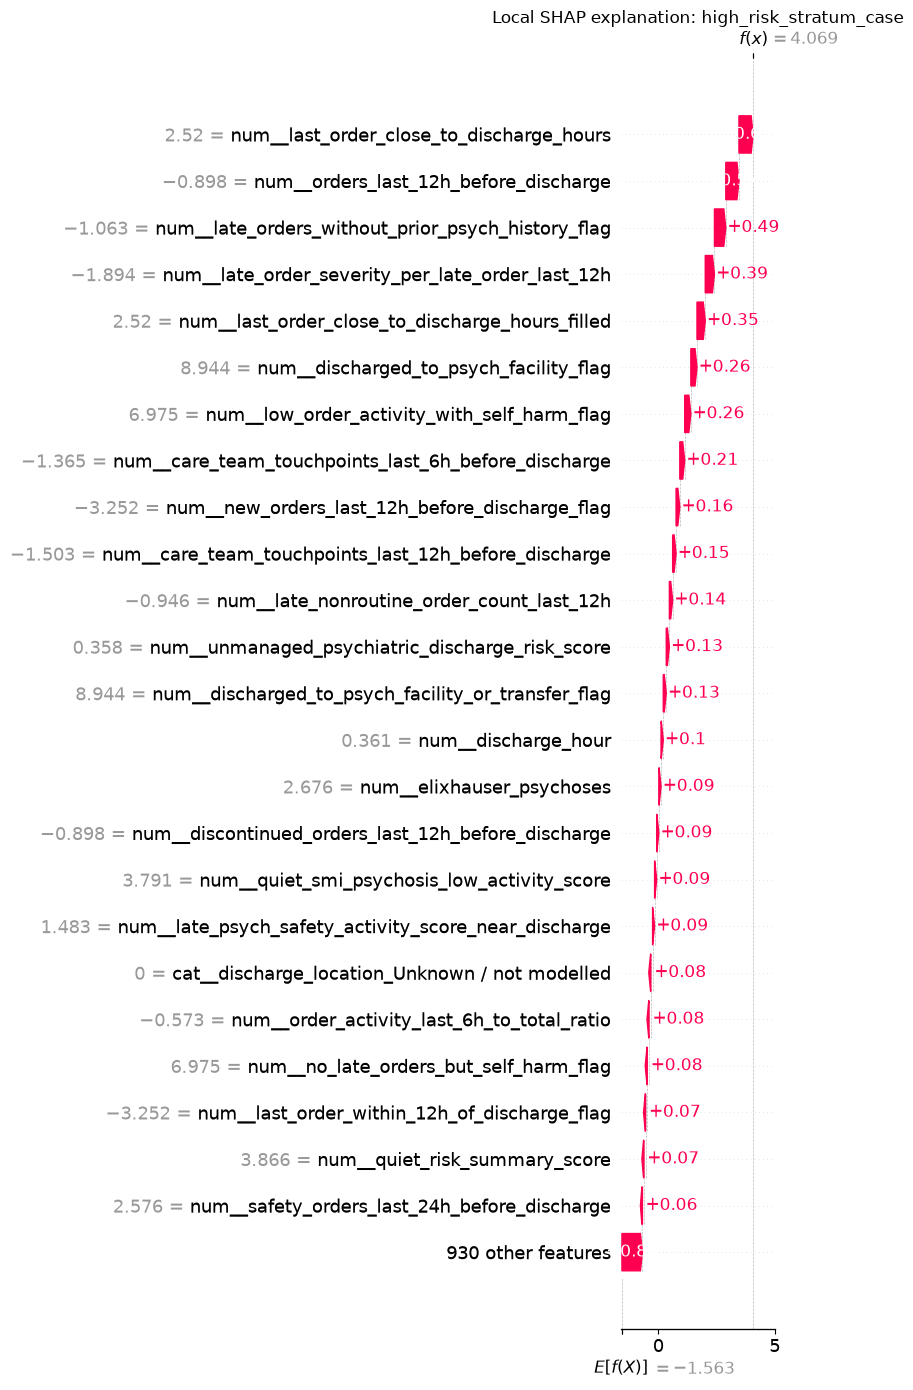

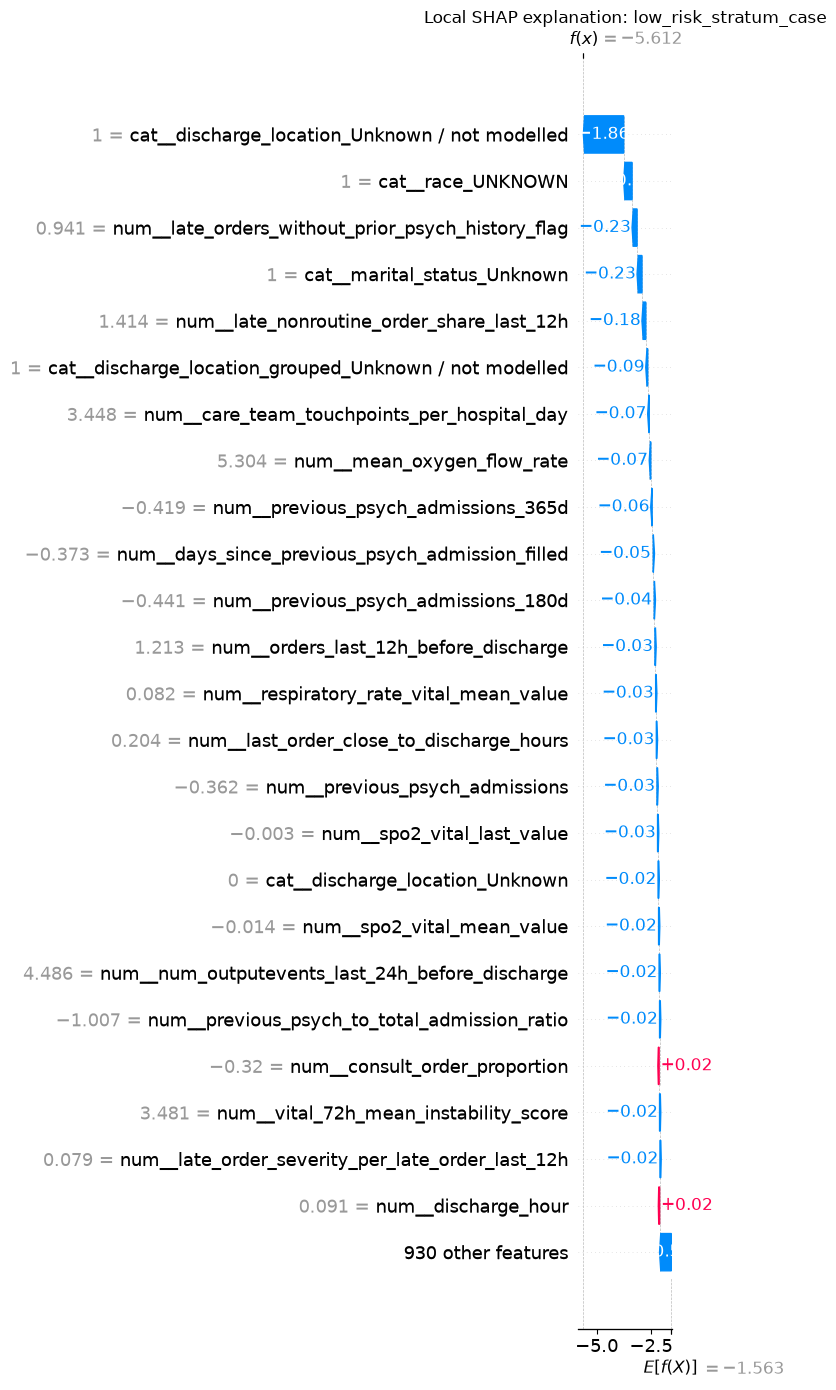

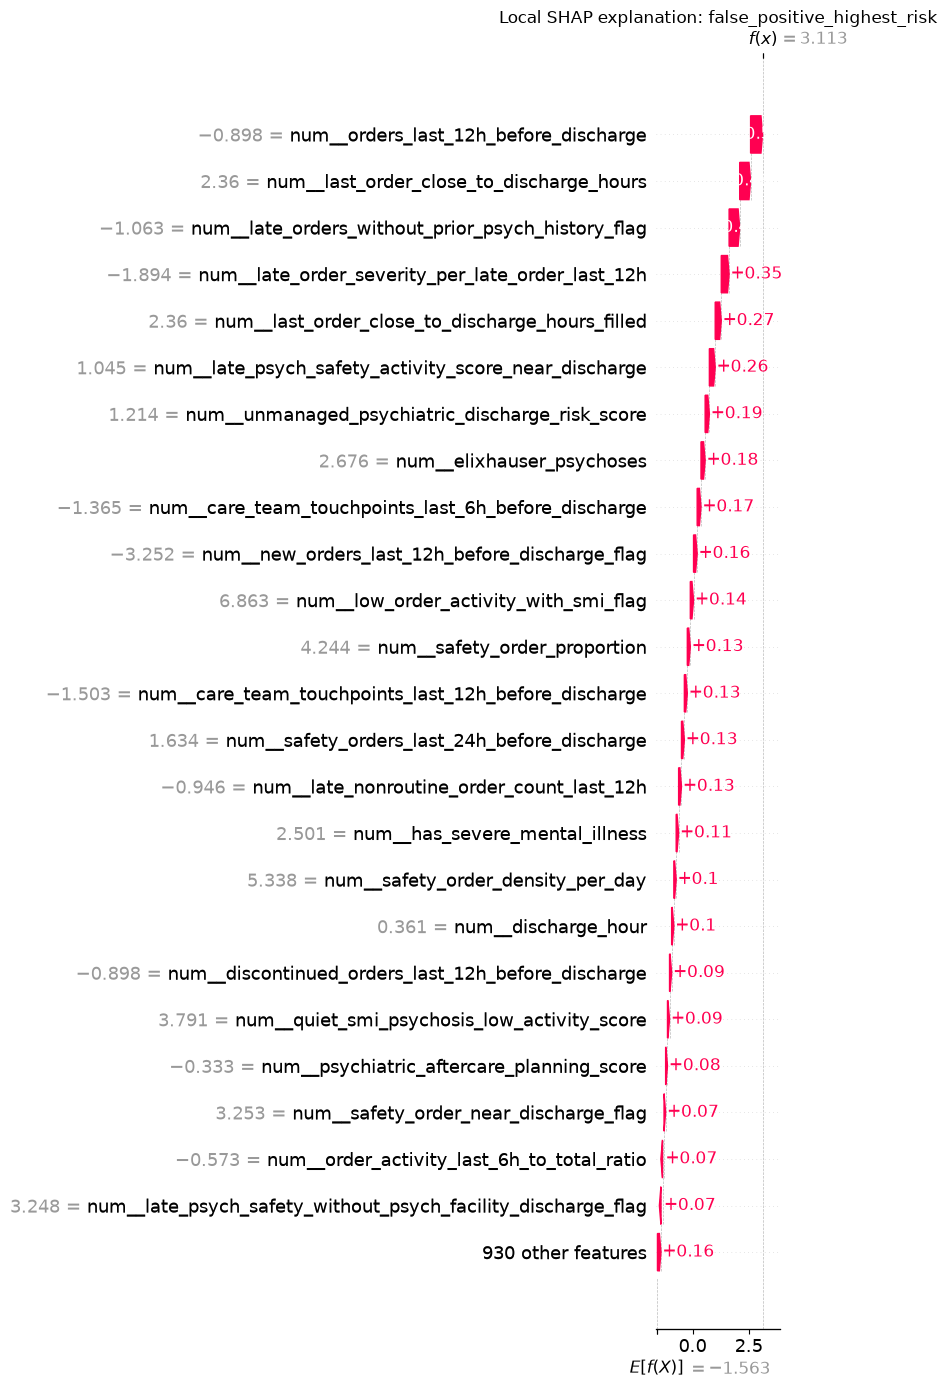

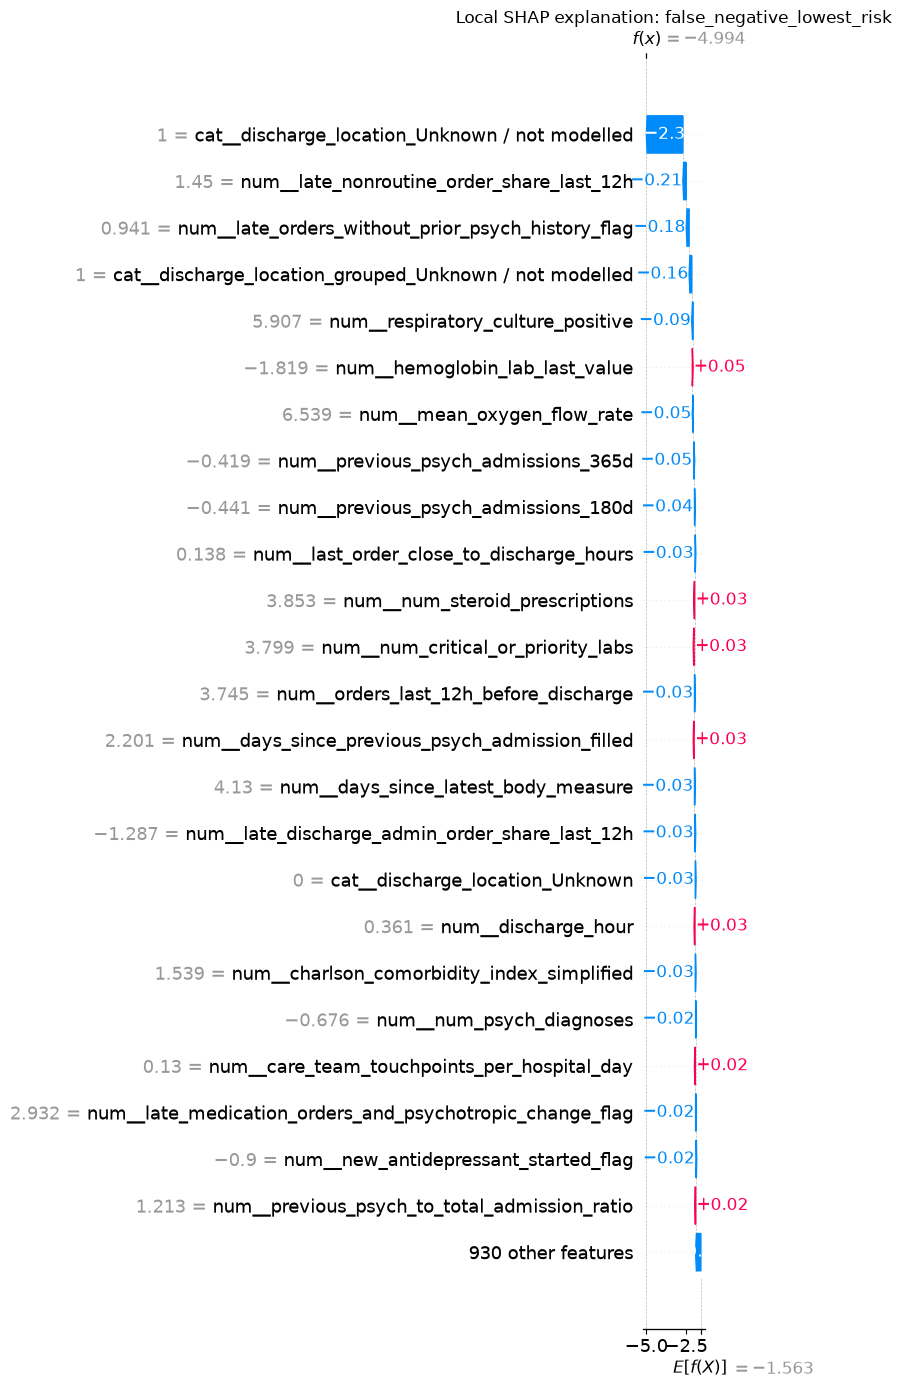

In [19]:
#plot local waterfall charts for selected admissions
for _, case_row in selected_local_cases_df.iterrows():
    shap_sample_position = shap_sample_index_df.index[shap_sample_index_df["test_row_index"] == case_row["test_row_index"]].tolist()[0]
    case_label = case_row["local_case_label"]
    explanation = shap.Explanation(values=shap_values[shap_sample_position],
        base_values=base_value,
        data=X_shap_plot[shap_sample_position],
        feature_names=processed_feature_names)
    plt.figure(figsize=(9, 7))
    shap.plots.waterfall(explanation, max_display=25, show=False)
    plt.title(f"Local SHAP explanation: {case_label}")
    plt.tight_layout()
    plt.savefig(wp4_image_output_path / f"t4_shap_waterfall_{case_label}.png", dpi=300, bbox_inches="tight")
    plt.show()

**4.4.1 - Force Plot Case Examples**

These examples show individual-level explanations for one high-risk admission and one low-risk admission. Force plots are included because they are familiar dissertation-style visuals, but compact bar plots are also exported because they are usually easier to read.





<Figure size 2400x480 with 0 Axes>

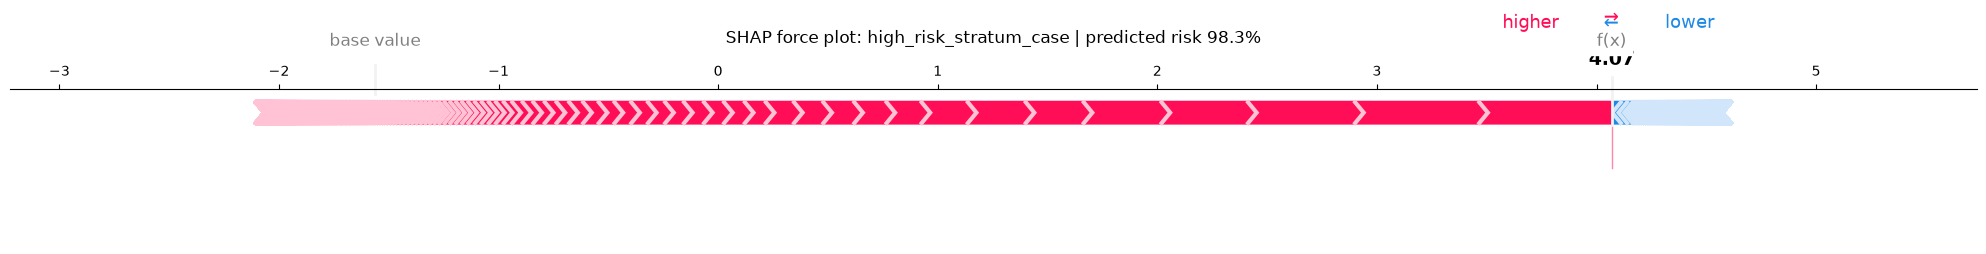

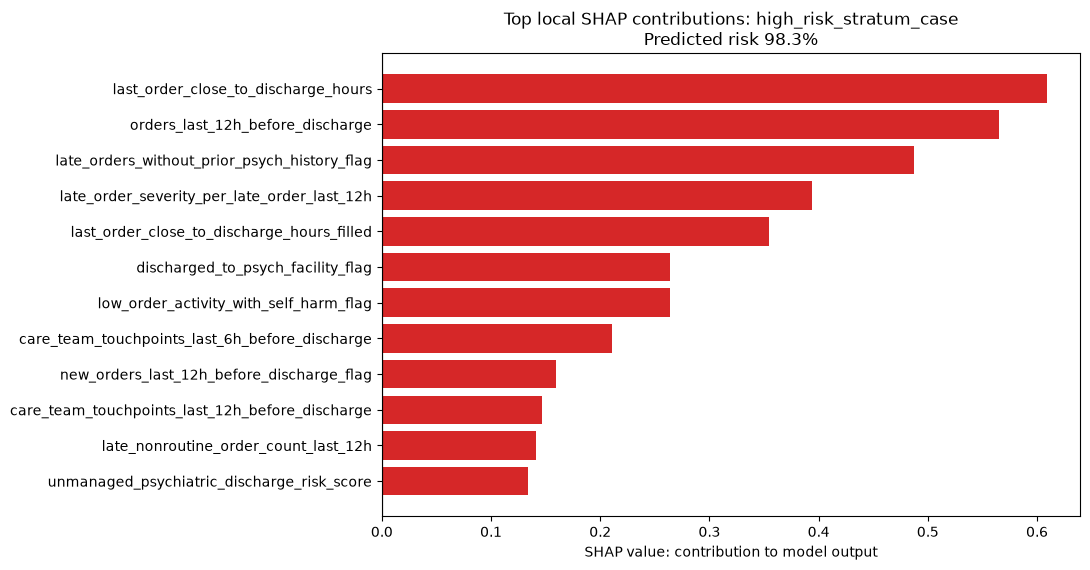

<Figure size 2400x480 with 0 Axes>

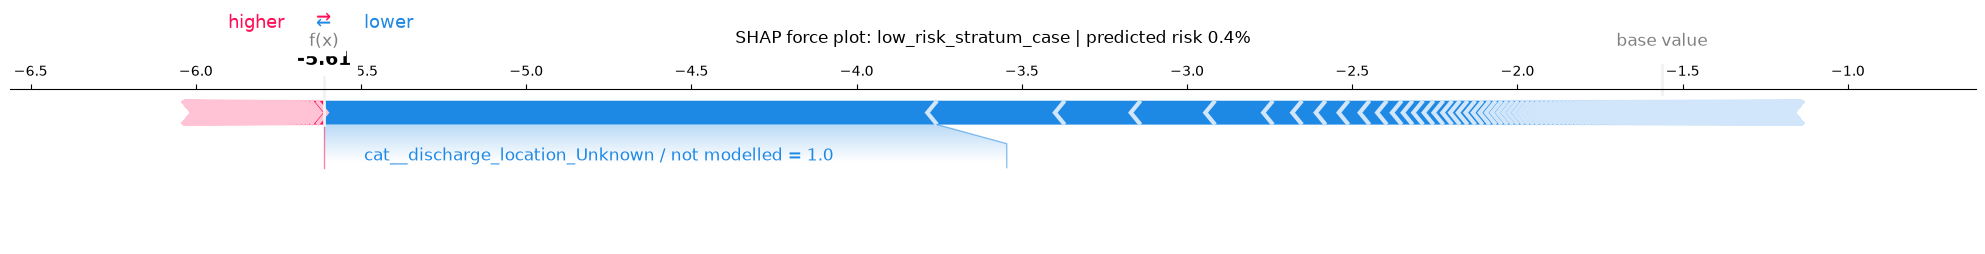

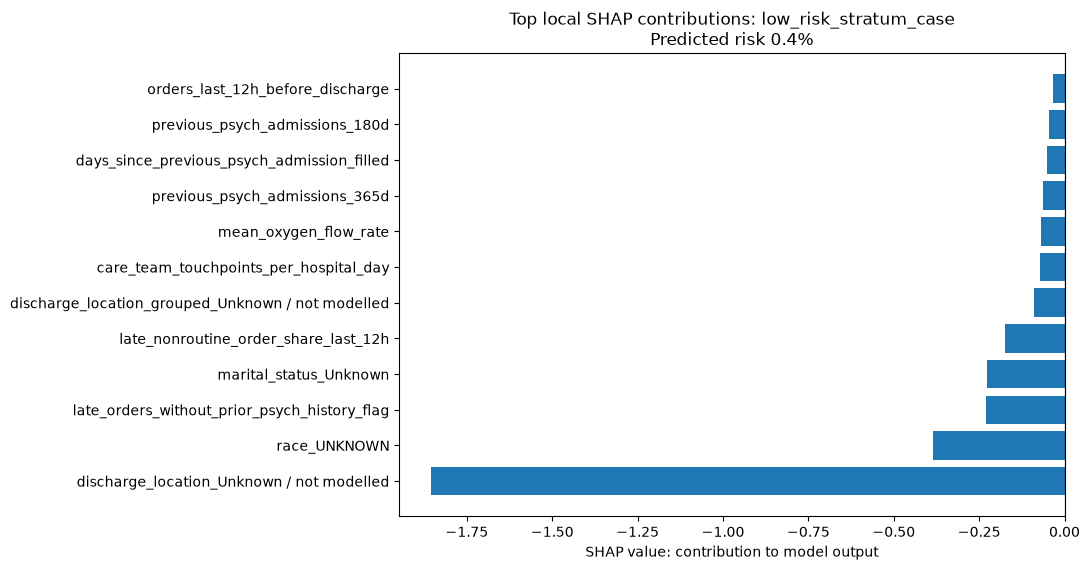

Force plot cases:


,local_case_label,subject_id,hadm_id,readmitted_30d,predicted_probability,classification_group,force_plot_file,local_bar_plot_file
0,high_risk_stratum_case,18122969,21943419,1,0.983200,true_positive,/scratch/DissProject/outputs/WP4/images/t4_sha...,/scratch/DissProject/outputs/WP4/images/t4_sha...
1,low_risk_stratum_case,19059584,22602619,0,0.003641,true_negative,/scratch/DissProject/outputs/WP4/images/t4_sha...,/scratch/DissProject/outputs/WP4/images/t4_sha...


Top local force/bar features:


,local_case_label,processed_feature_name,feature_value,shap_value,absolute_shap_value,feature_name_clean,predicted_probability
0,high_risk_stratum_case,num__unmanaged_psychiatric_discharge_risk_score,0.3585,0.1336,0.1336,unmanaged_psychiatric_discharge_risk_score,0.9832
1,high_risk_stratum_case,num__late_nonroutine_order_count_last_12h,-0.9462,0.1408,0.1408,late_nonroutine_order_count_last_12h,0.9832
2,high_risk_stratum_case,num__care_team_touchpoints_last_12h_before_dis...,-1.5029,0.1470,0.1470,care_team_touchpoints_last_12h_before_discharge,0.9832
3,high_risk_stratum_case,num__new_orders_last_12h_before_discharge_flag,-3.2520,0.1597,0.1597,new_orders_last_12h_before_discharge_flag,0.9832
4,high_risk_stratum_case,num__care_team_touchpoints_last_6h_before_disc...,-1.3651,0.2105,0.2105,care_team_touchpoints_last_6h_before_discharge,0.9832
5,high_risk_stratum_case,num__low_order_activity_with_self_harm_flag,6.9753,0.2637,0.2637,low_order_activity_with_self_harm_flag,0.9832
6,high_risk_stratum_case,num__discharged_to_psych_facility_flag,8.9442,0.2640,0.2640,discharged_to_psych_facility_flag,0.9832
7,high_risk_stratum_case,num__last_order_close_to_discharge_hours_filled,2.5197,0.3546,0.3546,last_order_close_to_discharge_hours_filled,0.9832
12,low_risk_stratum_case,cat__discharge_location_Unknown / not modelled,1.0000,-1.8554,1.8554,discharge_location_Unknown / not modelled,0.0036
13,low_risk_stratum_case,cat__race_UNKNOWN,1.0000,-0.3863,0.3863,race_UNKNOWN,0.0036


In [ ]:
#create compact shap force plots and clearer local contribution bar plots
force_plot_cases_df = selected_local_cases_df.loc[
    selected_local_cases_df["local_case_label"].isin(["high_risk_stratum_case", "low_risk_stratum_case"])].copy()

force_plot_summary_rows = []
force_bar_top_feature_rows = []

#define shorten shap feature name
def shorten_shap_feature_name(feature_name, max_length=58):
    """Keep local plots readable by removing pipeline prefixes and truncating very long names."""
    clean_name = str(feature_name).replace("num__", "").replace("cat__", "")
    if len(clean_name) > max_length:
        return clean_name[:max_length - 3] + "..."
    return clean_name
if force_plot_cases_df.empty:
    print("Force plots skipped because high/low risk local cases were not selected.")
else:
    #loop through each item in this feature block
    for _, case_row in force_plot_cases_df.iterrows():
        matching_positions = shap_sample_index_df.index[
            shap_sample_index_df["test_row_index"] == case_row["test_row_index"]].tolist()

        if not matching_positions:
            print("Skipping", case_row["local_case_label"], "because it was not present in the SHAP sample.")
            continue

        shap_sample_position = matching_positions[0]
        case_label = case_row["local_case_label"]
        predicted_probability = float(case_row.get("predicted_probability", np.nan))

        #the force plot is useful conceptually, but the label threshold is deliberately conservative
        #so the exported figure does not become a crowded strip of tiny feature names.
        force_output_path = wp4_image_output_path / f"t4_shap_force_{case_label}.png"
        plt.figure(figsize=(24, 4.8))
        shap.force_plot(base_value, shap_values[shap_sample_position], X_shap_plot[shap_sample_position],
            feature_names=processed_feature_names, matplotlib=True, show=False, contribution_threshold=0.18)
        plt.title(f"SHAP force plot: {case_label} | predicted risk {predicted_probability:.1%}", pad=16)
        plt.tight_layout(pad=1.2)
        plt.savefig(force_output_path, dpi=260, bbox_inches="tight")
        plt.show()
        plt.close()

        #the companion bar plot is the cleaner figure for explaining exactly which variables
        #pushed this patient upward or downward relative to the model baseline.
        local_case_contributions_df = pd.DataFrame({
            "processed_feature_name": processed_feature_names,
            "feature_value": np.asarray(X_shap_plot[shap_sample_position]).ravel(),
            "shap_value": np.asarray(shap_values[shap_sample_position]).ravel()})
        local_case_contributions_df["absolute_shap_value"] = local_case_contributions_df["shap_value"].abs()
        local_case_contributions_df["feature_name_clean"] = local_case_contributions_df["processed_feature_name"].map(
            shorten_shap_feature_name)
        local_case_contributions_df = local_case_contributions_df.sort_values(
            "absolute_shap_value", ascending=False).head(12).sort_values("shap_value")
        local_case_contributions_df.insert(0, "local_case_label", case_label)
        local_case_contributions_df["predicted_probability"] = predicted_probability
        force_bar_top_feature_rows.append(local_case_contributions_df)

        bar_output_path = wp4_image_output_path / f"t4_shap_local_bar_{case_label}.png"
        bar_colours = np.where(local_case_contributions_df["shap_value"] >= 0, "#d62728", "#1f77b4")
        plt.figure(figsize=(11, max(5.8, 0.42 * len(local_case_contributions_df))))
        plt.barh(local_case_contributions_df["feature_name_clean"],
            local_case_contributions_df["shap_value"], color=bar_colours)
        plt.axvline(0, color="black", linewidth=0.8)
        plt.xlabel("SHAP value: contribution to model output")
        plt.title(f"Top local SHAP contributions: {case_label}\nPredicted risk {predicted_probability:.1%}")
        plt.tight_layout()
        plt.savefig(bar_output_path, dpi=260, bbox_inches="tight")
        plt.show()
        plt.close()

        force_plot_summary_rows.append({"local_case_label": case_label,
            "subject_id": case_row.get("subject_id"),
            "hadm_id": case_row.get("hadm_id"),
            "readmitted_30d": case_row.get("readmitted_30d"),
            "predicted_probability": predicted_probability,
            "classification_group": case_row.get("classification_group"),
            "force_plot_file": str(force_output_path),
            "local_bar_plot_file": str(bar_output_path)})

force_plot_summary_df = pd.DataFrame(force_plot_summary_rows)
if force_bar_top_feature_rows:
    force_bar_top_features_df = pd.concat(force_bar_top_feature_rows, ignore_index=True)
else:
    force_bar_top_features_df = pd.DataFrame()

#save this table or artefact for later review
force_plot_summary_df.to_csv(wp4_csv_output_path / "t4_shap_force_plot_case_summary.csv", index=False)
force_bar_top_features_df.to_csv(wp4_csv_output_path / "t4_shap_force_plot_bar_top_features.csv", index=False)
print("Force plot cases:")
display(force_plot_summary_df)
print("Top local force/bar features:")
#summarise row-level records to admission-level features
display(force_bar_top_features_df.groupby("local_case_label").head(8).round(4))

**4.4.2 - Outcome-Window Labels for Explained Cases**

This table keeps the 30-day model fixed and reports whether each locally explained admission became positive in the 14-, 60-, 90-, or 365-day psychiatric readmission windows. It helps interpret cases that are labelled negative at 30 days but may still be clinically close to the target outcome.





In [21]:
#attach wider psychiatric readmission-window labels to selected local explanation cases when available
#selected_local_cases_df may already contain these columns, so only merge columns that are missing
local_case_window_summary_df = selected_local_cases_df.copy()
requested_window_columns = ["readmitted_14d_psych", "readmitted_60d_psych", "readmitted_90d_psych",
    "readmitted_365d_psych", "days_to_next"]
available_window_columns = [col for col in requested_window_columns if col in explanation_index_df.columns]
missing_window_columns = [col for col in available_window_columns if col not in local_case_window_summary_df.columns]

if missing_window_columns:
    local_case_window_summary_df = local_case_window_summary_df.merge(
        explanation_index_df[["test_row_index"] + missing_window_columns].drop_duplicates("test_row_index"),
        on="test_row_index", how="left")

window_display_columns = [col for col in requested_window_columns if col in local_case_window_summary_df.columns]
if window_display_columns:
    local_case_window_summary_df.to_csv(wp4_csv_output_path / "t4_shap_local_case_outcome_windows.csv", index=False)
    print("Selected local cases with wider outcome-window labels:")
    display_columns = ["local_case_label", "subject_id", "hadm_id", "readmitted_30d",
        "predicted_probability", "classification_group"] + window_display_columns
    display(local_case_window_summary_df[display_columns])
else:
    print("No wider outcome-window columns were available in the prediction file.")

Selected local cases with wider outcome-window labels:


,local_case_label,subject_id,hadm_id,readmitted_30d,predicted_probability,classification_group,readmitted_14d_psych,readmitted_60d_psych,readmitted_90d_psych,readmitted_365d_psych,days_to_next
0,high_risk_stratum_case,18122969,21943419,1,0.983200,true_positive,1,1,1,1,0.0
1,low_risk_stratum_case,19059584,22602619,0,0.003641,true_negative,0,0,0,0,NaN
2,false_positive_highest_risk,17483772,20538623,0,0.957430,false_positive,0,0,0,0,NaN
3,false_negative_lowest_risk,14897280,21852536,1,0.006732,false_negative,1,1,1,1,0.0


**4.5 - Paired SHAP Comparison for the Two Strongest Models**

This section repeats the core SHAP explanation workflow for Targeted LightGBM and Targeted XGBoost. The aim is not to refit either model, but to check whether the two strongest models are using similar clinical signals. LightGBM remains the primary explanation target when it is the best model in WP3.6, while XGBoost is used as a stability comparison.



Running paired SHAP workflow for Targeted LightGBM...


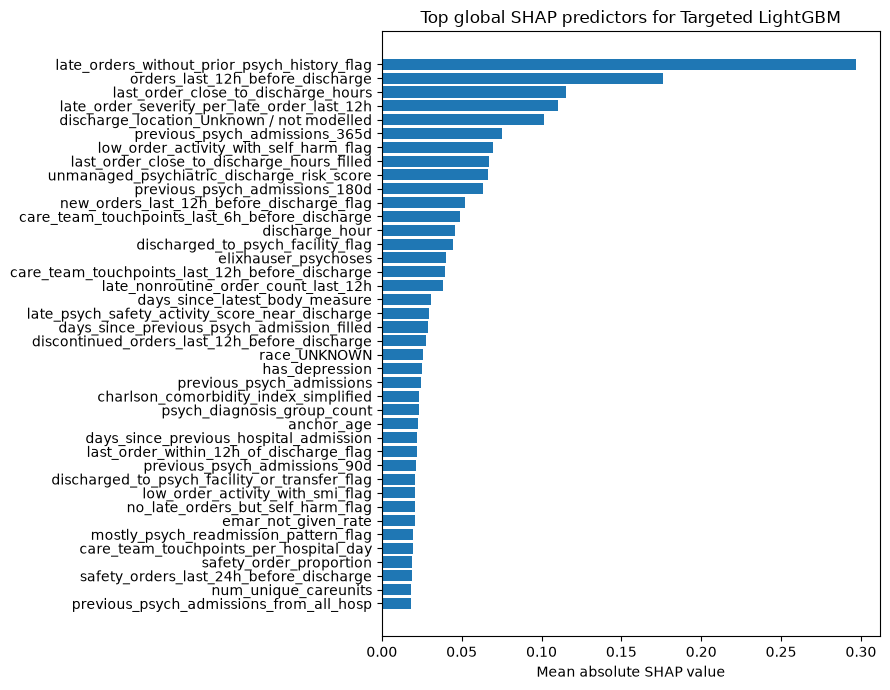

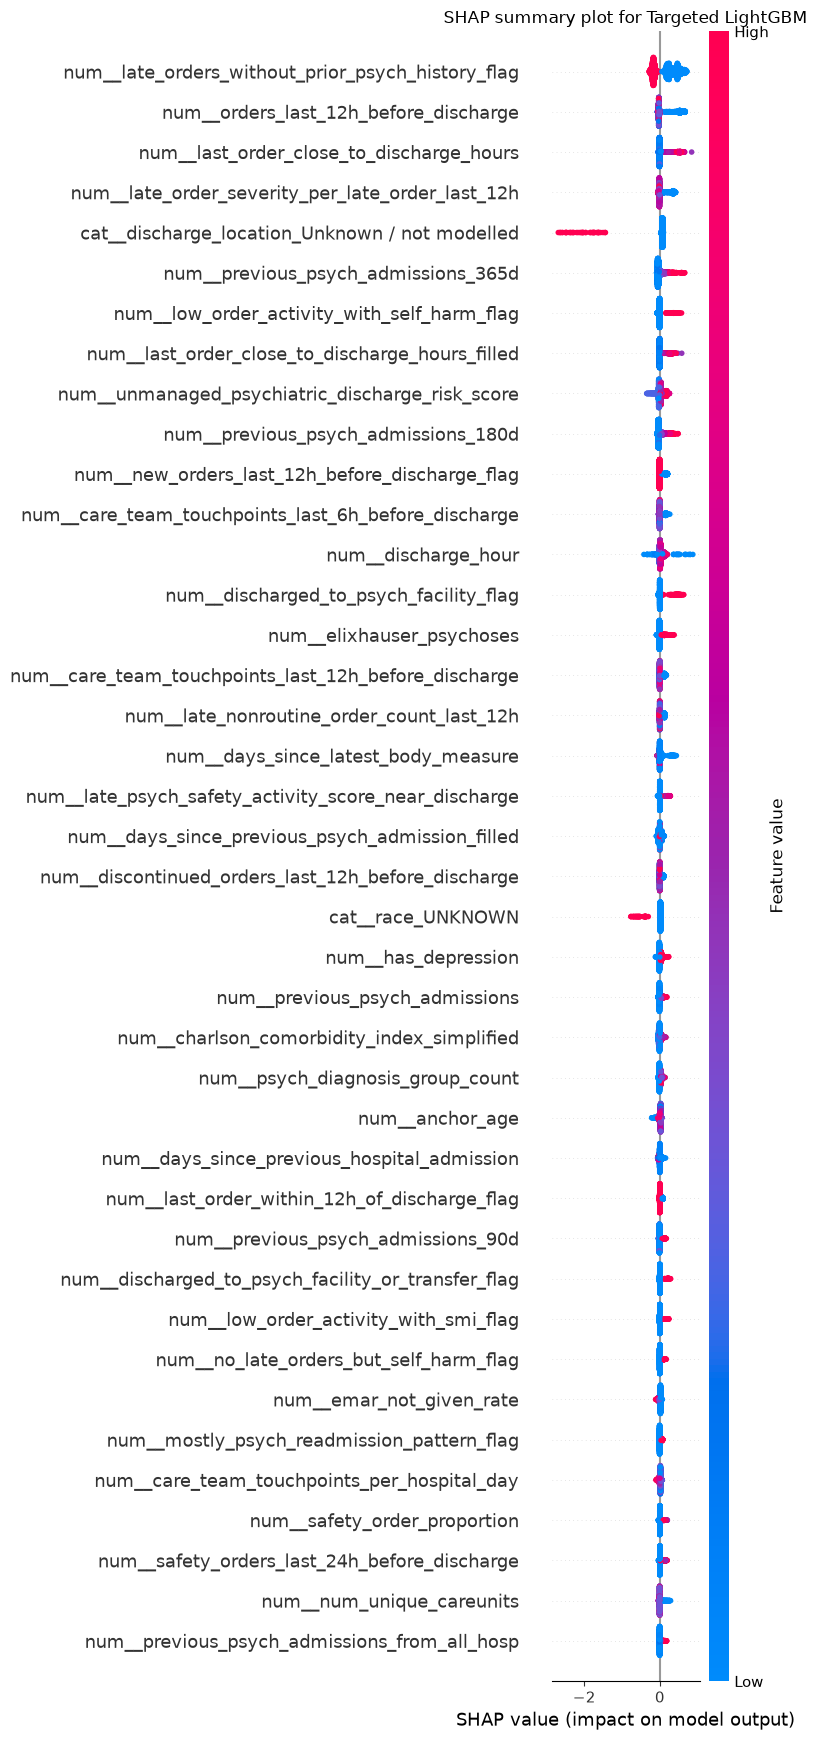

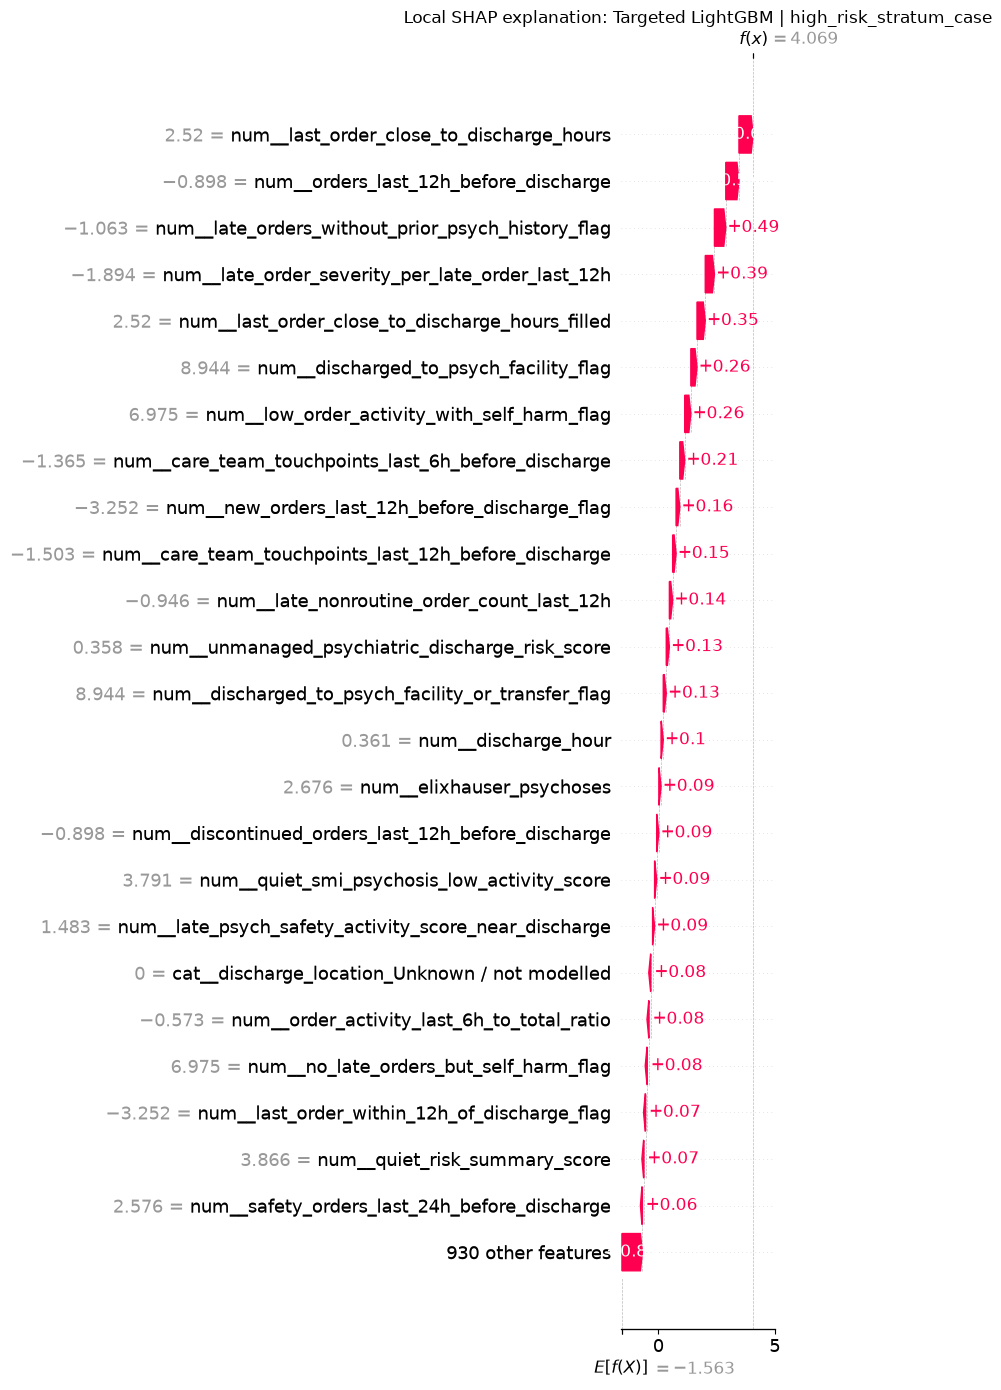

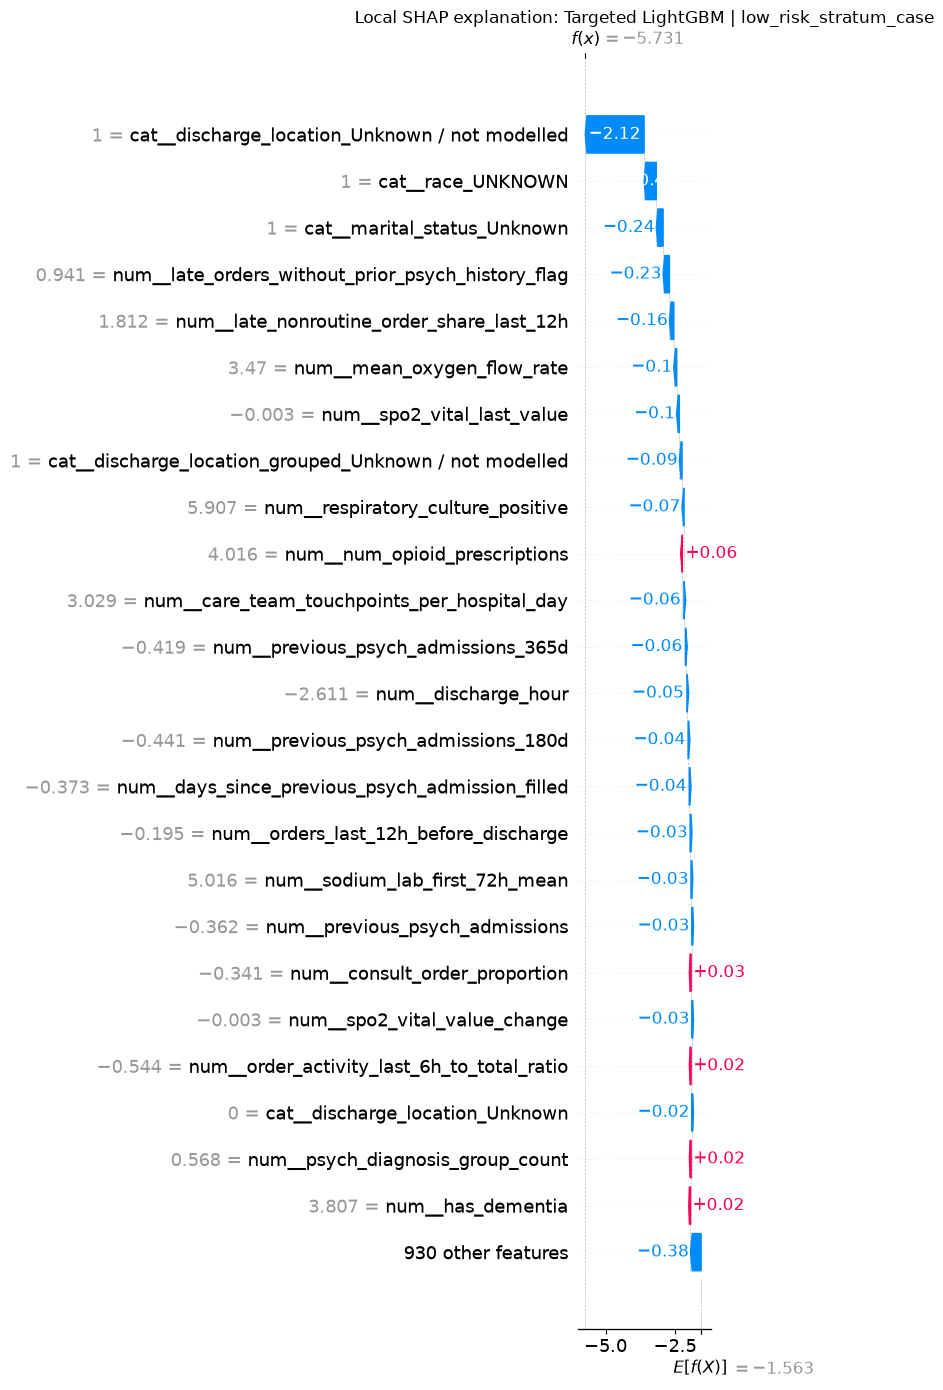

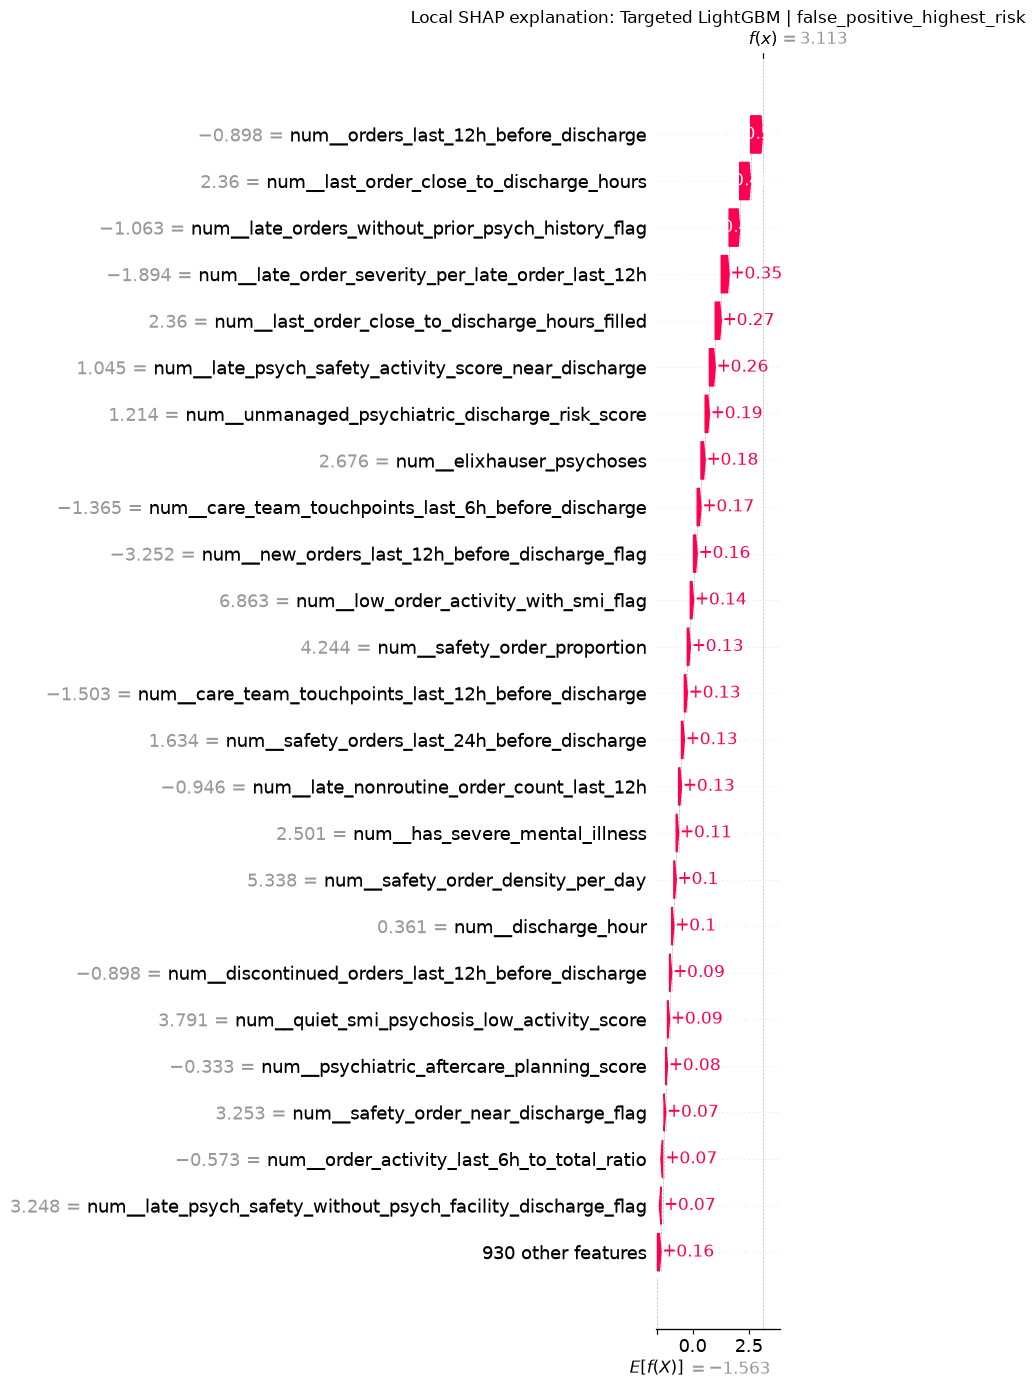

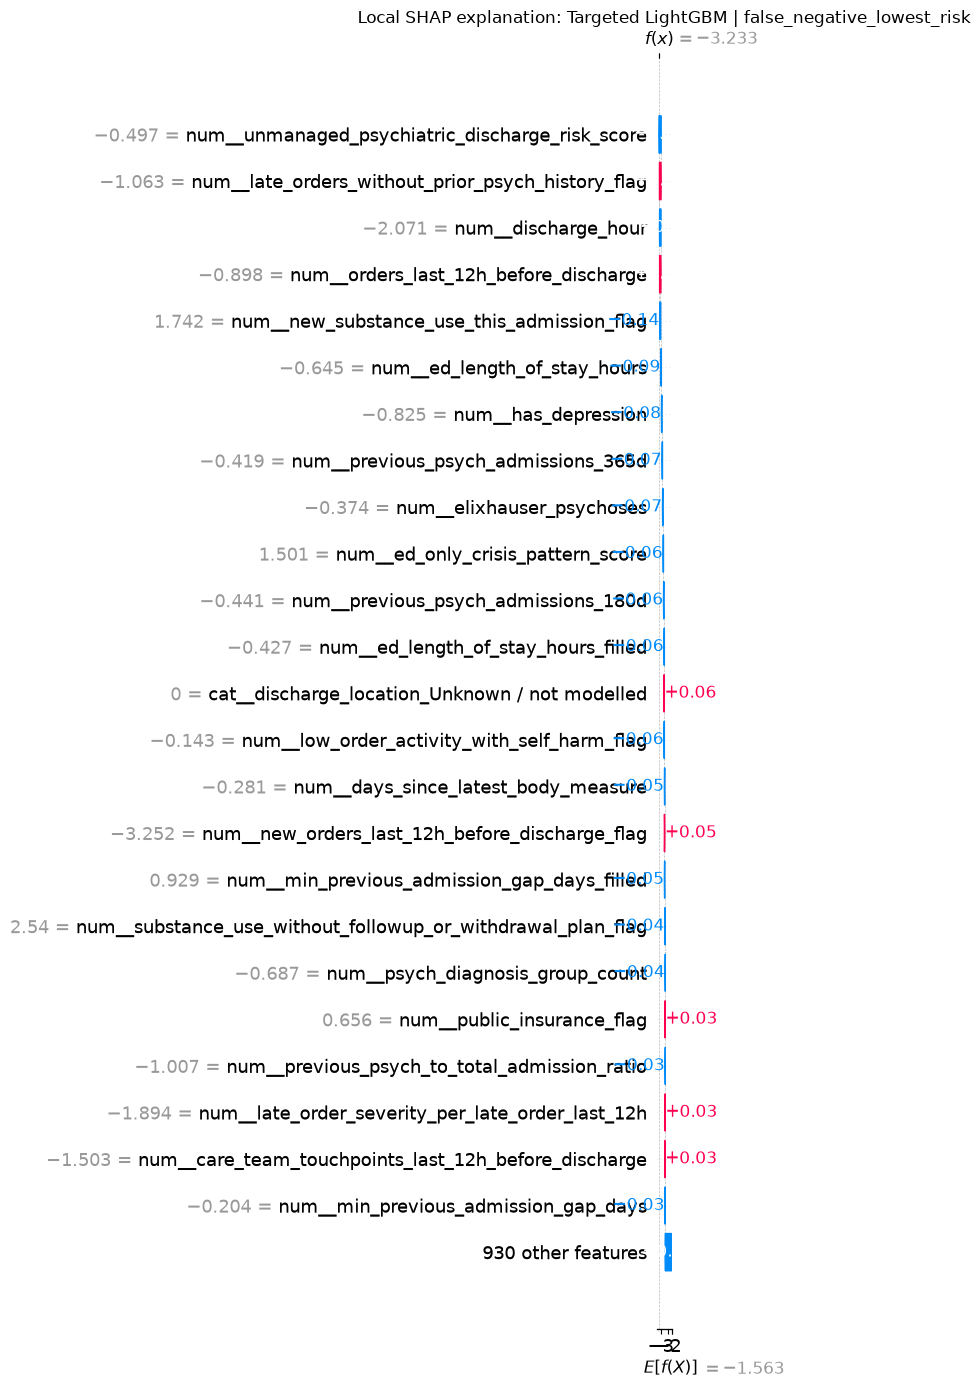


Running paired SHAP workflow for Targeted XGBoost...


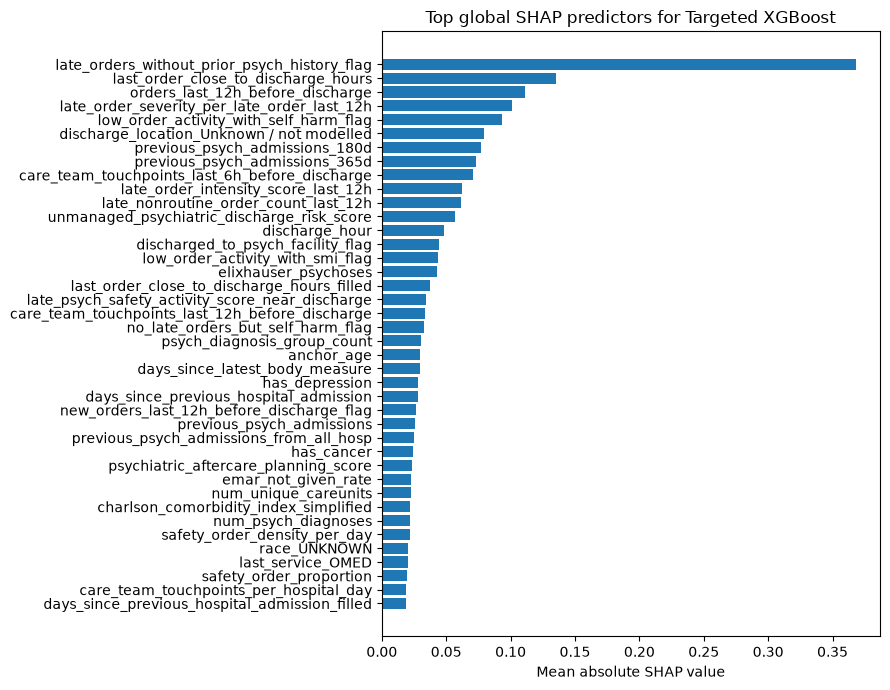

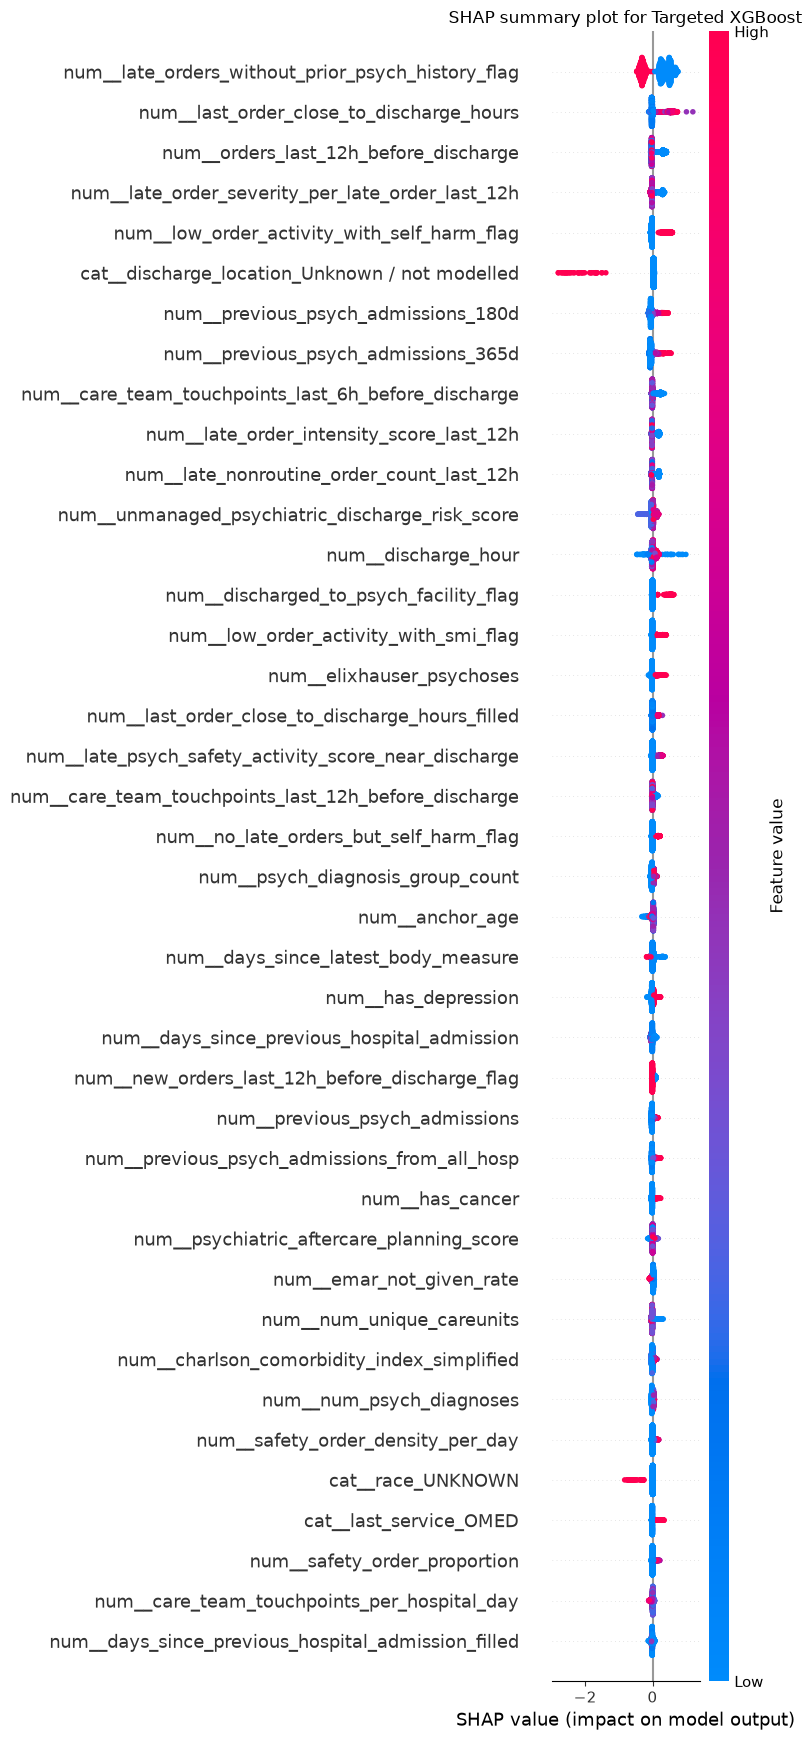

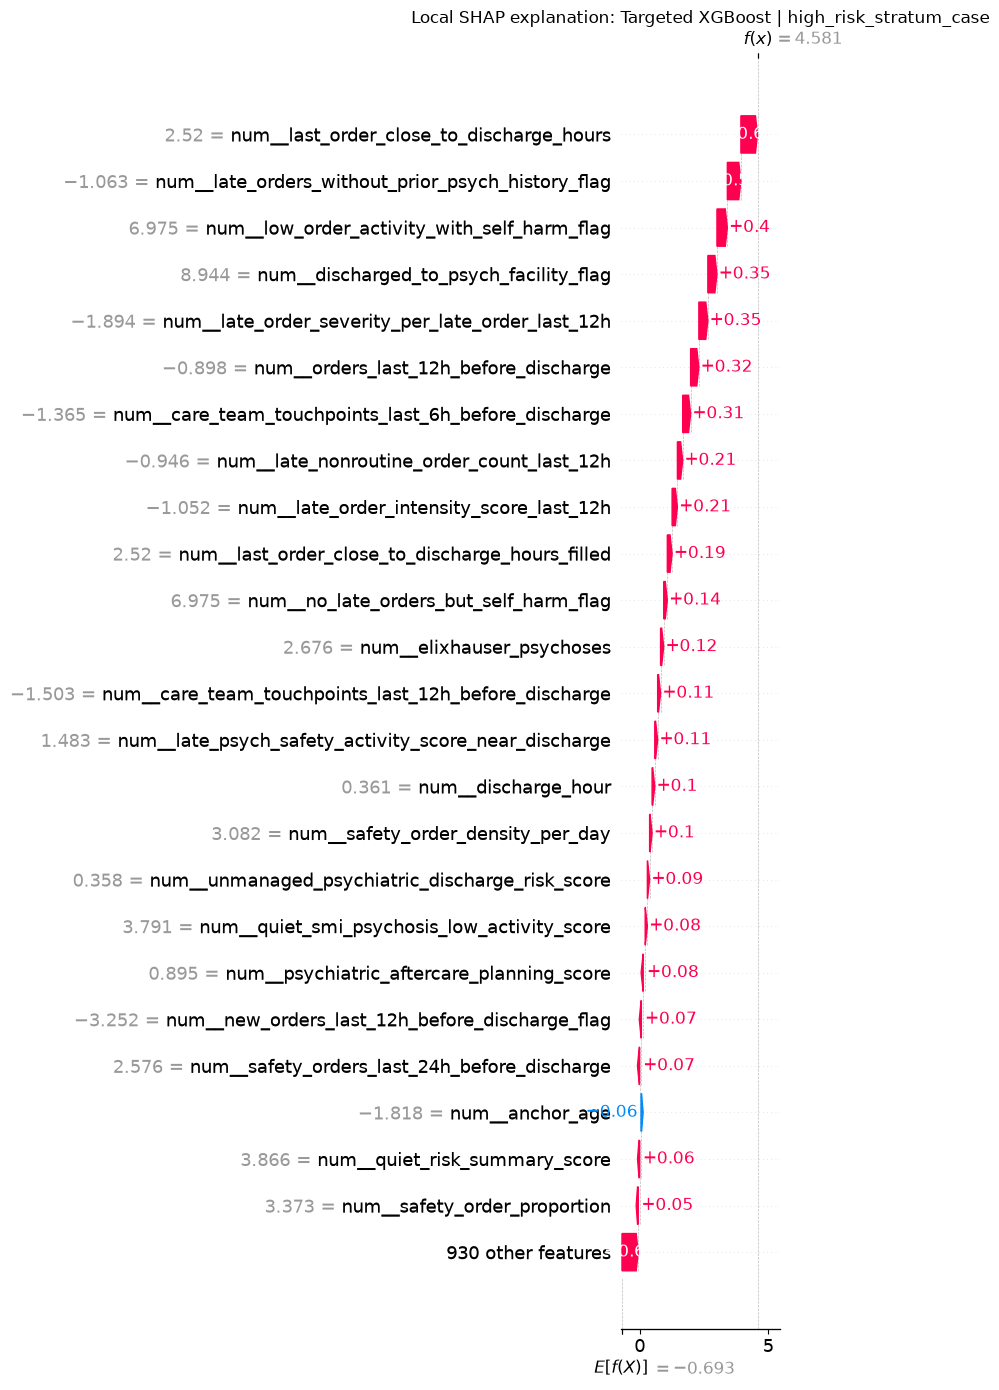

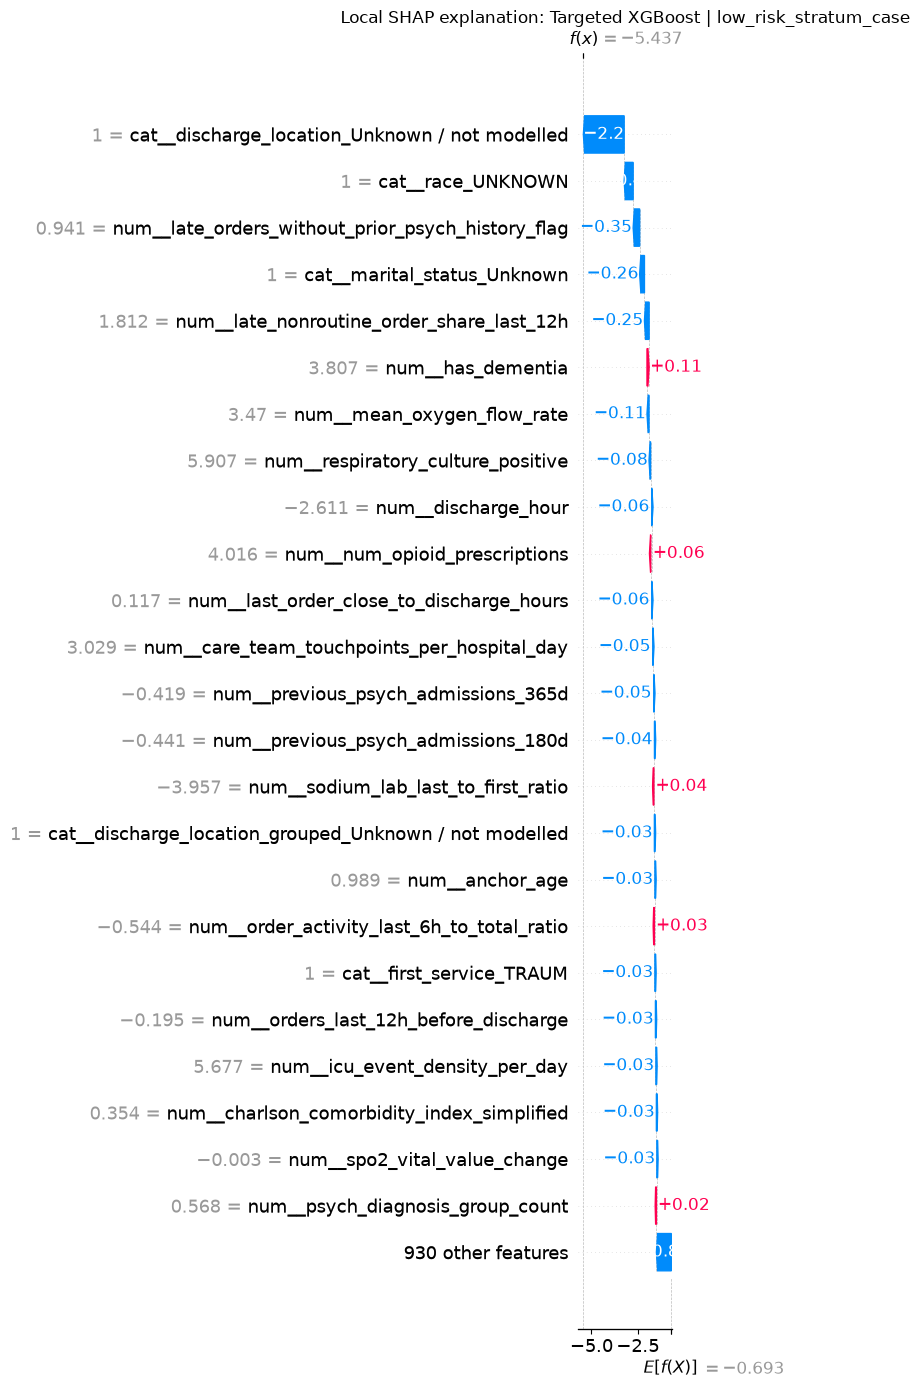

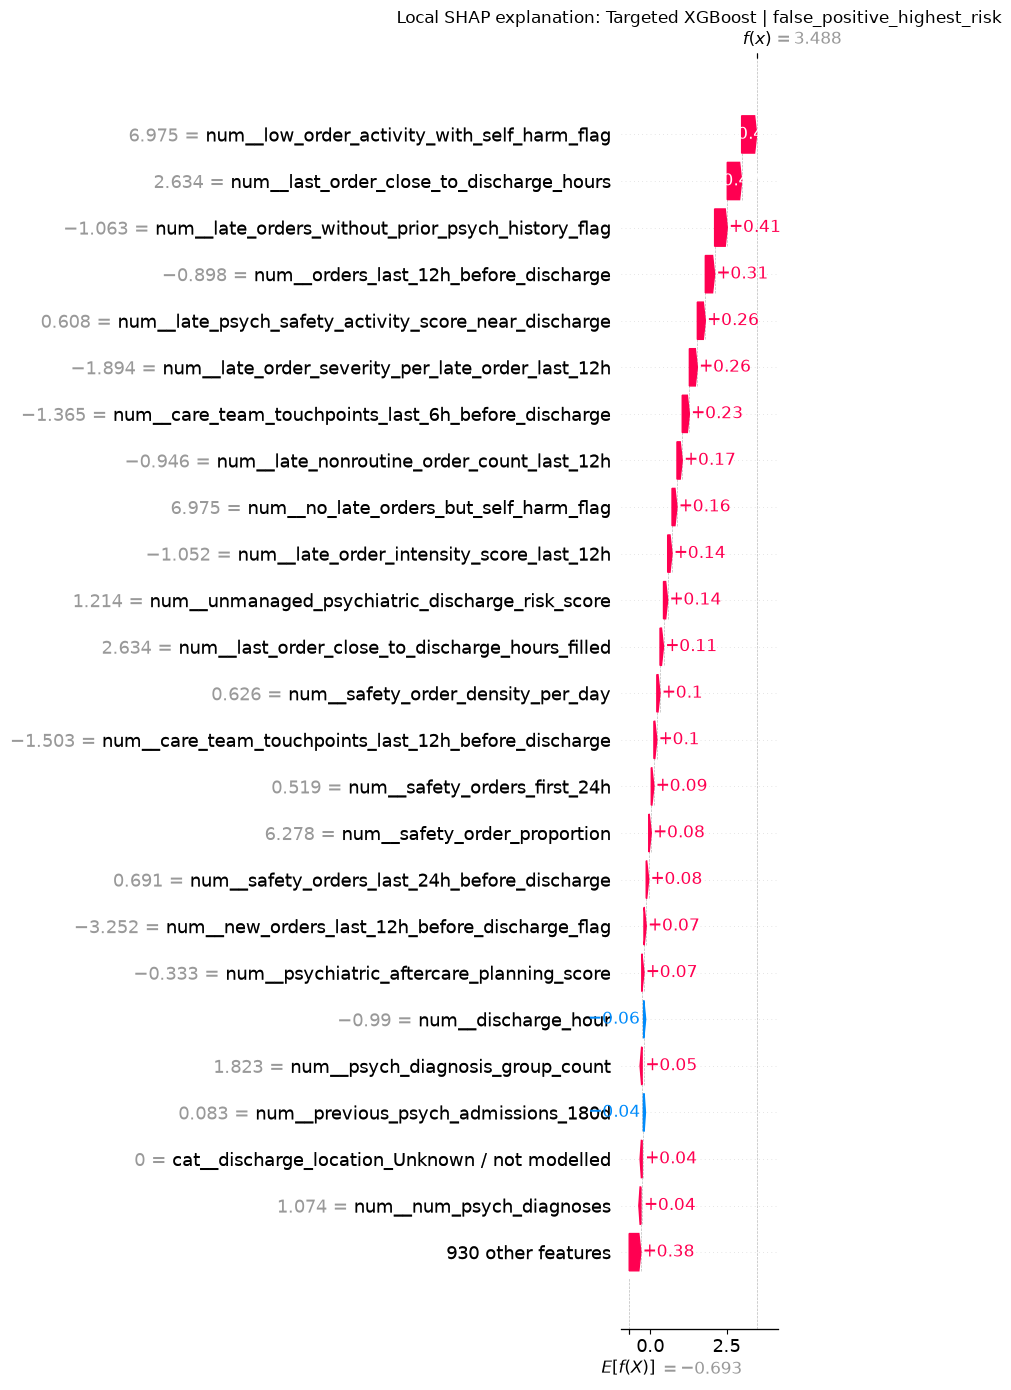

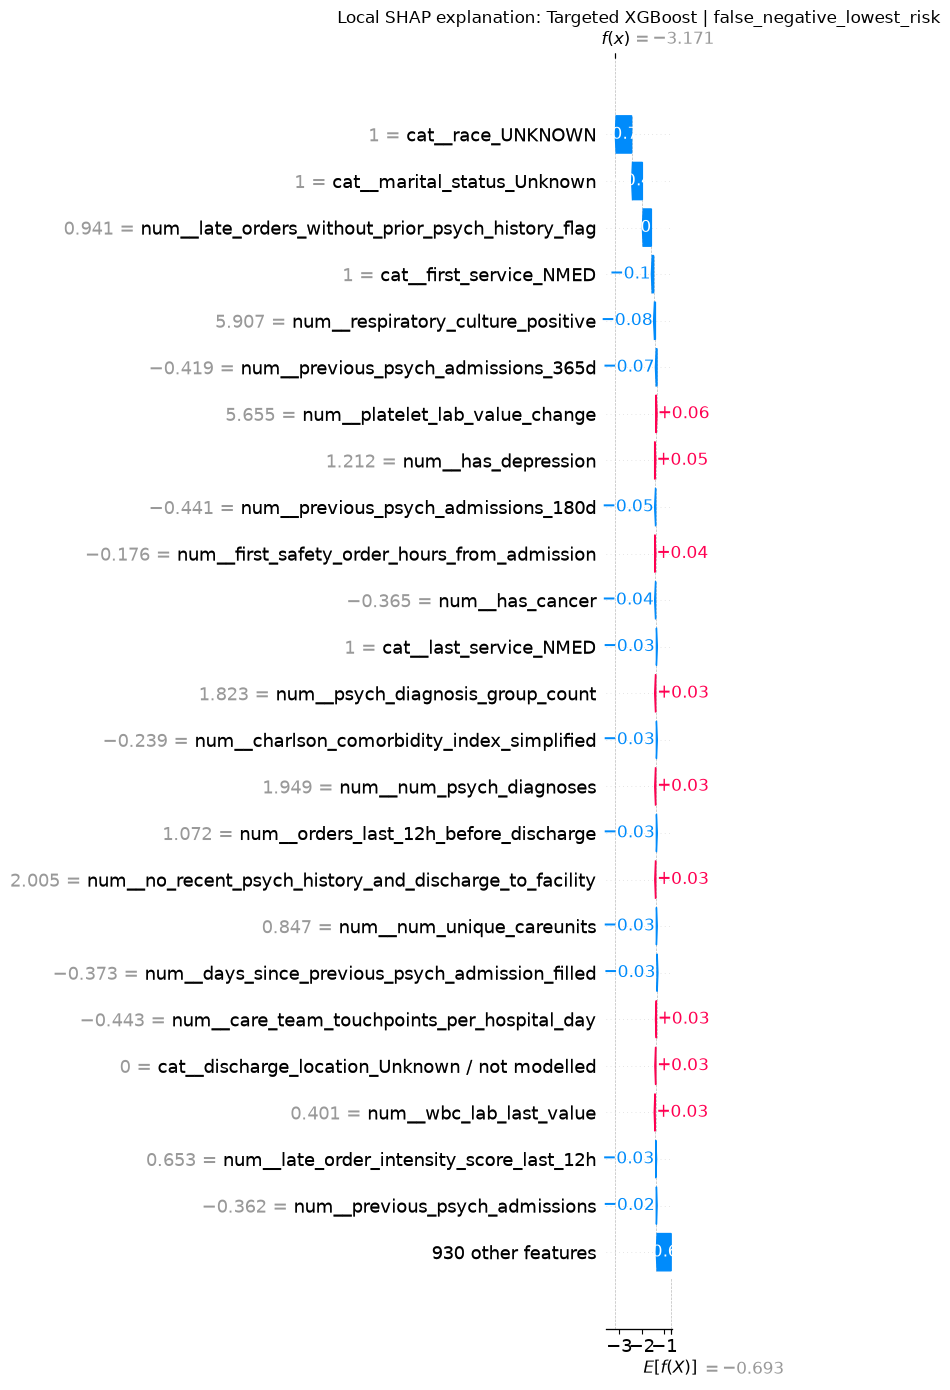

Paired SHAP workflow complete.
Paired SHAP workbook:
/scratch/DissProject/outputs/WP4/t4_shap_paired_model_explanation_tables.xlsx
Paired SHAP methodology summary:


,model_family,model_slug,model_path,prediction_path,matrix_source,test_matrix_path,processed_feature_names_path,test_rows,processed_features,model_expected_features,shap_sample_rows,shap_sample_positive_rows,selected_threshold,shap_expected_value_log_odds,shap_expected_value_probability,shap_elapsed_seconds,global_bar_plot_file,beeswarm_plot_file
0,Targeted LightGBM,targeted_lightgbm,/scratch/DissProject/outputs/WP3_4/lightgbm_ta...,/scratch/DissProject/outputs/WP3_4/lightgbm_ta...,shap_guided_reduced_feature_set,/scratch/DissProject/outputs/WP3_1/t3_1_X_test...,/scratch/DissProject/outputs/WP3_1/t3_1_proces...,47171,954,954,2200,1294,0.32,-1.562953,0.173223,21.586957,/scratch/DissProject/outputs/WP4/images/target...,/scratch/DissProject/outputs/WP4/images/target...
1,Targeted XGBoost,targeted_xgboost,/scratch/DissProject/outputs/WP3_4/xgboost_tar...,/scratch/DissProject/outputs/WP3_4/xgboost_tar...,shap_guided_reduced_feature_set,/scratch/DissProject/outputs/WP3_1/t3_1_X_test...,/scratch/DissProject/outputs/WP3_1/t3_1_proces...,47171,954,954,2200,1290,0.43,-0.692733,0.333425,0.902083,/scratch/DissProject/outputs/WP4/images/target...,/scratch/DissProject/outputs/WP4/images/target...


Top feature-family importance by model:


,model_family,model_slug,feature_family,processed_feature_count,total_mean_abs_shap,mean_abs_shap,max_mean_abs_shap,family_importance_rank
0,Targeted LightGBM,targeted_lightgbm,poe_order_pathway,176,1.389692,0.007896,0.297085,1
1,Targeted LightGBM,targeted_lightgbm,psychiatric_history,117,0.493879,0.004221,0.066302,2
2,Targeted LightGBM,targeted_lightgbm,prior_utilisation,113,0.487455,0.004314,0.075502,3
3,Targeted LightGBM,targeted_lightgbm,discharge_social,75,0.325190,0.004336,0.101566,4
4,Targeted LightGBM,targeted_lightgbm,laboratory,140,0.301878,0.002156,0.013339,5
5,Targeted LightGBM,targeted_lightgbm,other,95,0.255079,0.002685,0.030713,6
6,Targeted LightGBM,targeted_lightgbm,medication_emar,70,0.165491,0.002364,0.020548,7
7,Targeted LightGBM,targeted_lightgbm,care_team_complexity,13,0.130320,0.010025,0.048942,8
13,Targeted XGBoost,targeted_xgboost,poe_order_pathway,176,1.398951,0.007949,0.368414,1
14,Targeted XGBoost,targeted_xgboost,prior_utilisation,113,0.494530,0.004376,0.077278,2


In [ ]:
#run a paired shap explanation workflow for targeted lightgbm and targeted xgboost
#each model writes to its own wp4 subfolder so outputs do not overwrite each other.
if not shap_available:
    raise ImportError("SHAP is not available in this environment. Install or enable SHAP before running WP4.")

paired_shap_random_state = 42
paired_max_shap_rows = 2200
paired_top_n_global = 40
paired_force_cases = ["high_risk_stratum_case", "low_risk_stratum_case"]

#these fallback family rules mirror the main global-explanation section, so this paired section can run independently.
if "assign_feature_family" not in globals():
    feature_family_rules = [
        ("poe_order_pathway", "poe|order_|orders_|first_order|last_order|order_activity|sitter|observation|suicide_precaution|elopement|restraint_order|psych_consult|social_work|discontinued_orders|unique_order"),
        ("care_team_complexity", "care_team|caregiver|provider|enter_provider|order_provider|provider_order_changes|touchpoints"),
        ("prior_utilisation", "previous_|recent_|days_since_previous|admission_ratio|frequent|high_utiliser"),
        ("psychiatric_history", "psych|depression|bipolar|substance|alcohol|opioid|stimulant|cannabis|tobacco|nicotine|sedative|polysubstance|severe_mental|self_harm|suicidal|psychoses"),
        ("medication_emar", "medication|drug|prescription|pharmacy|emar|antipsychotic|benzodiazepine|mood_stabiliser|mood_stabilizer|lai|iv_prescription|infusion|not_given|dose|prn|scheduled_pharmacy"),
        ("discharge_social", "discharge|insurance|language|marital|race|public_insurance|non_english|facility|home_flag|against_advice"),
        ("ed_pathway", "ed_length|ed_to_|emergency_room|ward_delay|transfer_from|internal_transfer|service_transfer|first_service|last_service|medicine_service|psych_service"),
        ("laboratory", "_lab_|sodium|potassium|creatinine|glucose|wbc|hemoglobin|platelet|urea|culture|microbiology|organism|infection"),
        ("vital_sign", "_vital_|heart_rate|spo2|respiratory|bp_|systolic|mean_bp"),
        ("procedure_comorbidity", "procedure|comorbidity|elixhauser|charlson|bmi|weight|height|obesity|underweight|dialysis|ventilation|ect|central_line|physical"),
        ("icu_care", "icu|careunit"),
        ("admission_context", "admission_type|admission_location|admission_hour|admission_day|admission_month|admission_year|los_days|los_|anchor_age|age_|gender")]

    #assign each processed feature to a broader clinical feature family
    def assign_feature_family(feature_name):
        #loop through each item in this feature block
        for family_name, pattern in feature_family_rules:
        
            if pd.Series([feature_name]).str.contains(pattern, case=False, regex=True).iloc[0]:
                return family_name
        return "other"

#get the number of features the saved model was trained with
def get_model_expected_feature_count(model):
    expected_features = getattr(model, "n_features_in_", None)
    if expected_features is None and hasattr(model, "get_booster"):
        expected_features = model.get_booster().num_features()
    return int(expected_features) if expected_features is not None else None

#load the test matrix whose feature count matches the saved model
def load_matching_test_matrix(model_expected_features):
    candidate_matrix_suffixes = [wp3_input_variant, "clean_feature_audit", "runtime_trimmed_feature_audit", None]
    #loop through each item in this feature block
    for matrix_suffix in candidate_matrix_suffixes:
    
        if matrix_suffix is None:
            candidate_X_test_path = wp3_1_output_path / "t3_1_X_test_processed.npz"
            candidate_feature_names_path = wp3_1_output_path / "t3_1_processed_feature_names.csv"
            candidate_label = "full_processed_matrix"
        else:
            candidate_X_test_path = wp3_1_output_path / f"t3_1_X_test_processed_{matrix_suffix}.npz"
            candidate_feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{matrix_suffix}.csv"
            candidate_label = matrix_suffix
        if not candidate_X_test_path.exists() or not candidate_feature_names_path.exists():
            continue
        candidate_feature_names_df = pd.read_csv(candidate_feature_names_path, usecols=["processed_feature_name"])
        if model_expected_features is None or len(candidate_feature_names_df) == model_expected_features:
            return sparse.load_npz(candidate_X_test_path), candidate_feature_names_df["processed_feature_name"].tolist(), candidate_label, candidate_X_test_path, candidate_feature_names_path
    raise ValueError(f"No WP3.1 processed matrix matches model feature count {model_expected_features}.")

#find the predicted probability column in a saved prediction table
def get_probability_column(prediction_df):
    probability_candidates = ["predicted_probability", "probability", "prediction_probability", "readmission_probability"]
    for column_name in probability_candidates:
        if column_name in prediction_df.columns:
            return column_name
    numeric_columns = prediction_df.select_dtypes(include=[np.number]).columns.tolist()
    likely_probability_columns = [col for col in numeric_columns if "prob" in col.lower() or "risk" in col.lower()]
    if likely_probability_columns:
        return likely_probability_columns[0]
    raise ValueError("Could not identify a predicted-probability column in the prediction file.")

#build an admission-level index for linking predictions, outcomes, and shap rows
def build_explanation_index(prediction_df, model, X_matrix, y_vector):
    probability_column = get_probability_column(prediction_df)
    id_columns = [col for col in ["subject_id", "hadm_id", "stay_id"] if col in prediction_df.columns]
    if id_columns:
        index_df = prediction_df[id_columns].copy()
    else:
        index_df = test_ids[[col for col in ["subject_id", "hadm_id", "stay_id"] if col in test_ids.columns]].copy()
    if "readmitted_30d" in prediction_df.columns:
        index_df["readmitted_30d"] = prediction_df["readmitted_30d"].astype(int)
    else:
        index_df["readmitted_30d"] = y_vector.values
    index_df["predicted_probability"] = prediction_df[probability_column].astype(float).values
    if len(index_df) != X_matrix.shape[0]:
        index_df = test_ids[[col for col in ["subject_id", "hadm_id", "stay_id"] if col in test_ids.columns]].copy()
        index_df["readmitted_30d"] = y_vector.values
        #score admissions as predicted readmission probabilities
        index_df["predicted_probability"] = model.predict_proba(X_matrix)[:, 1]
    for column_name in ["days_to_next", "readmitted_14d_psych", "readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"]:
        if column_name in prediction_df.columns and len(prediction_df) == len(index_df):
            index_df[column_name] = prediction_df[column_name].values
    if "days_to_next" in index_df.columns and "readmitted_14d_psych" not in index_df.columns:
        index_df["readmitted_14d_psych"] = index_df["days_to_next"].between(0, 14, inclusive="both").fillna(False).astype(int)
    index_df["test_row_index"] = np.arange(len(index_df))
    return index_df

#sample positives, negatives, and high-risk admissions for paired shap analysis
def make_shap_sample(index_df, X_matrix):
    rng = np.random.default_rng(paired_shap_random_state)
    positive_indices = index_df.loc[index_df["readmitted_30d"].eq(1), "test_row_index"].to_numpy()
    negative_indices = index_df.loc[index_df["readmitted_30d"].eq(0), "test_row_index"].to_numpy()
    high_risk_indices = index_df.sort_values("predicted_probability", ascending=False).head(500)["test_row_index"].to_numpy()
    positive_sample = rng.choice(positive_indices, size=min(800, len(positive_indices)), replace=False) if len(positive_indices) else np.array([], dtype=int)
    negative_sample = rng.choice(negative_indices, size=min(800, len(negative_indices)), replace=False) if len(negative_indices) else np.array([], dtype=int)
    selected = np.unique(np.concatenate([positive_sample, negative_sample, high_risk_indices])).astype(int)
    remaining_size = max(0, paired_max_shap_rows - len(selected))
    remaining_indices = np.setdiff1d(np.arange(X_matrix.shape[0]), selected)
    random_sample = rng.choice(remaining_indices, size=min(remaining_size, len(remaining_indices)), replace=False) if len(remaining_indices) else np.array([], dtype=int)
    sample_indices = np.unique(np.concatenate([selected, random_sample])).astype(int)[:paired_max_shap_rows]
    return sample_indices, X_matrix[sample_indices], index_df.iloc[sample_indices].copy().reset_index(drop=True)

#standardise shap outputs into one two-dimensional sample-by-feature matrix
def normalise_binary_shap_values(shap_values_raw, feature_names):
    #shap can return a list, an explanation object, a sparse matrix, or a 3d binary-class array depending on model/library versions.
    expected_feature_count = len(feature_names)

    #define unwrap shap object
    def unwrap_shap_object(values):
        if hasattr(values, "values"):
            values = values.values
        if sparse.issparse(values):
            values = values.toarray()
        values_array = np.asarray(values)
        if values_array.ndim == 0 and values_array.dtype == object:
            return unwrap_shap_object(values_array.item())
        return values_array

    if isinstance(shap_values_raw, (list, tuple)):
        shap_candidates = list(shap_values_raw)
        candidate_order = [1, 0] + list(range(2, len(shap_candidates))) if len(shap_candidates) > 1 else [0]
        last_error = None
        for candidate_index in candidate_order:
            if candidate_index >= len(shap_candidates):
                continue
            try:
                return normalise_binary_shap_values(shap_candidates[candidate_index], feature_names)
            except ValueError as error:
                last_error = error
        raise last_error if last_error is not None else ValueError("No usable SHAP array was returned.")

    shap_values_processed = unwrap_shap_object(shap_values_raw)

    if shap_values_processed.ndim == 3:
        if shap_values_processed.shape[-1] == 2 and shap_values_processed.shape[1] == expected_feature_count:
            shap_values_processed = shap_values_processed[:, :, 1]
        elif shap_values_processed.shape[0] == 2 and shap_values_processed.shape[2] == expected_feature_count:
            shap_values_processed = shap_values_processed[1, :, :]
        elif shap_values_processed.shape[1] == 2 and shap_values_processed.shape[2] == expected_feature_count:
            shap_values_processed = shap_values_processed[:, 1, :]
        else:
            raise ValueError(f"Unexpected 3D SHAP shape: {shap_values_processed.shape}")

    if shap_values_processed.ndim == 1 and shap_values_processed.shape[0] == expected_feature_count:
        shap_values_processed = shap_values_processed.reshape(1, -1)
    if shap_values_processed.ndim == 2 and shap_values_processed.shape[0] == expected_feature_count and shap_values_processed.shape[1] != expected_feature_count:
        shap_values_processed = shap_values_processed.T
    if shap_values_processed.ndim != 2:
        raise ValueError(f"Expected 2D SHAP values, got shape {shap_values_processed.shape}")
    if shap_values_processed.shape[1] != expected_feature_count:
        raise ValueError(f"SHAP feature count does not match processed feature names: {shap_values_processed.shape[1]} vs {expected_feature_count}")
    return shap_values_processed

#compute tree shap values and return the matching plot matrix
def compute_tree_shap(model, X_sample, feature_names):
    explainer = shap.TreeExplainer(model)
    try:
        shap_values_raw = explainer.shap_values(X_sample)
        display_matrix = X_sample
    except Exception as sparse_error:
        print("Sparse SHAP calculation failed, retrying with dense matrix:", sparse_error)
        display_matrix = X_sample.toarray() if sparse.issparse(X_sample) else X_sample
        shap_values_raw = explainer.shap_values(display_matrix)
    shap_values_processed = normalise_binary_shap_values(shap_values_raw, feature_names)
    base_value_local = explainer.expected_value
    if isinstance(base_value_local, (list, np.ndarray)):
        base_value_local = np.array(base_value_local).ravel()[-1]
    if sparse.issparse(display_matrix):
        plot_matrix = display_matrix.toarray()
    else:
        plot_matrix = np.asarray(display_matrix)
    return shap_values_processed, float(base_value_local), plot_matrix

#choose the threshold linked to the selected model outputs
def threshold_for_model(model_family, performance_path):
    fallback_threshold = 0.39
    recommended_path = wp3_6_output_path / "csv_tables" / "recommended_model_comparison.csv"
    if recommended_path.exists():
        recommended_df = pd.read_csv(recommended_path)
        model_rows = recommended_df.loc[recommended_df["model_family"].eq(model_family)]
        if not model_rows.empty and "threshold" in model_rows.columns and pd.notna(model_rows.iloc[0]["threshold"]):
            return float(model_rows.iloc[0]["threshold"])
    if performance_path.exists():
        performance_df = pd.read_csv(performance_path)
        if "threshold" in performance_df.columns:
            preferred_rows = performance_df.loc[performance_df.get("threshold_role", pd.Series(index=performance_df.index, dtype=object)).isin(["official", "training_f1", "selected"])]
            if not preferred_rows.empty:
                return float(preferred_rows.iloc[0]["threshold"])
            return float(performance_df.iloc[0]["threshold"])
    return fallback_threshold

#label each sampled admission as tp, fp, fn, or tn at the selected threshold
def create_error_group_index(sample_index_df, threshold):
    diagnostic_df = sample_index_df.copy()
    diagnostic_df["predicted_label"] = (diagnostic_df["predicted_probability"] >= threshold).astype(int)
    diagnostic_df["classification_group"] = np.select([
        (diagnostic_df["readmitted_30d"] == 1) & (diagnostic_df["predicted_label"] == 1),
        (diagnostic_df["readmitted_30d"] == 0) & (diagnostic_df["predicted_label"] == 1),
        (diagnostic_df["readmitted_30d"] == 1) & (diagnostic_df["predicted_label"] == 0),
        (diagnostic_df["readmitted_30d"] == 0) & (diagnostic_df["predicted_label"] == 0)],
        ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")
    return diagnostic_df

#build global, family-level, and error-group shap summary tables
def make_shap_summary_tables(model_family, model_slug, feature_names, shap_values_model, diagnostic_df):
    global_df = pd.DataFrame({
        "model_family": model_family,
        "model_slug": model_slug,
        "processed_feature_name": feature_names,
        "mean_abs_shap": np.abs(shap_values_model).mean(axis=0),
        "mean_signed_shap": shap_values_model.mean(axis=0),
        "std_shap": shap_values_model.std(axis=0)}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    global_df["importance_rank"] = np.arange(1, len(global_df) + 1)
    global_df["feature_name_clean"] = global_df["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
    global_df["feature_type"] = np.where(global_df["processed_feature_name"].str.startswith("cat__"), "categorical_encoded", "numeric_or_binary")
    global_df["feature_family"] = global_df["feature_name_clean"].apply(assign_feature_family)

    #summarise row-level records to admission-level features
    family_df = global_df.groupby(["model_family", "model_slug", "feature_family"], as_index=False).agg(
        processed_feature_count=("processed_feature_name", "size"),
        total_mean_abs_shap=("mean_abs_shap", "sum"),
        mean_abs_shap=("mean_abs_shap", "mean"),
        max_mean_abs_shap=("mean_abs_shap", "max"))
    family_df = family_df.sort_values(["model_family", "total_mean_abs_shap"], ascending=[True, False]).reset_index(drop=True)
    family_df["family_importance_rank"] = family_df.groupby("model_family")["total_mean_abs_shap"].rank(method="first", ascending=False).astype(int)

    top5_df = global_df.sort_values(["feature_family", "mean_abs_shap"], ascending=[True, False]).groupby("feature_family", as_index=False).head(5).copy()
    top5_df["feature_rank_within_family"] = top5_df.groupby("feature_family")["mean_abs_shap"].rank(method="first", ascending=False).astype(int)

    shap_long = pd.DataFrame(shap_values_model, columns=feature_names)
    shap_long.insert(0, "shap_sample_position", np.arange(shap_long.shape[0]))
    shap_long = shap_long.melt(id_vars="shap_sample_position", var_name="processed_feature_name", value_name="shap_value")
    #join the derived features back to the admission table
    shap_long = shap_long.merge(global_df[["processed_feature_name", "feature_name_clean", "feature_family", "mean_abs_shap"]], on="processed_feature_name", how="left")
    shap_long = shap_long.merge(
        diagnostic_df[["classification_group", "predicted_probability", "readmitted_30d"]].reset_index().rename(columns={"index": "shap_sample_position"}),
        on="shap_sample_position", how="left")
    shap_long["abs_shap_value"] = shap_long["shap_value"].abs()

    error_mean_df = shap_long.groupby(["classification_group", "processed_feature_name", "feature_name_clean", "feature_family"], as_index=False).agg(
        sample_feature_rows=("shap_value", "size"),
        mean_shap_value=("shap_value", "mean"),
        mean_abs_shap_value=("abs_shap_value", "mean"))
    error_mean_df.insert(0, "model_family", model_family)
    error_mean_df.insert(1, "model_slug", model_slug)
    error_mean_df = error_mean_df.sort_values(["classification_group", "mean_abs_shap_value"], ascending=[True, False]).reset_index(drop=True)

    error_family_df = shap_long.groupby(["classification_group", "feature_family"], as_index=False).agg(
        total_abs_shap=("abs_shap_value", "sum"),
        mean_abs_shap=("abs_shap_value", "mean"),
        mean_signed_shap=("shap_value", "mean"))
    error_family_df.insert(0, "model_family", model_family)
    error_family_df.insert(1, "model_slug", model_slug)
    error_family_df = error_family_df.sort_values(["classification_group", "total_abs_shap"], ascending=[True, False]).reset_index(drop=True)

    #compare shap patterns between two classification groups
    def contrast(group_a, group_b, output_label):
        a = error_mean_df.loc[error_mean_df["classification_group"].eq(group_a), ["processed_feature_name", "mean_shap_value", "mean_abs_shap_value"]].rename(
            columns={"mean_shap_value": f"{group_a}_mean_shap", "mean_abs_shap_value": f"{group_a}_mean_abs_shap"})
        b = error_mean_df.loc[error_mean_df["classification_group"].eq(group_b), ["processed_feature_name", "mean_shap_value", "mean_abs_shap_value"]].rename(
            columns={"mean_shap_value": f"{group_b}_mean_shap", "mean_abs_shap_value": f"{group_b}_mean_abs_shap"})
        #join the derived features back to the admission table
        out = a.merge(b, on="processed_feature_name", how="inner")
        out = out.merge(global_df[["processed_feature_name", "feature_name_clean", "feature_family", "importance_rank", "mean_abs_shap"]], on="processed_feature_name", how="left")
        out["mean_shap_difference"] = out[f"{group_a}_mean_shap"] - out[f"{group_b}_mean_shap"]
        out["abs_mean_shap_difference"] = out["mean_shap_difference"].abs()
        out.insert(0, "model_family", model_family)
        out.insert(1, "model_slug", model_slug)
        out.insert(2, "contrast", output_label)
        return out.sort_values("abs_mean_shap_difference", ascending=False).reset_index(drop=True)

    return {"global_importance": global_df, "feature_family_importance": family_df, "top5_features_by_family": top5_df,
        "error_group_mean": error_mean_df, "error_group_family": error_family_df,
        "fp_vs_tp_contrast": contrast("false_positive", "true_positive", "fp_vs_tp"),
        "fn_vs_tp_contrast": contrast("false_negative", "true_positive", "fn_vs_tp"),
        "fn_vs_tn_contrast": contrast("false_negative", "true_negative", "fn_vs_tn")}

#save global shap importance and beeswarm plots for one model
def save_core_plots(model_family, model_slug, feature_names, shap_values_model, plot_matrix, global_df, image_dir):
    image_dir.mkdir(parents=True, exist_ok=True)
    top_df = global_df.head(paired_top_n_global).sort_values("mean_abs_shap", ascending=True)
    plt.figure(figsize=(9, 7))
    plt.barh(top_df["feature_name_clean"], top_df["mean_abs_shap"], color="#1f77b4")
    plt.xlabel("Mean absolute SHAP value")
    plt.title(f"Top global SHAP predictors for {model_family}")
    plt.tight_layout()
    bar_path = image_dir / f"t4_shap_{model_slug}_top_global_importance.png"
    plt.savefig(bar_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(3, 7))
    shap.summary_plot(shap_values_model, plot_matrix, feature_names=feature_names, max_display=40, show=False)
    plt.title(f"SHAP summary plot for {model_family}")
    plt.tight_layout()
    beeswarm_path = image_dir / f"t4_shap_{model_slug}_summary_beeswarm.png"
    plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return bar_path, beeswarm_path

#select representative high-risk, low-risk, and error-group cases for local review
def select_local_cases(sample_df, threshold):
    local_df = create_error_group_index(sample_df, threshold)
    rules = {"high_risk_stratum_case": (None, False),
        "low_risk_stratum_case": (None, True),
        "true_positive_highest_risk": ("true_positive", False),
        "false_positive_highest_risk": ("false_positive", False),
        "false_negative_lowest_risk": ("false_negative", True),
        "true_negative_lowest_risk": ("true_negative", True)}
    selected = []
    for case_label, (classification_group, ascending_probability) in rules.items():
        candidates = local_df.copy() if classification_group is None else local_df.loc[local_df["classification_group"].eq(classification_group)].copy()
        if candidates.empty:
            continue
        row = candidates.sort_values("predicted_probability", ascending=ascending_probability).iloc[0].copy()
        row["local_case_label"] = case_label
        selected.append(row)
    return pd.DataFrame(selected).drop_duplicates("test_row_index").reset_index(drop=True)

#save local shap summaries and waterfall plots for selected admissions
def save_local_explanations(model_family, model_slug, selected_cases_df, sample_index_df, feature_names, shap_values_model, plot_matrix, base_value_model, image_dir):
    local_summary_rows = []
    local_top_rows = []
    for _, case_row in selected_cases_df.iterrows():
        positions = sample_index_df.index[sample_index_df["test_row_index"].eq(case_row["test_row_index"])].tolist()
        if not positions:
            continue
        sample_position = positions[0]
        row_shap = shap_values_model[sample_position]
        row_values = plot_matrix[sample_position]
        shap_probability = expit(base_value_model + row_shap.sum())
        local_summary_rows.append({"model_family": model_family, "model_slug": model_slug,
            "local_case_label": case_row["local_case_label"], "subject_id": case_row.get("subject_id"),
            "hadm_id": case_row.get("hadm_id"), "classification_group": case_row.get("classification_group"),
            "readmitted_30d": case_row.get("readmitted_30d"),
            "predicted_probability": case_row.get("predicted_probability"),
            "shap_reconstructed_probability": shap_probability,
            "shap_base_value_log_odds": base_value_model,
            "shap_sum_log_odds": row_shap.sum()})
        local_features = pd.DataFrame({"model_family": model_family, "model_slug": model_slug,
            "local_case_label": case_row["local_case_label"],
            "classification_group": case_row.get("classification_group"),
            "processed_feature_name": feature_names,
            "feature_value": np.asarray(row_values).ravel(),
            "shap_value": np.asarray(row_shap).ravel()})
        local_features["abs_shap_value"] = local_features["shap_value"].abs()
        local_features["feature_name_clean"] = local_features["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
        local_features["feature_family"] = local_features["feature_name_clean"].apply(assign_feature_family)
        local_top_rows.append(local_features.sort_values("abs_shap_value", ascending=False).head(20))

        explanation = shap.Explanation(values=row_shap, base_values=base_value_model, data=row_values, feature_names=feature_names)
        plt.figure(figsize=(9, 7))
        shap.plots.waterfall(explanation, max_display=25, show=False)
        plt.title(f"Local SHAP explanation: {model_family} | {case_row['local_case_label']}")
        plt.tight_layout()
        plt.savefig(image_dir / f"t4_shap_{model_slug}_waterfall_{case_row['local_case_label']}.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    local_summary_df = pd.DataFrame(local_summary_rows)
    local_top_df = pd.concat(local_top_rows, ignore_index=True) if local_top_rows else pd.DataFrame()
    return local_summary_df, local_top_df

paired_methodology_rows = []
paired_plot_rows = []
paired_table_collections = {"global_importance": [], "feature_family_importance": [], "top5_features_by_family": [],
    "error_group_mean": [], "error_group_family": [], "fp_vs_tp_contrast": [], "fn_vs_tp_contrast": [],
    "fn_vs_tn_contrast": [], "selected_local_cases": [], "local_explanation_summary": [], "local_top_features": []}

#loop through each item in this feature block
for model_spec in shap_model_specs:
    model_family = model_spec["model_family"]
    model_slug = model_spec["model_slug"]
    model_output_dir = wp4_csv_output_path / model_slug
    model_image_dir = wp4_image_output_path / model_slug
    model_output_dir.mkdir(parents=True, exist_ok=True)
    model_image_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nRunning paired SHAP workflow for {model_family}...")
    if not model_spec["model_path"].exists():
        print("Skipping missing model:", model_spec["model_path"])
        continue
    if not model_spec["prediction_path"].exists():
        print("Skipping missing prediction file:", model_spec["prediction_path"])
        continue

    paired_model = joblib.load(model_spec["model_path"])
    paired_expected_features = get_model_expected_feature_count(paired_model)
    paired_X_test, paired_feature_names, paired_matrix_label, paired_X_path, paired_feature_path = load_matching_test_matrix(paired_expected_features)
    paired_y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
    paired_predictions = pd.read_csv(model_spec["prediction_path"])
    paired_index_df = build_explanation_index(paired_predictions, paired_model, paired_X_test, paired_y_test)
    sample_indices, paired_X_sample, paired_sample_index_df = make_shap_sample(paired_index_df, paired_X_test)

    shap_start = time.perf_counter()
    paired_shap_values, paired_base_value, paired_plot_matrix = compute_tree_shap(paired_model, paired_X_sample, paired_feature_names)
    paired_elapsed = time.perf_counter() - shap_start
    paired_threshold = threshold_for_model(model_family, model_spec["performance_path"])
    paired_diagnostic_df = create_error_group_index(paired_sample_index_df, paired_threshold)

    paired_tables = make_shap_summary_tables(model_family, model_slug, paired_feature_names, paired_shap_values, paired_diagnostic_df)
    bar_path, beeswarm_path = save_core_plots(model_family, model_slug, paired_feature_names,
        paired_shap_values, paired_plot_matrix, paired_tables["global_importance"], model_image_dir)
    selected_cases_df = select_local_cases(paired_sample_index_df, paired_threshold)
    selected_cases_df.insert(0, "model_family", model_family)
    selected_cases_df.insert(1, "model_slug", model_slug)
    local_summary_df, local_top_df = save_local_explanations(model_family, model_slug, selected_cases_df,
        paired_sample_index_df, paired_feature_names, paired_shap_values, paired_plot_matrix, paired_base_value, model_image_dir)

    paired_methodology_rows.append({"model_family": model_family, "model_slug": model_slug,
        "model_path": str(model_spec["model_path"]), "prediction_path": str(model_spec["prediction_path"]),
        "matrix_source": paired_matrix_label, "test_matrix_path": str(paired_X_path),
        "processed_feature_names_path": str(paired_feature_path), "test_rows": paired_X_test.shape[0],
        "processed_features": paired_X_test.shape[1], "model_expected_features": paired_expected_features,
        "shap_sample_rows": paired_X_sample.shape[0], "shap_sample_positive_rows": int(paired_sample_index_df["readmitted_30d"].sum()),
        "selected_threshold": paired_threshold, "shap_expected_value_log_odds": paired_base_value,
        "shap_expected_value_probability": expit(paired_base_value), "shap_elapsed_seconds": paired_elapsed,
        "global_bar_plot_file": str(bar_path), "beeswarm_plot_file": str(beeswarm_path)})
    paired_plot_rows.append({"model_family": model_family, "model_slug": model_slug,
        "global_bar_plot_file": str(bar_path), "beeswarm_plot_file": str(beeswarm_path)})

    for table_name, table_df in paired_tables.items():
        #save this table or artefact for later review
        table_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_{table_name}.csv", index=False)
        paired_table_collections[table_name].append(table_df)
    #save this table or artefact for later review
    selected_cases_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_selected_local_cases.csv", index=False)
    local_summary_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_local_explanation_summary.csv", index=False)
    local_top_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_local_top_features.csv", index=False)
    paired_table_collections["selected_local_cases"].append(selected_cases_df)
    paired_table_collections["local_explanation_summary"].append(local_summary_df)
    paired_table_collections["local_top_features"].append(local_top_df)

paired_methodology_df = pd.DataFrame(paired_methodology_rows)
#save this table or artefact for later review
paired_methodology_df.to_csv(wp4_csv_output_path / "t4_shap_paired_model_methodology.csv", index=False)

combined_paired_tables = {}
for table_name, table_list in paired_table_collections.items():
    combined_table = pd.concat(table_list, ignore_index=True) if table_list else pd.DataFrame()
    combined_paired_tables[table_name] = combined_table
    if not combined_table.empty:
        combined_table.to_csv(wp4_csv_output_path / f"t4_shap_paired_model_{table_name}.csv", index=False)

if not combined_paired_tables["global_importance"].empty:
    top_features_by_model = combined_paired_tables["global_importance"].loc[
        combined_paired_tables["global_importance"]["importance_rank"].le(30),
        ["model_family", "processed_feature_name", "feature_name_clean", "feature_family", "importance_rank", "mean_abs_shap"]].copy()
    paired_top_feature_overlap_df = top_features_by_model.merge(top_features_by_model, on="processed_feature_name", suffixes=("_left", "_right"))
    paired_top_feature_overlap_df = paired_top_feature_overlap_df.loc[
        paired_top_feature_overlap_df["model_family_left"].lt(paired_top_feature_overlap_df["model_family_right"])
    ].copy()
    paired_top_feature_overlap_df["rank_difference"] = (paired_top_feature_overlap_df["importance_rank_left"] - paired_top_feature_overlap_df["importance_rank_right"]).abs()
    paired_top_feature_overlap_df.to_csv(wp4_csv_output_path / "t4_shap_paired_model_top30_overlap.csv", index=False)
else:
    paired_top_feature_overlap_df = pd.DataFrame()

paired_workbook_path = wp4_output_path / "t4_shap_paired_model_explanation_tables.xlsx"
paired_workbook_tables = {"paired_methodology": paired_methodology_df,
    "global_importance": combined_paired_tables.get("global_importance", pd.DataFrame()),
    "feature_family_importance": combined_paired_tables.get("feature_family_importance", pd.DataFrame()),
    "top5_features_by_family": combined_paired_tables.get("top5_features_by_family", pd.DataFrame()),
    "error_group_mean": combined_paired_tables.get("error_group_mean", pd.DataFrame()),
    "error_group_family": combined_paired_tables.get("error_group_family", pd.DataFrame()),
    "fp_vs_tp_contrast": combined_paired_tables.get("fp_vs_tp_contrast", pd.DataFrame()),
    "fn_vs_tp_contrast": combined_paired_tables.get("fn_vs_tp_contrast", pd.DataFrame()),
    "fn_vs_tn_contrast": combined_paired_tables.get("fn_vs_tn_contrast", pd.DataFrame()),
    "selected_local_cases": combined_paired_tables.get("selected_local_cases", pd.DataFrame()),
    "local_explanation_summary": combined_paired_tables.get("local_explanation_summary", pd.DataFrame()),
    "local_top_features": combined_paired_tables.get("local_top_features", pd.DataFrame()),
    "top30_overlap": paired_top_feature_overlap_df}
with pd.ExcelWriter(paired_workbook_path) as writer:
    for sheet_name, table_df in paired_workbook_tables.items():
        if table_df is not None and not table_df.empty:
            #save this table or artefact for later review
            table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Paired SHAP workflow complete.")
print("Paired SHAP workbook:")
print(paired_workbook_path)
print("Paired SHAP methodology summary:")
display(paired_methodology_df)
print("Top feature-family importance by model:")
if not combined_paired_tables["feature_family_importance"].empty:
    display(combined_paired_tables["feature_family_importance"].groupby("model_family").head(8))

**4.6 - SHAP for Best and Worst Subgroup-Specific Models**

WP3.6 compares the final global model restricted to each subgroup against a subgroup-specific refit. This section takes the **best** and **worst** subgroup-specific refits by PR-AUC, retrains only those two subgroup models, and runs SHAP on their held-out subgroup admissions.

This answers a different question from the earlier subgroup SHAP summaries. The earlier section explains how the global model behaves inside subgroups. This section explains what a model trained only inside a subgroup learns, and whether the strongest and weakest subgroup models depend on different feature families.





Training subgroup SHAP refit: best_pr_auc self_harm_or_suicidal_ideation


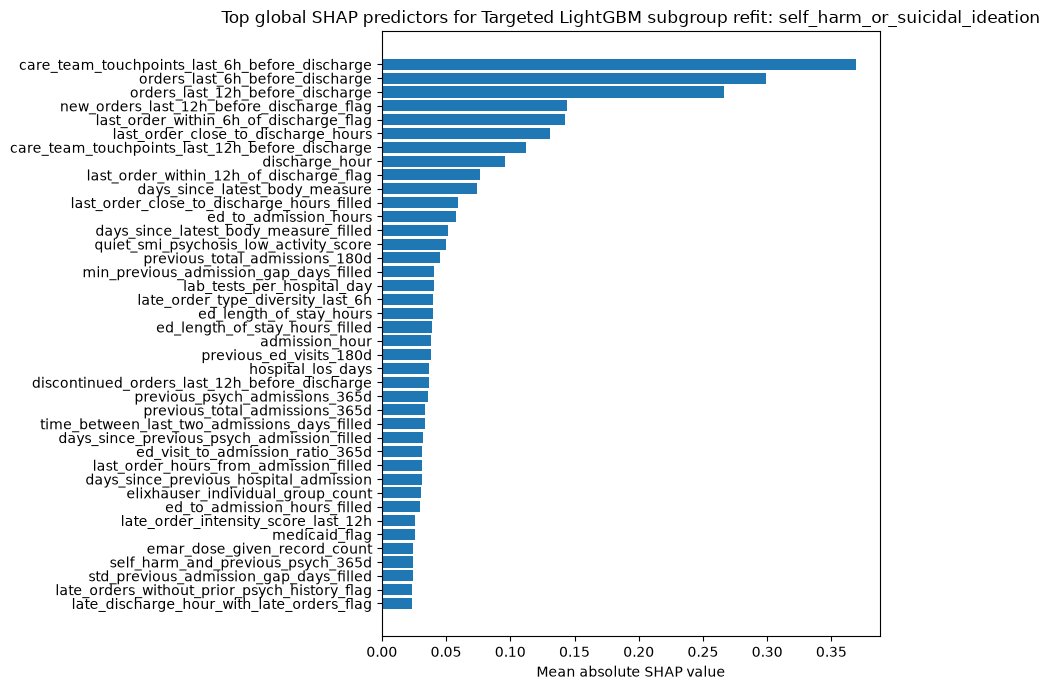

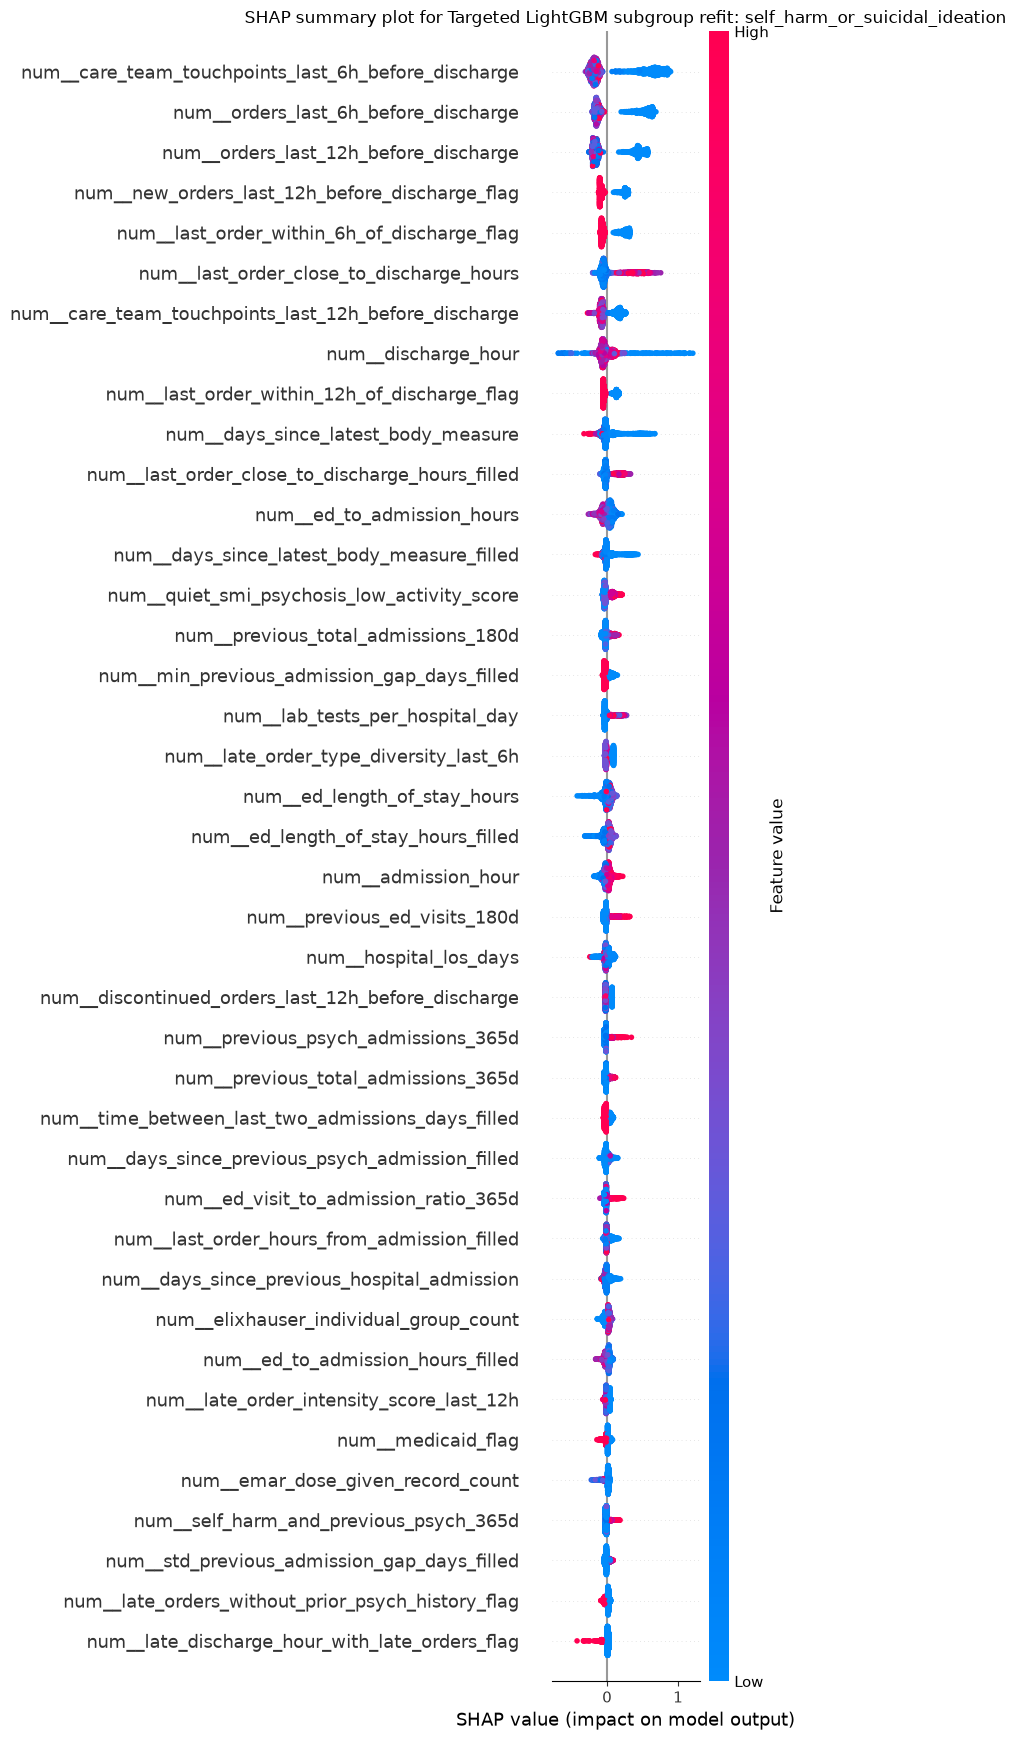

Skipping subgroup SHAP for older_70plus because the subgroup is too small.
Subgroup-specific SHAP model explanations saved to:
/scratch/DissProject/outputs/WP4/csv_tables/subgroup_models


,subgroup_shap_role,subgroup_model,source_analysis_set,source_table,model_family,matrix_source,train_admissions,test_admissions,test_readmission_rate,wp3_6_subgroup_pr_auc,wp3_6_subgroup_f1,selected_threshold,shap_sample_rows,shap_sample_positive_rows,subgroup_training_seconds,shap_elapsed_seconds,shap_expected_value_log_odds,shap_expected_value_probability,global_bar_plot_file,beeswarm_plot_file
0,best_pr_auc,self_harm_or_suicidal_ideation,clinical_subgroups,clinical_subgroups,Targeted LightGBM,shap_guided_reduced_feature_set,15279,3648,0.338268,0.878519,0.7829,0.28,2200,1042,620.951535,7.005158,-1.348064,0.206187,/scratch/DissProject/outputs/WP4/images/subgro...,/scratch/DissProject/outputs/WP4/images/subgro...


,subgroup_shap_role,subgroup_model,wp3_6_subgroup_pr_auc,wp3_6_subgroup_f1,model_family,model_slug,feature_family,processed_feature_count,total_mean_abs_shap,mean_abs_shap,max_mean_abs_shap,family_importance_rank
0,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,poe_order_pathway,176,1.682907,0.009562,0.298719,1
1,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,prior_utilisation,113,0.655635,0.005802,0.045258,2
2,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,care_team_complexity,13,0.519947,0.039996,0.369368,3
3,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,other,95,0.395078,0.004159,0.074231,4
4,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,psychiatric_history,117,0.279578,0.002390,0.050306,5
5,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,discharge_social,75,0.231770,0.003090,0.095576,6
6,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,ed_pathway,21,0.179703,0.008557,0.057502,7
7,best_pr_auc,self_harm_or_suicidal_ideation,0.878519,0.7829,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,medication_emar,70,0.154991,0.002214,0.024304,8


In [ ]:
#explain best and worst subgroup-specific refits from wp3.6 with shap
#only two subgroup models are retrained here: the highest-pr-auc and lowest-pr-auc subgroup-specific rows.
subgroup_model_shap_methodology_df = pd.DataFrame()
subgroup_model_shap_global_importance_df = pd.DataFrame()
subgroup_model_shap_family_importance_df = pd.DataFrame()
subgroup_model_shap_top5_features_by_family_df = pd.DataFrame()
subgroup_model_shap_error_group_mean_df = pd.DataFrame()
subgroup_model_shap_error_group_family_df = pd.DataFrame()
subgroup_model_shap_fp_vs_tp_contrast_df = pd.DataFrame()
subgroup_model_shap_fn_vs_tp_contrast_df = pd.DataFrame()
subgroup_model_selection_df = pd.DataFrame()

subgroup_model_output_dir = wp4_csv_output_path / "subgroup_models"
subgroup_model_image_dir = wp4_image_output_path / "subgroup_models"
subgroup_model_output_dir.mkdir(parents=True, exist_ok=True)
subgroup_model_image_dir.mkdir(parents=True, exist_ok=True)

clinical_subgroup_model_path = wp3_6_output_path / "csv_tables" / "t3_6_subgroup_specific_model_performance.csv"
diagnosis_subgroup_model_path = wp3_6_output_path / "csv_tables" / "t3_6_diagnosis_flag_subgroup_specific_model_performance.csv"
wp2_3_dataset_path = project_path / "outputs" / "t2_3_engineered_dataset.csv"

subgroup_performance_frames = []
for subgroup_path, subgroup_source_label in [
        (clinical_subgroup_model_path, "clinical_subgroups"),
        (diagnosis_subgroup_model_path, "diagnosis_flag_subgroups")]:

    if subgroup_path.exists():
        temp_df = pd.read_csv(subgroup_path)
    
        if not temp_df.empty:
            temp_df["subgroup_source_table"] = subgroup_source_label
            subgroup_performance_frames.append(temp_df)

if not subgroup_performance_frames:
    print("Subgroup model SHAP skipped because WP3.6 subgroup-specific performance files are unavailable.")
elif not wp2_3_dataset_path.exists():
    print("Subgroup model SHAP skipped because the engineered WP2.3 dataset is unavailable.")
else:
    subgroup_model_candidates_df = pd.concat(subgroup_performance_frames, ignore_index=True)
    subgroup_model_candidates_df = subgroup_model_candidates_df.loc[
        subgroup_model_candidates_df["comparison_type"].eq("subgroup_specific_model")].copy()
    subgroup_model_candidates_df = subgroup_model_candidates_df.loc[
        subgroup_model_candidates_df["model_family"].eq(final_model_family)].copy()
    subgroup_model_candidates_df["pr_auc_average_precision"] = pd.to_numeric(
        subgroup_model_candidates_df["pr_auc_average_precision"], errors="coerce")
    subgroup_model_candidates_df = subgroup_model_candidates_df.dropna(subset=["pr_auc_average_precision", "subgroup_model"])

    if subgroup_model_candidates_df.empty:
        print("Subgroup model SHAP skipped because no subgroup-specific rows match", final_model_family)
    else:
        best_subgroup_row = subgroup_model_candidates_df.sort_values(
            ["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=False).iloc[0].copy()
        worst_subgroup_row = subgroup_model_candidates_df.sort_values(
            ["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=True).iloc[0].copy()
        selected_subgroup_rows = pd.DataFrame([best_subgroup_row, worst_subgroup_row]).drop_duplicates(
            ["subgroup_source_table", "subgroup_model"]).reset_index(drop=True)
        selected_subgroup_rows.insert(0, "subgroup_shap_role", ["best_pr_auc", "worst_pr_auc"][:len(selected_subgroup_rows)])
        subgroup_model_selection_df = selected_subgroup_rows.copy()
        #save this table or artefact for later review
        subgroup_model_selection_df.to_csv(subgroup_model_output_dir / "t4_shap_subgroup_model_selected_refits.csv", index=False)

        #load the matching train matrix for the same feature set used by the final model.
        X_train_path = Path(str(X_test_path).replace("_X_test_", "_X_train_"))
        if not X_train_path.exists():
            raise FileNotFoundError(f"Matching train matrix was not found for subgroup refits: {X_train_path}")
        X_train_subgroup_source = sparse.load_npz(X_train_path)
        y_train_subgroup_source = pd.read_csv(wp3_1_output_path / "t3_1_y_train.csv")["readmitted_30d"].astype(int)
        train_ids_subgroup_source = pd.read_csv(wp3_1_output_path / "t3_1_train_ids.csv")

        engineered_header = pd.read_csv(wp2_3_dataset_path, nrows=0).columns.tolist()
        diagnosis_flag_columns = [column for column in [
            "has_depression", "has_bipolar_disorder", "has_psychotic_disorder", "has_anxiety_ptsd",
            "has_substance_use", "has_alcohol_related_disorder", "has_opioid_related_disorder",
            "has_stimulant_related_disorder", "has_cannabis_related_disorder",
            "has_tobacco_or_nicotine_related_disorder", "has_polysubstance_related_disorder",
            "has_self_harm_or_suicidal_ideation", "has_personality_disorder", "has_eating_disorder",
            "has_cognitive_delirium", "has_neurodevelopmental_disorder", "has_severe_mental_illness"]
            if column in engineered_header]
        clinical_signal_columns = [column for column in [
            "has_self_harm_or_suicidal_ideation", "has_severe_mental_illness", "has_substance_use",
            "has_psychotic_disorder", "elixhauser_psychoses", "previous_psych_admissions_365d",
            "previous_psych_admissions_90d", "previous_psych_admissions_from_all_hosp",
            "discharged_to_psych_facility_flag", "discharged_to_facility_flag", "discharged_home_flag",
            "age_65plus", "charlson_comorbidity_index_simplified"] if column in engineered_header]
        subgroup_signal_columns = sorted(set(diagnosis_flag_columns + clinical_signal_columns))
        subgroup_source_df = pd.read_csv(wp2_3_dataset_path, usecols=["subject_id", "hadm_id"] + subgroup_signal_columns)

        train_subgroup_source_df = train_ids_subgroup_source[["subject_id", "hadm_id"]].merge(
            subgroup_source_df, on=["subject_id", "hadm_id"], how="left")
        test_subgroup_source_df = test_ids[["subject_id", "hadm_id"]].merge(
            subgroup_source_df, on=["subject_id", "hadm_id"], how="left")
        #loop through each item in this feature block
        for subgroup_column in subgroup_signal_columns:
            train_subgroup_source_df[subgroup_column] = pd.to_numeric(
                train_subgroup_source_df[subgroup_column], errors="coerce").fillna(0)
            test_subgroup_source_df[subgroup_column] = pd.to_numeric(
                test_subgroup_source_df[subgroup_column], errors="coerce").fillna(0)

        #define subgroup column or zero
        def subgroup_column_or_zero(frame, column_name):
            return frame[column_name] if column_name in frame.columns else pd.Series(0, index=frame.index)

        #define subgroup mask from name
        def subgroup_mask_from_name(frame, subgroup_name):
        
            if subgroup_name in frame.columns:
                return subgroup_column_or_zero(frame, subgroup_name) > 0
            if subgroup_name == "self_harm_or_suicidal_ideation":
                return subgroup_column_or_zero(frame, "has_self_harm_or_suicidal_ideation") > 0
            if subgroup_name == "severe_mental_illness_or_psychosis":
                return (subgroup_column_or_zero(frame, "has_severe_mental_illness") +
                    subgroup_column_or_zero(frame, "has_psychotic_disorder") +
                    subgroup_column_or_zero(frame, "elixhauser_psychoses")) > 0
            if subgroup_name == "substance_use_related":
                return subgroup_column_or_zero(frame, "has_substance_use") > 0
            if subgroup_name == "recent_or_frequent_prior_psych":
                return (subgroup_column_or_zero(frame, "previous_psych_admissions_365d") +
                    subgroup_column_or_zero(frame, "previous_psych_admissions_90d") +
                    subgroup_column_or_zero(frame, "previous_psych_admissions_from_all_hosp")) > 0
            if subgroup_name == "older_or_medically_complex":
                return ((subgroup_column_or_zero(frame, "age_65plus") > 0) |
                    (subgroup_column_or_zero(frame, "charlson_comorbidity_index_simplified") >= 3))
            if subgroup_name == "older_70plus":
                return subgroup_column_or_zero(frame, "anchor_age") >= 70
            if subgroup_name == "older_65plus":
                return ((subgroup_column_or_zero(frame, "age_65plus") > 0) |
                    (subgroup_column_or_zero(frame, "anchor_age") >= 65))
            if subgroup_name == "medical_complexity":
                return subgroup_column_or_zero(frame, "charlson_comorbidity_index_simplified") >= 3
            if subgroup_name == "home_discharge":
                return subgroup_column_or_zero(frame, "discharged_home_flag") > 0
            if subgroup_name == "psych_or_facility_discharge":
                return ((subgroup_column_or_zero(frame, "discharged_to_psych_facility_flag") > 0) |
                    (subgroup_column_or_zero(frame, "discharged_to_facility_flag") > 0))
            print("Subgroup mask skipped because no rule is available for:", subgroup_name)
            return pd.Series(False, index=frame.index)

        #define clone subgroup model
        def clone_subgroup_model(base_model, train_indices):
            try:
                subgroup_model = clone(base_model)
            except Exception:
                subgroup_model = copy.deepcopy(base_model)

            #keep the same positive-class weighting strategy, but rescale it to the subgroup prevalence.
            class_counts = y_train_subgroup_source.iloc[train_indices].value_counts().sort_index()
            if 0 in class_counts.index and 1 in class_counts.index:
                subgroup_scale_pos_weight = class_counts.loc[0] / class_counts.loc[1]
                model_params = subgroup_model.get_params() if hasattr(subgroup_model, "get_params") else {}
                original_class_weight = model_params.get("class_weight")
            
                if isinstance(original_class_weight, dict) and 1 in original_class_weight:
                    global_counts = y_train_subgroup_source.value_counts().sort_index()
                    global_scale_pos_weight = global_counts.loc[0] / global_counts.loc[1]
                    class_weight_multiplier = original_class_weight[1] / global_scale_pos_weight
                    subgroup_model.set_params(class_weight={0: 1.0, 1: subgroup_scale_pos_weight * class_weight_multiplier})
                elif "scale_pos_weight" in model_params:
                    global_counts = y_train_subgroup_source.value_counts().sort_index()
                    global_scale_pos_weight = global_counts.loc[0] / global_counts.loc[1]
                    class_weight_multiplier = model_params.get("scale_pos_weight", global_scale_pos_weight) / global_scale_pos_weight
                    subgroup_model.set_params(scale_pos_weight=subgroup_scale_pos_weight * class_weight_multiplier)
            return subgroup_model

        subgroup_shap_table_collections = {"global_importance": [], "feature_family_importance": [],
            "top5_features_by_family": [], "error_group_mean": [], "error_group_family": [],
            "fp_vs_tp_contrast": [], "fn_vs_tp_contrast": []}
        subgroup_shap_methodology_rows = []

        for _, subgroup_row in selected_subgroup_rows.iterrows():
            subgroup_name = subgroup_row["subgroup_model"]
            subgroup_role = subgroup_row["subgroup_shap_role"]
            subgroup_slug = str(subgroup_name).replace("has_", "").replace("/", "_").replace(" ", "_")
            model_slug = f"subgroup_{subgroup_role}_{subgroup_slug}"

            train_mask = subgroup_mask_from_name(train_subgroup_source_df, subgroup_name).to_numpy(dtype=bool)
            test_mask = subgroup_mask_from_name(test_subgroup_source_df, subgroup_name).to_numpy(dtype=bool)
            train_indices = np.flatnonzero(train_mask)
            test_indices = np.flatnonzero(test_mask)
            if len(train_indices) < 200 or len(test_indices) < 100:
                print("Skipping subgroup SHAP for", subgroup_name, "because the subgroup is too small.")
                continue
            if y_train_subgroup_source.iloc[train_indices].nunique() < 2 or y_test.iloc[test_indices].nunique() < 2:
                print("Skipping subgroup SHAP for", subgroup_name, "because one class is missing.")
                continue

            subgroup_refit_model = clone_subgroup_model(final_model, train_indices)
            print("Training subgroup SHAP refit:", subgroup_role, subgroup_name)
            training_start = time.perf_counter()
            #fit the model on the current training data
            subgroup_refit_model.fit(X_train_subgroup_source[train_indices], y_train_subgroup_source.iloc[train_indices])
            subgroup_training_seconds = time.perf_counter() - training_start

            #score admissions as predicted readmission probabilities
            subgroup_test_probability = subgroup_refit_model.predict_proba(X_test[test_indices])[:, 1]
            subgroup_threshold = float(subgroup_row.get("threshold", wp4_selected_threshold))
            subgroup_index_df = test_ids.iloc[test_indices][["subject_id", "hadm_id"]].copy().reset_index(drop=True)
            subgroup_index_df["readmitted_30d"] = y_test.iloc[test_indices].to_numpy(dtype=int)
            subgroup_index_df["predicted_probability"] = subgroup_test_probability
            subgroup_index_df["test_row_index"] = np.arange(len(subgroup_index_df))

            subgroup_sample_indices, subgroup_X_sample, subgroup_sample_index_df = make_shap_sample(subgroup_index_df, X_test[test_indices])
            subgroup_diagnostic_df = create_error_group_index(subgroup_sample_index_df, subgroup_threshold)

            shap_start = time.perf_counter()
            subgroup_shap_values, subgroup_base_value, subgroup_plot_matrix = compute_tree_shap(
                subgroup_refit_model, subgroup_X_sample, processed_feature_names)
            subgroup_shap_seconds = time.perf_counter() - shap_start

            subgroup_tables = make_shap_summary_tables(
                f"{final_model_family} subgroup refit", model_slug, processed_feature_names,
                subgroup_shap_values, subgroup_diagnostic_df)
            #loop through each item in this feature block
            for table_name, table_df in subgroup_tables.items():
                table_df = table_df.copy()
                table_df.insert(0, "subgroup_shap_role", subgroup_role)
                table_df.insert(1, "subgroup_model", subgroup_name)
                table_df.insert(2, "wp3_6_subgroup_pr_auc", subgroup_row.get("pr_auc_average_precision", np.nan))
                table_df.insert(3, "wp3_6_subgroup_f1", subgroup_row.get("f1_score", np.nan))
                if table_name in subgroup_shap_table_collections:
                    subgroup_shap_table_collections[table_name].append(table_df)

            model_image_dir = subgroup_model_image_dir / model_slug
            bar_path, beeswarm_path = save_core_plots(
                f"{final_model_family} subgroup refit: {subgroup_name}", model_slug,
                processed_feature_names, subgroup_shap_values, subgroup_plot_matrix,
                subgroup_tables["global_importance"], model_image_dir)

            for table_name, table_df in subgroup_tables.items():
                #save this table or artefact for later review
                table_df.to_csv(subgroup_model_output_dir / f"t4_shap_{model_slug}_{table_name}.csv", index=False)

            subgroup_shap_methodology_rows.append({"subgroup_shap_role": subgroup_role,
                "subgroup_model": subgroup_name,
                "source_analysis_set": subgroup_row.get("analysis_set", np.nan),
                "source_table": subgroup_row.get("subgroup_source_table", np.nan),
                "model_family": final_model_family,
                "matrix_source": matrix_source_label,
                "train_admissions": len(train_indices),
                "test_admissions": len(test_indices),
                "test_readmission_rate": subgroup_index_df["readmitted_30d"].mean(),
                "wp3_6_subgroup_pr_auc": subgroup_row.get("pr_auc_average_precision", np.nan),
                "wp3_6_subgroup_f1": subgroup_row.get("f1_score", np.nan),
                "selected_threshold": subgroup_threshold,
                "shap_sample_rows": subgroup_X_sample.shape[0],
                "shap_sample_positive_rows": int(subgroup_sample_index_df["readmitted_30d"].sum()),
                "subgroup_training_seconds": subgroup_training_seconds,
                "shap_elapsed_seconds": subgroup_shap_seconds,
                "shap_expected_value_log_odds": subgroup_base_value,
                "shap_expected_value_probability": expit(subgroup_base_value),
                "global_bar_plot_file": str(bar_path),
                "beeswarm_plot_file": str(beeswarm_path)})

        subgroup_model_shap_methodology_df = pd.DataFrame(subgroup_shap_methodology_rows)
        subgroup_model_shap_methodology_df.to_csv(subgroup_model_output_dir / "t4_shap_subgroup_model_methodology.csv", index=False)

        for table_name, table_list in subgroup_shap_table_collections.items():
            combined_table = pd.concat(table_list, ignore_index=True) if table_list else pd.DataFrame()
            globals()[f"subgroup_model_shap_{table_name}_df"] = combined_table
            if not combined_table.empty:
                combined_table.to_csv(subgroup_model_output_dir / f"t4_shap_subgroup_model_{table_name}.csv", index=False)

        subgroup_model_shap_global_importance_df = subgroup_model_shap_global_importance_df if "subgroup_model_shap_global_importance_df" in globals() else pd.DataFrame()
        subgroup_model_shap_family_importance_df = subgroup_model_shap_feature_family_importance_df if "subgroup_model_shap_feature_family_importance_df" in globals() else pd.DataFrame()
        subgroup_model_shap_top5_features_by_family_df = subgroup_model_shap_top5_features_by_family_df if "subgroup_model_shap_top5_features_by_family_df" in globals() else pd.DataFrame()
        subgroup_model_shap_error_group_mean_df = subgroup_model_shap_error_group_mean_df if "subgroup_model_shap_error_group_mean_df" in globals() else pd.DataFrame()
        subgroup_model_shap_error_group_family_df = subgroup_model_shap_error_group_family_df if "subgroup_model_shap_error_group_family_df" in globals() else pd.DataFrame()
        subgroup_model_shap_fp_vs_tp_contrast_df = subgroup_model_shap_fp_vs_tp_contrast_df if "subgroup_model_shap_fp_vs_tp_contrast_df" in globals() else pd.DataFrame()
        subgroup_model_shap_fn_vs_tp_contrast_df = subgroup_model_shap_fn_vs_tp_contrast_df if "subgroup_model_shap_fn_vs_tp_contrast_df" in globals() else pd.DataFrame()

        subgroup_model_workbook_path = wp4_output_path / "t4_shap_subgroup_model_explanation_tables.xlsx"
        subgroup_model_workbook_tables = {"selected_subgroup_refits": subgroup_model_selection_df,
            "methodology": subgroup_model_shap_methodology_df,
            "global_importance": subgroup_model_shap_global_importance_df,
            "feature_family_importance": subgroup_model_shap_family_importance_df,
            "top5_features_by_family": subgroup_model_shap_top5_features_by_family_df,
            "error_group_mean": subgroup_model_shap_error_group_mean_df,
            "error_group_family": subgroup_model_shap_error_group_family_df,
            "fp_vs_tp_contrast": subgroup_model_shap_fp_vs_tp_contrast_df,
            "fn_vs_tp_contrast": subgroup_model_shap_fn_vs_tp_contrast_df}
        with pd.ExcelWriter(subgroup_model_workbook_path) as writer:
            for sheet_name, table_df in subgroup_model_workbook_tables.items():
                if table_df is not None and not table_df.empty:
                    #save this table or artefact for later review
                    table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

        print("Subgroup-specific SHAP model explanations saved to:")
        print(subgroup_model_output_dir)
        display(subgroup_model_shap_methodology_df)
        if not subgroup_model_shap_family_importance_df.empty:
            #summarise row-level records to admission-level features
            display(subgroup_model_shap_family_importance_df.groupby(["subgroup_shap_role", "subgroup_model"]).head(8))

**4.7 - Hourly Sequence Model Explainability**

WP3.5 trains the hourly GRU/LSTM and hybrid tabular-sequence models. This WP4 section reloads those saved models and explains them using occlusion tests rather than standard SHAP. One hourly channel or time block is masked at a time; larger drops in PR-AUC or ROC-AUC suggest greater model reliance on that part of the hourly trajectory. Representative trajectory plots are also saved for selected sequence-available cases.





In [ ]:
#explain hourly gru/lstm sequence models using channel and time-window occlusion
hourly_sequence_channel_occlusion_df = pd.DataFrame()
hourly_sequence_window_occlusion_df = pd.DataFrame()
hourly_sequence_selected_cases_df = pd.DataFrame()
hourly_sequence_trajectory_plot_df = pd.DataFrame()

sequence_array_path = wp3_5_output_path / "sequence_arrays" / "t3_5_test_first72h_clinical_sequence.npz"
sequence_feature_path = wp3_5_output_path / "csv_tables" / "t3_5_hourly_clinical_sequence_features.csv"
sequence_model_output_path = wp3_5_output_path / "models"
wp4_sequence_output_path = wp4_output_path / "hourly_sequence_explainability"
wp4_sequence_image_output_path = wp4_image_output_path / "hourly_sequence_explainability"
wp4_sequence_csv_output_path = wp4_csv_output_path / "hourly_sequence_explainability"
#loop through each item in this feature block
for folder_path in [wp4_sequence_output_path, wp4_sequence_image_output_path, wp4_sequence_csv_output_path]:
    folder_path.mkdir(parents=True, exist_ok=True)

sequence_required_files = [sequence_array_path, sequence_feature_path]
if not torch_available_for_sequence:
    print("hourly sequence explainability skipped because PyTorch is unavailable:", torch_sequence_import_error)
elif any(not path.exists() for path in sequence_required_files):
    print("hourly sequence explainability skipped because WP3.5 sequence files are missing:")
    #loop through each item in this feature block
    for path in sequence_required_files:
        print(path, "exists:", path.exists())
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    sequence_feature_df = pd.read_csv(sequence_feature_path)
    sequence_feature_columns = sequence_feature_df["sequence_feature"].astype(str).tolist()
    sequence_raw_columns = [col for col in sequence_feature_columns if not col.endswith("_observed_mask")]
    sequence_npz = np.load(sequence_array_path, allow_pickle=True)
    test_sequence_array_all = sequence_npz["sequence_array"].astype(np.float32)
    test_sequence_mask_all = sequence_npz["mask_array"].astype(np.float32)
    test_sequence_available = sequence_npz["sequence_available"].astype(bool)
    sequence_max_hours = test_sequence_array_all.shape[1]
    X_test_sequence = test_sequence_array_all[test_sequence_available]
    test_sequence_mask = test_sequence_mask_all[test_sequence_available]
    y_test_sequence = y_test.to_numpy()[test_sequence_available] if hasattr(y_test, "to_numpy") else np.asarray(y_test)[test_sequence_available]
    test_ids_sequence = pd.DataFrame({"subject_id": sequence_npz["subject_id"],
        "hadm_id": sequence_npz["hadm_id"]}).loc[test_sequence_available].reset_index(drop=True)
    sequence_tabular_test = X_test[test_sequence_available]

    #encode hourly clinical sequences using a gru and predict readmission risk
    class VitalSequenceGRU(nn.Module):
        #initialise model or helper state
        def __init__(self, input_dim, hidden_dim=64, dropout=0.20):
            super().__init__()
            self.gru = nn.GRU(input_dim, hidden_dim, num_layers=1, batch_first=True)
            self.dropout = nn.Dropout(dropout)
            self.head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
        #define encode
        def encode(self, sequence, mask):
            output, _ = self.gru(sequence)
            lengths = mask.sum(dim=1).long().clamp(min=1)
            last_positions = (lengths - 1).view(-1, 1, 1).expand(-1, 1, output.shape[-1])
            encoded = output.gather(1, last_positions).squeeze(1)
            return self.dropout(encoded)
        #run the model forward pass
        def forward(self, sequence, mask):
            return self.head(self.encode(sequence, mask))

    #encode hourly clinical sequences using an lstm and predict readmission risk
    class VitalSequenceLSTM(nn.Module):
        #initialise model or helper state
        def __init__(self, input_dim, hidden_dim=64, dropout=0.20):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True)
            self.dropout = nn.Dropout(dropout)
            self.head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
        #define encode
        def encode(self, sequence, mask):
            output, _ = self.lstm(sequence)
            lengths = mask.sum(dim=1).long().clamp(min=1)
            last_positions = (lengths - 1).view(-1, 1, 1).expand(-1, 1, output.shape[-1])
            encoded = output.gather(1, last_positions).squeeze(1)
            return self.dropout(encoded)
        #run the model forward pass
        def forward(self, sequence, mask):
            return self.head(self.encode(sequence, mask))

    #combine gru sequence embeddings with tabular features for hybrid prediction
    class HybridTabularVitalGRU(nn.Module):
        #initialise model or helper state
        def __init__(self, tabular_dim, sequence_dim, hidden_dim=64, dropout=0.25):
            super().__init__()
            self.sequence_encoder = VitalSequenceGRU(sequence_dim, hidden_dim=hidden_dim, dropout=dropout)
            self.tabular_encoder = nn.Sequential(nn.Linear(tabular_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(256, 64), nn.ReLU())
            self.head = nn.Sequential(nn.Linear(hidden_dim + 64, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
        #run the model forward pass
        def forward(self, sequence, mask, tabular):
            sequence_embedding = self.sequence_encoder.encode(sequence, mask)
            tabular_embedding = self.tabular_encoder(tabular)
            return self.head(torch.cat([sequence_embedding, tabular_embedding], dim=1))

    #combine lstm sequence embeddings with tabular features for hybrid prediction
    class HybridTabularVitalLSTM(nn.Module):
        #initialise model or helper state
        def __init__(self, tabular_dim, sequence_dim, hidden_dim=64, dropout=0.25):
            super().__init__()
            self.sequence_encoder = VitalSequenceLSTM(sequence_dim, hidden_dim=hidden_dim, dropout=dropout)
            self.tabular_encoder = nn.Sequential(nn.Linear(tabular_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(256, 64), nn.ReLU())
            self.head = nn.Sequential(nn.Linear(hidden_dim + 64, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
        #run the model forward pass
        def forward(self, sequence, mask, tabular):
            sequence_embedding = self.sequence_encoder.encode(sequence, mask)
            tabular_embedding = self.tabular_encoder(tabular)
            return self.head(torch.cat([sequence_embedding, tabular_embedding], dim=1))

    #yield sequence, mask, and optional tabular batches for memory-safe prediction
    def sequence_batches(sequence_array, mask_array, tabular_sparse=None, batch_size=1024):
        #loop through each item in this feature block
        for start in range(0, sequence_array.shape[0], batch_size):
            end = start + batch_size
            seq_batch = sequence_array[start:end].astype(np.float32)
            mask_batch = mask_array[start:end].astype(np.float32)
            if tabular_sparse is None:
                yield seq_batch, mask_batch
            else:
                yield seq_batch, mask_batch, tabular_sparse[start:end].toarray().astype(np.float32)

    #reload a sequence model and return predicted probabilities in batches
    def predict_reloaded_sequence_model(model, sequence_array, mask_array, tabular_sparse=None, batch_size=1024):
        model.eval()
        probabilities = []
        with torch.no_grad():
            #loop through each item in this feature block
            for batch in sequence_batches(sequence_array, mask_array, tabular_sparse=tabular_sparse, batch_size=batch_size):
            
                if tabular_sparse is None:
                    seq_batch, mask_batch = batch
                    logits = model(torch.from_numpy(seq_batch).to(device), torch.from_numpy(mask_batch).to(device)).view(-1)
                else:
                    seq_batch, mask_batch, tab_batch = batch
                    logits = model(torch.from_numpy(seq_batch).to(device), torch.from_numpy(mask_batch).to(device),
                        torch.from_numpy(tab_batch).to(device)).view(-1)
                probabilities.append(torch.sigmoid(logits).detach().cpu().numpy())
        return np.concatenate(probabilities) if probabilities else np.array([])

    #score sequence-model probabilities using discrimination and calibration metrics
    def score_sequence_predictions(y_true, probability):
        return {"pr_auc_average_precision": average_precision_score(y_true, probability),
            "roc_auc": roc_auc_score(y_true, probability),
            "brier_score": brier_score_loss(y_true, probability)}

    #load the validation-f1 threshold saved for a sequence model
    def load_sequence_threshold(model_key):
        performance_path = wp3_5_output_path / "csv_tables" / f"t3_5_{model_key}_performance.csv"
    
        if performance_path.exists():
            performance_df = pd.read_csv(performance_path)
            f1_rows = performance_df[performance_df.get("threshold_role", "").eq("validation_f1")]
            if not f1_rows.empty and "threshold" in f1_rows.columns:
                return float(f1_rows.iloc[0]["threshold"])
        return 0.5

    #load a saved sequence model and check tabular feature compatibility
    def load_sequence_model(model_key, model_class, tabular_dim=None):
        state_path = sequence_model_output_path / f"t3_5_{model_key}_state_dict.pt"
        if not state_path.exists():
            return None, f"missing state dict: {state_path}"
        state_dict = torch.load(state_path, map_location=device)
        if tabular_dim is not None and "tabular_encoder.0.weight" in state_dict:
            expected_tabular_dim = int(state_dict["tabular_encoder.0.weight"].shape[1])
            if expected_tabular_dim != tabular_dim:
                return None, f"tabular feature mismatch for {model_key}: model expects {expected_tabular_dim}, WP4 loaded {tabular_dim}"
        model = model_class(len(sequence_feature_columns)) if tabular_dim is None else model_class(tabular_dim, len(sequence_feature_columns))
        model.load_state_dict(state_dict)
        model = model.to(device)
        model.eval()
        return model, None

    sequence_model_specs = [
        {"model_name": "Hourly Clinical GRU", "model_key": "hourly_clinical_gru", "model_class": VitalSequenceGRU, "tabular_sparse": None},
        {"model_name": "Hourly Clinical LSTM", "model_key": "hourly_clinical_lstm", "model_class": VitalSequenceLSTM, "tabular_sparse": None},
        {"model_name": "Hybrid Tabular + Hourly Clinical GRU", "model_key": "hybrid_tabular_hourly_clinical_gru", "model_class": HybridTabularVitalGRU, "tabular_sparse": sequence_tabular_test},
        {"model_name": "Hybrid Tabular + Hourly Clinical LSTM", "model_key": "hybrid_tabular_hourly_clinical_lstm", "model_class": HybridTabularVitalLSTM, "tabular_sparse": sequence_tabular_test}]

    loaded_sequence_models = []
    for spec in sequence_model_specs:
        tabular_dim = X_test.shape[1] if spec["tabular_sparse"] is not None else None
        model, skip_reason = load_sequence_model(spec["model_key"], spec["model_class"], tabular_dim=tabular_dim)
        if model is None:
            print("skipping", spec["model_name"], "-", skip_reason)
            continue
        baseline_probability = predict_reloaded_sequence_model(model, X_test_sequence, test_sequence_mask,
            tabular_sparse=spec["tabular_sparse"])
        loaded_sequence_models.append({**spec, "model": model, "baseline_probability": baseline_probability,
            "threshold": load_sequence_threshold(spec["model_key"])})

    #remove one hourly clinical channel to estimate its contribution
    def mask_sequence_channel(sequence_array, channel_name):
        masked_sequence = sequence_array.copy()
        if channel_name not in sequence_raw_columns:
            return masked_sequence
        value_position = sequence_feature_columns.index(channel_name)
        mask_name = f"{channel_name}_observed_mask"
        mask_position = sequence_feature_columns.index(mask_name) if mask_name in sequence_feature_columns else None
        masked_sequence[:, :, value_position] = 0
        if mask_position is not None:
            masked_sequence[:, :, mask_position] = 0
        return masked_sequence

    #remove one time window to estimate when the sequence model gets signal
    def mask_sequence_window(sequence_array, mask_array, start_hour, end_hour):
        masked_sequence = sequence_array.copy()
        masked_mask = mask_array.copy()
        start_position = max(int(start_hour) - 1, 0)
        end_position = min(int(end_hour), masked_sequence.shape[1])
        masked_sequence[:, start_position:end_position, :] = 0
        masked_mask[:, start_position:end_position] = 0
        return masked_sequence, masked_mask

    channel_rows = []
    window_rows = []
    time_windows = [(1, 12, "hours_01_12"), (13, 24, "hours_13_24"),
        (25, 48, "hours_25_48"), (49, 72, "hours_49_72"),
        (1, 24, "hours_01_24"), (25, 72, "hours_25_72")]

    for model_info in loaded_sequence_models:
        baseline_scores = score_sequence_predictions(y_test_sequence, model_info["baseline_probability"])
        for channel_name in sequence_raw_columns:
            masked_sequence = mask_sequence_channel(X_test_sequence, channel_name)
            masked_probability = predict_reloaded_sequence_model(model_info["model"], masked_sequence, test_sequence_mask,
                tabular_sparse=model_info["tabular_sparse"])
            masked_scores = score_sequence_predictions(y_test_sequence, masked_probability)
            channel_rows.append({"model_name": model_info["model_name"], "model_key": model_info["model_key"],
                "occluded_channel": channel_name,
                "baseline_pr_auc_average_precision": baseline_scores["pr_auc_average_precision"],
                "occluded_pr_auc_average_precision": masked_scores["pr_auc_average_precision"],
                "pr_auc_drop_when_masked": baseline_scores["pr_auc_average_precision"] - masked_scores["pr_auc_average_precision"],
                "baseline_roc_auc": baseline_scores["roc_auc"], "occluded_roc_auc": masked_scores["roc_auc"],
                "roc_auc_drop_when_masked": baseline_scores["roc_auc"] - masked_scores["roc_auc"],
                "baseline_brier_score": baseline_scores["brier_score"], "occluded_brier_score": masked_scores["brier_score"],
                "brier_increase_when_masked": masked_scores["brier_score"] - baseline_scores["brier_score"]})
        for start_hour, end_hour, window_label in time_windows:
            masked_sequence, masked_mask = mask_sequence_window(X_test_sequence, test_sequence_mask, start_hour, end_hour)
            masked_probability = predict_reloaded_sequence_model(model_info["model"], masked_sequence, masked_mask,
                tabular_sparse=model_info["tabular_sparse"])
            masked_scores = score_sequence_predictions(y_test_sequence, masked_probability)
            window_rows.append({"model_name": model_info["model_name"], "model_key": model_info["model_key"],
                "occluded_window": window_label, "start_hour": start_hour, "end_hour": end_hour,
                "baseline_pr_auc_average_precision": baseline_scores["pr_auc_average_precision"],
                "occluded_pr_auc_average_precision": masked_scores["pr_auc_average_precision"],
                "pr_auc_drop_when_masked": baseline_scores["pr_auc_average_precision"] - masked_scores["pr_auc_average_precision"],
                "baseline_roc_auc": baseline_scores["roc_auc"], "occluded_roc_auc": masked_scores["roc_auc"],
                "roc_auc_drop_when_masked": baseline_scores["roc_auc"] - masked_scores["roc_auc"],
                "baseline_brier_score": baseline_scores["brier_score"], "occluded_brier_score": masked_scores["brier_score"],
                "brier_increase_when_masked": masked_scores["brier_score"] - baseline_scores["brier_score"]})

    hourly_sequence_channel_occlusion_df = pd.DataFrame(channel_rows).sort_values(
        ["model_name", "pr_auc_drop_when_masked"], ascending=[True, False]).reset_index(drop=True)
    hourly_sequence_window_occlusion_df = pd.DataFrame(window_rows).sort_values(
        ["model_name", "pr_auc_drop_when_masked"], ascending=[True, False]).reset_index(drop=True)

    #save this table or artefact for later review
    hourly_sequence_channel_occlusion_df.to_csv(wp4_sequence_csv_output_path / "t4_hourly_sequence_channel_occlusion_importance.csv", index=False)
    hourly_sequence_window_occlusion_df.to_csv(wp4_sequence_csv_output_path / "t4_hourly_sequence_time_window_occlusion_importance.csv", index=False)

    if loaded_sequence_models:
        best_sequence_model_info = sorted(loaded_sequence_models,
            key=lambda item: average_precision_score(y_test_sequence, item["baseline_probability"]), reverse=True)[0]
        case_probability = best_sequence_model_info["baseline_probability"]
        case_threshold = best_sequence_model_info["threshold"]
        case_df = test_ids_sequence.copy()
        case_df["sequence_test_position"] = np.arange(len(case_df))
        case_df["readmitted_30d"] = y_test_sequence
        case_df["predicted_probability"] = case_probability
        case_df["predicted_class"] = (case_probability >= case_threshold).astype(int)
        case_df["classification_group"] = np.select([
                (case_df["readmitted_30d"] == 1) & (case_df["predicted_class"] == 1),
                (case_df["readmitted_30d"] == 0) & (case_df["predicted_class"] == 1),
                (case_df["readmitted_30d"] == 1) & (case_df["predicted_class"] == 0),
                (case_df["readmitted_30d"] == 0) & (case_df["predicted_class"] == 0)],
            ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")
        selected_case_rows = []
        case_selection_rules = [("high_risk_true_positive", "true_positive", False),
            ("false_positive_highest_risk", "false_positive", False),
            ("false_negative_lowest_risk", "false_negative", True),
            ("low_risk_true_negative", "true_negative", True)]
        for case_label, group_name, ascending_probability in case_selection_rules:
            group_df = case_df[case_df["classification_group"] == group_name].copy()
            if not group_df.empty:
                selected_row = group_df.sort_values("predicted_probability", ascending=ascending_probability).iloc[0].copy()
                selected_row["local_case_label"] = case_label
                selected_row["explained_sequence_model"] = best_sequence_model_info["model_name"]
                selected_case_rows.append(selected_row)
        hourly_sequence_selected_cases_df = pd.DataFrame(selected_case_rows)
        #save this table or artefact for later review
        hourly_sequence_selected_cases_df.to_csv(wp4_sequence_csv_output_path / "t4_hourly_sequence_selected_trajectory_cases.csv", index=False)

        trajectory_channels = [col for col in ["heart_rate", "spo2", "respiratory_rate", "systolic_bp_noninvasive",
                "mean_bp_noninvasive", "num_total_clinical_events", "num_instability_process_events"]
            if col in sequence_feature_columns]

        #plot selected hourly trajectories for individual admissions
        def plot_sequence_case(case_position, case_label):
            if not trajectory_channels:
                return None
            hours = np.arange(1, sequence_max_hours + 1)
            plt.figure(figsize=(10, 5))
            for channel_name in trajectory_channels:
                value_position = sequence_feature_columns.index(channel_name)
                channel_values = X_test_sequence[case_position, :, value_position].astype(float)
                mask_name = f"{channel_name}_observed_mask"
                if mask_name in sequence_feature_columns:
                    channel_mask = X_test_sequence[case_position, :, sequence_feature_columns.index(mask_name)] > 0
                    channel_values = np.where(channel_mask, channel_values, np.nan)
                if np.isfinite(channel_values).any():
                    plt.plot(hours, channel_values, marker="o", markersize=2, linewidth=1.3, label=channel_name)
            plt.axhline(0, color="black", linewidth=0.8, alpha=0.35)
            plt.xlabel("hour from admission")
            plt.ylabel("scaled hourly value")
            plt.title(case_label.replace("_", " "))
            plt.legend(loc="upper right", fontsize=8)
            plt.tight_layout()
            image_path = wp4_sequence_image_output_path / f"t4_hourly_sequence_trajectory_{case_label}.png"
            plt.savefig(image_path, dpi=250)
            plt.close()
            return image_path

        plot_rows = []
        for _, case_row in hourly_sequence_selected_cases_df.iterrows():
            case_position = int(case_row["sequence_test_position"])
            image_path = plot_sequence_case(case_position, case_row["local_case_label"])
            if image_path is not None:
                plot_rows.append({"local_case_label": case_row["local_case_label"],
                    "subject_id": case_row.get("subject_id"), "hadm_id": case_row.get("hadm_id"),
                    "trajectory_plot_path": str(image_path)})
        hourly_sequence_trajectory_plot_df = pd.DataFrame(plot_rows)
        hourly_sequence_trajectory_plot_df.to_csv(wp4_sequence_csv_output_path / "t4_hourly_sequence_trajectory_plot_summary.csv", index=False)

    hourly_sequence_methodology_df = pd.DataFrame([{
        "sequence_array_path": str(sequence_array_path),
        "sequence_feature_path": str(sequence_feature_path),
        "sequence_available_test_admissions": int(len(y_test_sequence)),
        "loaded_sequence_models": ", ".join([item["model_name"] for item in loaded_sequence_models]),
        "explanation_method": "channel and time-window occlusion"}])
    hourly_sequence_methodology_df.to_csv(wp4_sequence_csv_output_path / "t4_hourly_sequence_explainability_methodology.csv", index=False)

    hourly_sequence_workbook_path = wp4_sequence_output_path / "t4_hourly_sequence_explainability_tables.xlsx"
    with pd.ExcelWriter(hourly_sequence_workbook_path) as writer:
        hourly_sequence_methodology_df.to_excel(writer, sheet_name="methodology", index=False)
        hourly_sequence_channel_occlusion_df.to_excel(writer, sheet_name="channel_occlusion", index=False)
        hourly_sequence_window_occlusion_df.to_excel(writer, sheet_name="time_window_occlusion", index=False)
        hourly_sequence_selected_cases_df.to_excel(writer, sheet_name="selected_cases", index=False)
        hourly_sequence_trajectory_plot_df.to_excel(writer, sheet_name="trajectory_plots", index=False)

    print("hourly sequence explainability complete")
    print("loaded sequence models:", [item["model_name"] for item in loaded_sequence_models])
    print("top channel occlusion rows:")
    
    #summarise row-level records to admission-level features
    display(hourly_sequence_channel_occlusion_df.groupby("model_name").head(8).round(4))
    print("time-window occlusion rows:")
    display(hourly_sequence_window_occlusion_df.round(4))

hourly sequence explainability complete
loaded sequence models: ['Hourly Clinical GRU', 'Hourly Clinical LSTM', 'Hybrid Tabular + Hourly Clinical GRU', 'Hybrid Tabular + Hourly Clinical LSTM']
top channel occlusion rows:


,model_name,model_key,occluded_channel,baseline_pr_auc_average_precision,occluded_pr_auc_average_precision,pr_auc_drop_when_masked,baseline_roc_auc,occluded_roc_auc,roc_auc_drop_when_masked,baseline_brier_score,occluded_brier_score,brier_increase_when_masked
0,Hourly Clinical GRU,hourly_clinical_gru,heart_rate,0.1789,0.1749,0.0040,0.5551,0.5491,0.0060,0.2312,0.2316,0.0003
1,Hourly Clinical GRU,hourly_clinical_gru,respiratory_rate,0.1789,0.1767,0.0022,0.5551,0.5484,0.0066,0.2312,0.2308,-0.0004
2,Hourly Clinical GRU,hourly_clinical_gru,systolic_bp_noninvasive,0.1789,0.1769,0.0020,0.5551,0.5560,-0.0009,0.2312,0.2249,-0.0064
3,Hourly Clinical GRU,hourly_clinical_gru,num_emar_events,0.1789,0.1778,0.0011,0.5551,0.5534,0.0017,0.2312,0.2272,-0.0040
4,Hourly Clinical GRU,hourly_clinical_gru,num_icu_input_events,0.1789,0.1779,0.0010,0.5551,0.5545,0.0006,0.2312,0.2356,0.0044
5,Hourly Clinical GRU,hourly_clinical_gru,num_poe_discontinued_or_cancelled_orders,0.1789,0.1780,0.0010,0.5551,0.5546,0.0005,0.2312,0.2326,0.0013
6,Hourly Clinical GRU,hourly_clinical_gru,num_priority_lab_events,0.1789,0.1781,0.0008,0.5551,0.5548,0.0003,0.2312,0.2363,0.0051
7,Hourly Clinical GRU,hourly_clinical_gru,mean_bp_noninvasive,0.1789,0.1781,0.0008,0.5551,0.5563,-0.0013,0.2312,0.2258,-0.0054
35,Hourly Clinical LSTM,hourly_clinical_lstm,heart_rate,0.1711,0.1660,0.0051,0.5522,0.5432,0.0089,0.2407,0.2405,-0.0002
36,Hourly Clinical LSTM,hourly_clinical_lstm,respiratory_rate,0.1711,0.1684,0.0027,0.5522,0.5474,0.0047,0.2407,0.2373,-0.0033


time-window occlusion rows:


,model_name,model_key,occluded_window,start_hour,end_hour,baseline_pr_auc_average_precision,occluded_pr_auc_average_precision,pr_auc_drop_when_masked,baseline_roc_auc,occluded_roc_auc,roc_auc_drop_when_masked,baseline_brier_score,occluded_brier_score,brier_increase_when_masked
0,Hourly Clinical GRU,hourly_clinical_gru,hours_01_24,1,24,0.1789,0.1647,0.0142,0.5551,0.5262,0.0288,0.2312,0.2285,-0.0027
1,Hourly Clinical GRU,hourly_clinical_gru,hours_01_12,1,12,0.1789,0.1737,0.0052,0.5551,0.5487,0.0063,0.2312,0.2296,-0.0016
2,Hourly Clinical GRU,hourly_clinical_gru,hours_49_72,49,72,0.1789,0.1776,0.0013,0.5551,0.5488,0.0063,0.2312,0.2332,0.0019
3,Hourly Clinical GRU,hourly_clinical_gru,hours_25_72,25,72,0.1789,0.1787,0.0002,0.5551,0.5482,0.0068,0.2312,0.2383,0.0070
4,Hourly Clinical GRU,hourly_clinical_gru,hours_25_48,25,48,0.1789,0.1820,-0.0031,0.5551,0.5408,0.0143,0.2312,0.2346,0.0034
5,Hourly Clinical GRU,hourly_clinical_gru,hours_13_24,13,24,0.1789,0.1820,-0.0031,0.5551,0.5515,0.0036,0.2312,0.2339,0.0026
6,Hourly Clinical LSTM,hourly_clinical_lstm,hours_01_24,1,24,0.1711,0.1634,0.0077,0.5522,0.5236,0.0286,0.2407,0.2380,-0.0027
7,Hourly Clinical LSTM,hourly_clinical_lstm,hours_25_72,25,72,0.1711,0.1700,0.0011,0.5522,0.5425,0.0097,0.2407,0.2409,0.0003
8,Hourly Clinical LSTM,hourly_clinical_lstm,hours_49_72,49,72,0.1711,0.1718,-0.0006,0.5522,0.5472,0.0050,0.2407,0.2403,-0.0004
9,Hourly Clinical LSTM,hourly_clinical_lstm,hours_25_48,25,48,0.1711,0.1735,-0.0024,0.5522,0.5410,0.0112,0.2407,0.2475,0.0068


**4.8 - Explanation Consistency Across Model Views**

This section compares the highest-ranking feature families across the main SHAP model, the paired boosting models, the subgroup refits, and the hourly sequence occlusion outputs when available. It is a compact check of whether the same clinical signal keeps appearing across explanation views.


In [ ]:
#compare the strongest explanation families across model views
explanation_consistency_df = pd.DataFrame()
explanation_consistency_overlap_df = pd.DataFrame()

#standardise feature-family importance tables from different explanation outputs
def _normalise_family_table(table_df, source_label, model_label=None):
    if table_df is None or table_df.empty or "feature_family" not in table_df.columns:
        return pd.DataFrame()
    score_col = "total_mean_abs_shap" if "total_mean_abs_shap" in table_df.columns else None
    if score_col is None and "mean_abs_shap" in table_df.columns:
        score_col = "mean_abs_shap"
    if score_col is None:
        return pd.DataFrame()
    result_df = table_df.copy()
    result_df["explanation_source"] = source_label
    if model_label is not None:
        result_df["model_view"] = model_label
    elif "model_family" in result_df.columns:
        result_df["model_view"] = result_df["model_family"].astype(str)
    elif "subgroup_shap_role" in result_df.columns and "subgroup_model" in result_df.columns:
        result_df["model_view"] = result_df["subgroup_shap_role"].astype(str) + ": " + result_df["subgroup_model"].astype(str)
    else:
        result_df["model_view"] = source_label
    keep_cols = ["explanation_source", "model_view", "feature_family", score_col]
    result_df = result_df[keep_cols].rename(columns={score_col: "importance_score"})
    result_df["importance_score"] = pd.to_numeric(result_df["importance_score"], errors="coerce")
    result_df = result_df.dropna(subset=["importance_score"])
    result_df = result_df.sort_values(["model_view", "importance_score"], ascending=[True, False])

    #summarise row-level records to admission-level features
    result_df["family_rank_within_view"] = result_df.groupby("model_view")["importance_score"].rank(method="first", ascending=False).astype(int)
    return result_df

consistency_frames = []
consistency_frames.append(_normalise_family_table(globals().get("shap_family_importance_df"), "main_shap", "main_final_model"))
consistency_frames.append(_normalise_family_table(globals().get("paired_model_family_importance_df"), "paired_model_shap"))
consistency_frames.append(_normalise_family_table(globals().get("subgroup_model_shap_family_importance_df"), "subgroup_refit_shap"))

#hourly explanations use occlusion rather than shap, so they are summarised separately if present.
hourly_channel_df = globals().get("hourly_sequence_channel_occlusion_df", pd.DataFrame())
if hourly_channel_df is not None and not hourly_channel_df.empty:
    channel_col = "channel" if "channel" in hourly_channel_df.columns else "feature_name" if "feature_name" in hourly_channel_df.columns else None
    score_candidates = [col for col in ["pr_auc_drop", "roc_auc_drop", "average_precision_drop", "metric_drop"] if col in hourly_channel_df.columns]
    if channel_col is not None and score_candidates:
        hourly_summary_df = hourly_channel_df.copy()
        hourly_summary_df["feature_family"] = "hourly_" + hourly_summary_df[channel_col].astype(str)
        hourly_summary_df["total_mean_abs_shap"] = pd.to_numeric(hourly_summary_df[score_candidates[0]], errors="coerce").abs()
        consistency_frames.append(_normalise_family_table(hourly_summary_df, "hourly_sequence_occlusion", "hourly_sequence_model"))

consistency_frames = [frame for frame in consistency_frames if frame is not None and not frame.empty]
if consistency_frames:
    explanation_consistency_df = pd.concat(consistency_frames, ignore_index=True)
    explanation_consistency_df = explanation_consistency_df.sort_values(["explanation_source", "model_view", "family_rank_within_view"])

    #save this table or artefact for later review
    explanation_consistency_df.to_csv(wp4_csv_output_path / "t4_shap_explanation_consistency_by_family.csv", index=False)
    top_family_sets = explanation_consistency_df.loc[explanation_consistency_df["family_rank_within_view"].le(5)].groupby(
        ["explanation_source", "model_view"])["feature_family"].apply(lambda values: set(values.astype(str))).to_dict()
    overlap_rows = []
    top_items = list(top_family_sets.items())

    #loop through each item in this feature block
    for left_index, ((left_source, left_view), left_set) in enumerate(top_items):
        for (right_source, right_view), right_set in top_items[left_index + 1:]:
            union_count = len(left_set.union(right_set))
            overlap_rows.append({"left_source": left_source,
                "left_model_view": left_view,
                "right_source": right_source,
                "right_model_view": right_view,
                "top5_overlap_count": len(left_set.intersection(right_set)),
                "top5_jaccard_overlap": len(left_set.intersection(right_set)) / union_count if union_count else np.nan,
                "shared_top5_families": ", ".join(sorted(left_set.intersection(right_set)))})
    explanation_consistency_overlap_df = pd.DataFrame(overlap_rows)
    explanation_consistency_overlap_df.to_csv(wp4_csv_output_path / "t4_shap_explanation_consistency_top5_overlap.csv", index=False)
    print("Explanation consistency rows:", len(explanation_consistency_df))
    display(explanation_consistency_df.loc[explanation_consistency_df["family_rank_within_view"].le(8)].round(4))
    print("Top-five family-overlap rows:", len(explanation_consistency_overlap_df))
    if not explanation_consistency_overlap_df.empty:
        display(explanation_consistency_overlap_df.round(4))
else:
    print("Explanation consistency skipped because family-importance tables are unavailable.")

Explanation consistency rows: 26


,explanation_source,model_view,feature_family,importance_score,family_rank_within_view
0,main_shap,main_final_model,poe_order_pathway,1.2935,1
1,main_shap,main_final_model,prior_utilisation,0.4961,2
2,main_shap,main_final_model,psychiatric_history,0.4652,3
3,main_shap,main_final_model,discharge_social,0.3324,4
4,main_shap,main_final_model,laboratory,0.3072,5
5,main_shap,main_final_model,other,0.2495,6
6,main_shap,main_final_model,medication_emar,0.1657,7
7,main_shap,main_final_model,ed_pathway,0.1234,8
13,subgroup_refit_shap,Targeted LightGBM subgroup refit,poe_order_pathway,1.6829,1
14,subgroup_refit_shap,Targeted LightGBM subgroup refit,prior_utilisation,0.6556,2


Top-five family-overlap rows: 1


,left_source,left_model_view,right_source,right_model_view,top5_overlap_count,top5_jaccard_overlap,shared_top5_families
0,main_shap,main_final_model,subgroup_refit_shap,Targeted LightGBM subgroup refit,3,0.4286,"poe_order_pathway, prior_utilisation, psychiat..."


In [ ]:
#write a compact shap workbook and output file summary
shap_workbook_path = wp4_output_path / "t4_shap_explanation_tables.xlsx"
workbook_tables = {"methodology_summary": methodology_summary_df,
    "sample_representativeness": shap_sample_representativeness_df if "shap_sample_representativeness_df" in globals() else pd.DataFrame(),
    "global_importance": shap_global_importance_df, "feature_family_importance": shap_family_importance_df,
    "top5_features_by_family": shap_top5_features_by_family_df, "selected_local_cases": selected_local_cases_df,
    "local_explanation_summary": local_explanation_summary_df, "local_top_features": local_top_features_df,
    "error_group_mean_shap": shap_error_group_mean_df if "shap_error_group_mean_df" in globals() else pd.DataFrame(),
    "error_group_family_shap": shap_error_group_family_df if "shap_error_group_family_df" in globals() else pd.DataFrame(),
    "fp_vs_tp_contrast": fp_vs_tp_shap_contrast_df if "fp_vs_tp_shap_contrast_df" in globals() else pd.DataFrame(),
    "fn_vs_tp_contrast": fn_vs_tp_shap_contrast_df if "fn_vs_tp_shap_contrast_df" in globals() else pd.DataFrame(),
    "fn_vs_tn_contrast": fn_vs_tn_shap_contrast_df if "fn_vs_tn_shap_contrast_df" in globals() else pd.DataFrame(),
    "feature_directionality": shap_feature_directionality_df if "shap_feature_directionality_df" in globals() else pd.DataFrame(),
    "subgroup_family_shap": subgroup_shap_family_df if "subgroup_shap_family_df" in globals() else pd.DataFrame(),
    "subgroup_top_features": subgroup_shap_top_features_df if "subgroup_shap_top_features_df" in globals() else pd.DataFrame(),
    "dependence_plot_summary": shap_dependence_plot_summary_df if "shap_dependence_plot_summary_df" in globals() else pd.DataFrame(),
    "force_plot_cases": force_plot_summary_df, "force_bar_top_features": force_bar_top_features_df, "local_case_windows": local_case_window_summary_df,
    "subgroup_model_selection": subgroup_model_selection_df if "subgroup_model_selection_df" in globals() else pd.DataFrame(),
    "subgroup_model_methodology": subgroup_model_shap_methodology_df if "subgroup_model_shap_methodology_df" in globals() else pd.DataFrame(),
    "subgroup_model_global": subgroup_model_shap_global_importance_df if "subgroup_model_shap_global_importance_df" in globals() else pd.DataFrame(),
    "subgroup_model_family": subgroup_model_shap_family_importance_df if "subgroup_model_shap_family_importance_df" in globals() else pd.DataFrame(),
    "subgroup_model_top5": subgroup_model_shap_top5_features_by_family_df if "subgroup_model_shap_top5_features_by_family_df" in globals() else pd.DataFrame(),
    "subgroup_model_error_group": subgroup_model_shap_error_group_mean_df if "subgroup_model_shap_error_group_mean_df" in globals() else pd.DataFrame(),
    "subgroup_model_fp_tp": subgroup_model_shap_fp_vs_tp_contrast_df if "subgroup_model_shap_fp_vs_tp_contrast_df" in globals() else pd.DataFrame(),
    "subgroup_model_fn_tp": subgroup_model_shap_fn_vs_tp_contrast_df if "subgroup_model_shap_fn_vs_tp_contrast_df" in globals() else pd.DataFrame(),
    "hourly_seq_channel_occ": hourly_sequence_channel_occlusion_df if "hourly_sequence_channel_occlusion_df" in globals() else pd.DataFrame(),
    "hourly_seq_window_occ": hourly_sequence_window_occlusion_df if "hourly_sequence_window_occlusion_df" in globals() else pd.DataFrame(),
    "hourly_seq_cases": hourly_sequence_selected_cases_df if "hourly_sequence_selected_cases_df" in globals() else pd.DataFrame()}

with pd.ExcelWriter(shap_workbook_path) as writer:
    #loop through each item in this feature block
    for sheet_name, table_df in workbook_tables.items():

        if table_df is not None and not table_df.empty:
            #save this table or artefact for later review
            table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

output_summary_rows = []
#loop through each item in this feature block
for file_path in sorted(wp4_output_path.rglob("*")):
    if file_path.is_file():
        output_summary_rows.append({"output_folder": str(file_path.parent.relative_to(wp4_output_path)),
            "output_file": file_path.name,
            "file_size_mb": round(file_path.stat().st_size / (1024 * 1024), 3)})


#save this table or artefact for later review
wp4_output_file_summary_df = pd.DataFrame(output_summary_rows)
wp4_output_file_summary_df.to_csv(wp4_csv_output_path / "t4_shap_output_file_summary.csv", index=False)
wp4_output_file_summary_df.to_excel(wp4_output_path / "t4_shap_output_file_summary.xlsx", index=False)

print("WP4 SHAP workbook:")
print(shap_workbook_path)
print("WP4 output files:")
display(wp4_output_file_summary_df)
print("WP4 complete. Outputs saved to:")
print(wp4_output_path)

WP4 SHAP workbook:
/scratch/DissProject/outputs/WP4/t4_shap_explanation_tables.xlsx
WP4 output files:


,output_folder,output_file,file_size_mb
0,csv_tables/hourly_sequence_explainability,t4_hourly_sequence_channel_occlusion_importanc...,0.036
1,csv_tables/hourly_sequence_explainability,t4_hourly_sequence_explainability_methodology.csv,0.000
2,csv_tables/hourly_sequence_explainability,t4_hourly_sequence_selected_trajectory_cases.csv,0.001
3,csv_tables/hourly_sequence_explainability,t4_hourly_sequence_time_window_occlusion_impor...,0.006
4,csv_tables/hourly_sequence_explainability,t4_hourly_sequence_trajectory_plot_summary.csv,0.001
...,...,...,...
134,images/targeted_xgboost,t4_shap_targeted_xgboost_waterfall_low_risk_st...,0.618
135,.,t4_shap_explanation_tables.xlsx,1.102
136,.,t4_shap_output_file_summary.xlsx,0.008
137,.,t4_shap_paired_model_explanation_tables.xlsx,1.244


WP4 complete. Outputs saved to:
/scratch/DissProject/outputs/WP4
